## 1. Carga y configuración inicial

Antes de comenzar, vamos a importar todas las librerías a utilizar con el objetivo de tener la libreta organizada desde el principio:

In [1]:
# Standard
import warnings

# Third party
import matplotlib.pyplot as plt
import missingno as msno
import pandas as pd
import seaborn as sns
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

import json
import numpy as np

Además, configuramos la visualización de las gráficas:

In [2]:
%matplotlib inline
figsize = (12, 7)  # Width, height in inches
palette = "colorblind"  # Palette definition
plt.rcParams["figure.figsize"] = figsize
sns.set_palette(palette)

A su vez, fijamos una semilla para que los experimentos sean reproducibles:

In [3]:
random_state = seed = 41686

Vamos a indicarle a `scikit-learn` que la salida de sus transformadores sea un `DataFrame` de `pandas` siempre que sea posible, en lugar de un `array` de `NumPy` (que es el comportamiento por defecto). Hacemos esto ahora porque, aunque no afecta al modelo final, hace que el **proceso de definir y depurar los pasos de preprocesamiento sea mucho más cómodo**. Nos permitirá inspeccionar la salida de nuestros `Pipeline` en cualquier etapa y ver un `DataFrame` con nombres de columna legibles, facilitando la verificación de que nuestra lógica es correcta, en lugar de tener que descifrar un `array` numérico anónimo.

In [5]:
transform_output = "pandas"  # Pandas output
set_config(transform_output=transform_output)

Por último, filtramos los mensajes de advertencia para evitar salidas demasiado largas en la libreta:

In [6]:
action = "ignore"  # Never print matching warnings
warnings.filterwarnings(action)

## 2. Carga de datos


In [7]:
file = "/home/victor/Descargas/xmas_merged_data.json"
parameters = []  # Example: ["cbmac_details.cbmac_load", "buffer_usage.average"]

print("Processing Data...")

batch_size = 100_000  # número de líneas por lote
batches = []  # para acumulación temporal

for i, line in enumerate(open(file, "r", encoding="utf-8"), start=1):
    line = line.strip()
    if not line:
        continue
    try:
        obj = json.loads(line)
        batches.append(obj)
    except json.JSONDecodeError:
        continue

    # cada cierto número de líneas, convertimos y guardamos en disco o acumulamos
    if len(batches) >= batch_size:
        batch_df = pd.json_normalize(batches)
        if i == batch_size:
            data = batch_df  # primer lote
        else:
            data = pd.concat([data, batch_df], ignore_index=True)
        batches.clear()
        print(f"Procesadas {i:,} líneas...")

# procesar el resto
if batches:
    batch_df = pd.json_normalize(batches)
    data = pd.concat([data, batch_df], ignore_index=True) if "data" in locals() else batch_df

try:
    for col in data.select_dtypes(include=["int64", "float64"]).columns:
        if data[col].min() >= -32768 and data[col].max() <= 32767:
            data[col] = data[col].astype("Int16")
        else:
            print(f"Columna {col} no cabe en int16")
except Exception as e:
    print(f"Error al convertir tipos numéricos: {e}")

Processing Data...
Procesadas 100,000 líneas...
Procesadas 200,000 líneas...
Procesadas 300,000 líneas...
Procesadas 400,000 líneas...
Procesadas 500,000 líneas...
Procesadas 600,000 líneas...
Procesadas 700,000 líneas...
Procesadas 800,000 líneas...
Procesadas 900,000 líneas...
Procesadas 1,000,000 líneas...
Procesadas 1,100,000 líneas...
Procesadas 1,200,000 líneas...
Procesadas 1,300,000 líneas...
Procesadas 1,400,000 líneas...
Procesadas 1,500,000 líneas...
Procesadas 1,600,000 líneas...
Procesadas 1,700,000 líneas...
Procesadas 1,800,000 líneas...
Procesadas 1,900,000 líneas...
Procesadas 2,000,000 líneas...
Procesadas 2,100,000 líneas...
Procesadas 2,200,000 líneas...
Procesadas 2,300,000 líneas...
Procesadas 2,400,000 líneas...
Procesadas 2,500,000 líneas...
Procesadas 2,600,000 líneas...
Procesadas 2,700,000 líneas...
Procesadas 2,800,000 líneas...
Procesadas 2,900,000 líneas...
Procesadas 3,000,000 líneas...
Columna travel_ms no cabe en int16
Columna msg_id no cabe en int16
Co

In [7]:
print(data.head())
print(data.columns)

   travel_ms  src  src_ep  hops    msg_id  msg_type   msg_class        type  \
0       39.0  144       1     6  225523.0         0  StatusData  StatusData   
1       39.0  122       1     8  225518.0         0  StatusData  StatusData   
2        7.0  193       1     4  181152.0         0  StatusData  StatusData   
3       23.0   35       1     7  225517.0         0  StatusData  StatusData   
4       15.0   54       1     4  225517.0         0  StatusData  StatusData   

   state  outputState  ...  events.event11  cbmac_details  buffer_usage  \
0      1        16641  ...            <NA>            NaN           NaN   
1      1        16641  ...            <NA>            NaN           NaN   
2      1         4353  ...            <NA>            NaN           NaN   
3      1        16641  ...            <NA>            NaN           NaN   
4      1        16641  ...            <NA>            NaN           NaN   

   nexthop_details  Installation quality  events.event12  events.event13  

### 2.1. División estratégica: conjuntos de entrenamiento y prueba

Antes de transformar o analizar en profundidad cualquier dato, debemos realizar el paso metodológico más importante: **separar nuestro conjunto de datos en entrenamiento y prueba**.

#### **¿Por qué ahora?**

Para garantizar una evaluación honesta y robusta de nuestro modelo.

* El conjunto de **entrenamiento** (`X_train`) será utilizado para *todo*: análisis exploratorio, imputación de valores faltantes, detección de valores extremos, escalado y, por supuesto, el entrenamiento del modelo.
* El conjunto de **prueba** (`X_test`) se mantendrá "guardado bajo llave" y completamente intacto. No lo miraremos ni lo usaremos para tomar ninguna decisión de preprocesamiento.

De esta forma, simulamos un escenario real donde el modelo se enfrenta a datos que nunca ha visto, previniendo el ***data leakage*** (fuga de datos). Si calculáramos, por ejemplo, la media para escalar usando el conjunto de datos completo, el conjunto de prueba ya habría "contaminado" nuestro preprocesamiento.

Usaremos una división estratificada (`stratify = data["src"]`) para asegurar que la proporción de entradas para cada dispositivo sea la misma tanto en el conjunto de entrenamiento como en el de prueba, lo cual es vital en problemas de clasificación (especialmente si están desbalanceados).

In [8]:
test_size = 0.2  # Proportion of the dataset to include in the test split

X_train, X_test = train_test_split(data, test_size=test_size, random_state=random_state, stratify=data["src"])

In [ ]:
print(f"Entradas de datos totales para la luminaria 120: {data["src"].value_counts().loc[120]}")
print(f"Entradas de datos de entrenamiento para la luminaria 120: {X_train["src"].value_counts().loc[120]}")
print(f"Entradas de datos de testing para la luminaria 120: {X_test["src"].value_counts().loc[120]}")

Entradas de datos totales para la luminaria 120: 24498
Entradas de datos de entrenamiento para la luminaria 120: 19598
Entradas de datos de testing para la luminaria 120: 4900


In [ ]:
print("Proproción de entradas por luminaria en dataset de entrenamiento:\n", X_train["src"].value_counts(normalize=True))
print("Proporción de entradas por luminaria en dataset de testing:\n", X_test["src"].value_counts(normalize=True))

Proproción de entradas por luminaria en dataset de entrenamiento:
 src
14      0.034671
80      0.010197
110     0.010184
49      0.010152
75      0.010077
          ...   
198     0.005634
1000    0.005041
22      0.002328
206     0.001976
201     0.000126
Name: proportion, Length: 119, dtype: Float64
Proporción de entradas por luminaria en dataset de testing:
 src
14      0.034672
80      0.010197
110     0.010184
49      0.010151
75      0.010076
          ...   
198     0.005634
1000     0.00504
22      0.002328
206     0.001976
201     0.000126
Name: proportion, Length: 119, dtype: Float64


In [ ]:
n = 5
X_train.sample(n, random_state=random_state)

,travel_ms,src,src_ep,hops,msg_id,msg_type,msg_class,type,state,outputState,...,events.event11,cbmac_details,buffer_usage,nexthop_details,Installation quality,events.event12,events.event13,events.event14,events.event15,trace_options
856471,15.0,31,1,8,11260.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
1223664,15.0,189,1,8,186458.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
955943,15.0,84,1,4,37470.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
1009241,31.0,158,1,4,38651.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
1898627,23.0,86,1,4,17902.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN


In [ ]:
X_test.sample(n, random_state=random_state)

,travel_ms,src,src_ep,hops,msg_id,msg_type,msg_class,type,state,outputState,...,events.event11,cbmac_details,buffer_usage,nexthop_details,Installation quality,events.event12,events.event13,events.event14,events.event15,trace_options
1009537,15.0,20,1,8,234565.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
487996,7.0,198,1,3,138307.0,0,StatusData,StatusData,1,257,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
1948392,31.0,118,1,10,213697.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
1523148,39.0,14,1,3,1133397.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
2704674,15.0,133,1,5,182557.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN


Las proporciones de la clase objetivo son casi idénticas en ambos conjuntos.

**A partir de este punto, guardamos `X_test` y nos olvidamos de el hasta la evaluación final.**

Todo el análisis y preprocesamiento se realizará **únicamente** sobre `X_train`.

## 3. Análisis exploratorio de datos

Ahora que hemos aislado nuestros datos de prueba, comienza el verdadero trabajo de preprocesamiento. Todo el análisis, decisiones y transformaciones se basarán **únicamente** en `X_train`

Nuestro primer paso es un análisis exploratorio de datos profundo para entender la naturaleza de nuestras variables.

## 3.2. Análisis de las variables predictoras

#### 3.2.1. Numéricas

Ahora, veamos las variables numéricas en `X_train`. Usaremos `.describe()` para obtener estadísticas clave. Buscamos:

* **Escalas:** Diferencias drásticas en los rangos.
* **Valores extremos:** Diferencias grandes entre el 75% (`Q3`) y el máximo (`max`).
* **Asimetría:** Si la media es muy diferente de la mediana (`Q2`).

In [ ]:
include = ["number"]  # Data types to include
numerical_features = X_train.select_dtypes(include=include).columns.tolist()

In [ ]:
pd.set_option('display.max_rows', None)      # muestra todas las filas
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.width', 2000)         # ancho total para evitar saltos
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.0f}'.format)
X_train[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
travel_ms,2405208,36,516,0,15,23,39,247437
src,2417536,102,87,4,39,90,149,1000
src_ep,2405208,1,0,1,1,1,1,4
hops,2405208,5,2,1,3,5,7,15
msg_id,2405208,185842,192523,0,45774,214130,229944,1499258
msg_type,2405208,0,0,0,0,0,0,3
state,2404652,1,0,0,1,1,1,11
outputState,2404652,14457,5440,0,16641,16641,16641,16657
inputState,2404577,0,0,0,0,0,0,1
error,2404577,115,39,0,128,128,128,193


La tabla `.describe()` ya nos da pistas claras.

Lo primero que observamos es el `count`: para todas las variables numéricas, el `count` coincide exactamente con el número total de instancias en nuestro conjunto de entrenamiento, lo que indica que no existen valores perdidos explícitos (`NaN`).

Aunque estas estadísticas son increíblemente útiles para una detección rápida, no nos muestran la *forma* completa de la distribución. Un solo valor extremo puede sesgar la media, pero un histograma nos muestra *cuántos* valores extremos hay y cómo de "larga" es esa cola.

Para confirmar esto visualmente, podemos ayudarnos de **histogramas** (para ver la distribución y asimetría) y **diagramas de caja** (para identificar valores extremos).

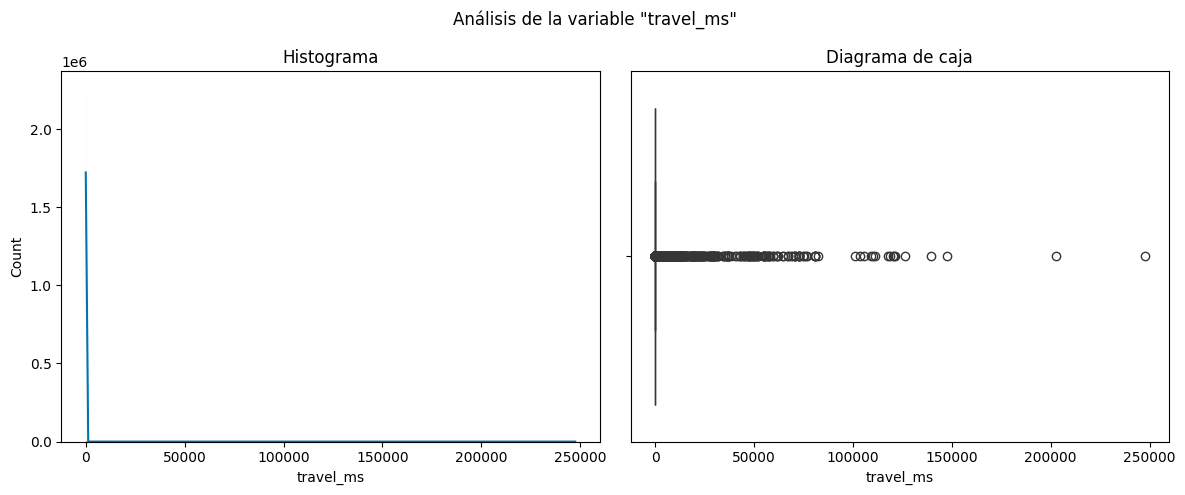

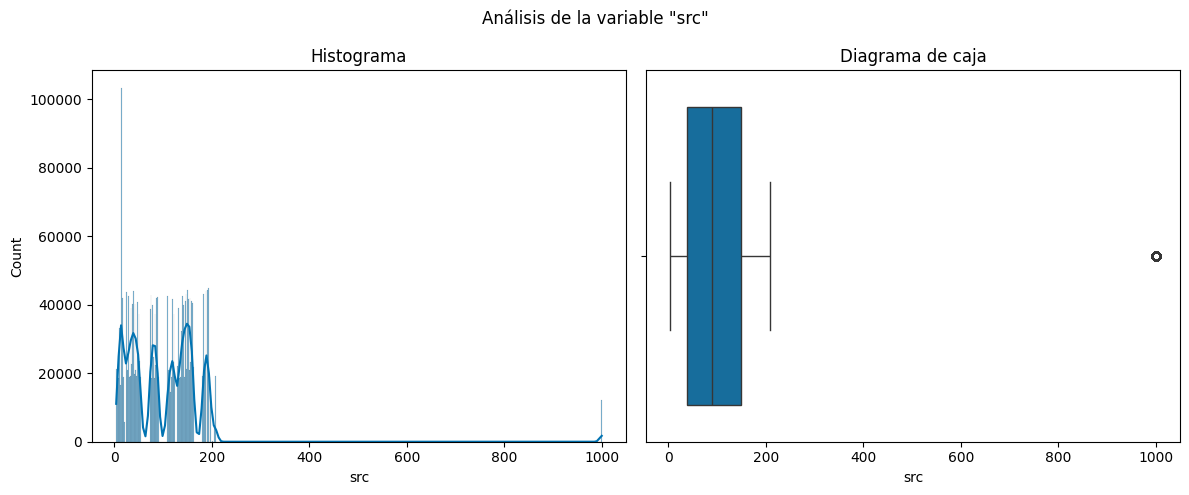

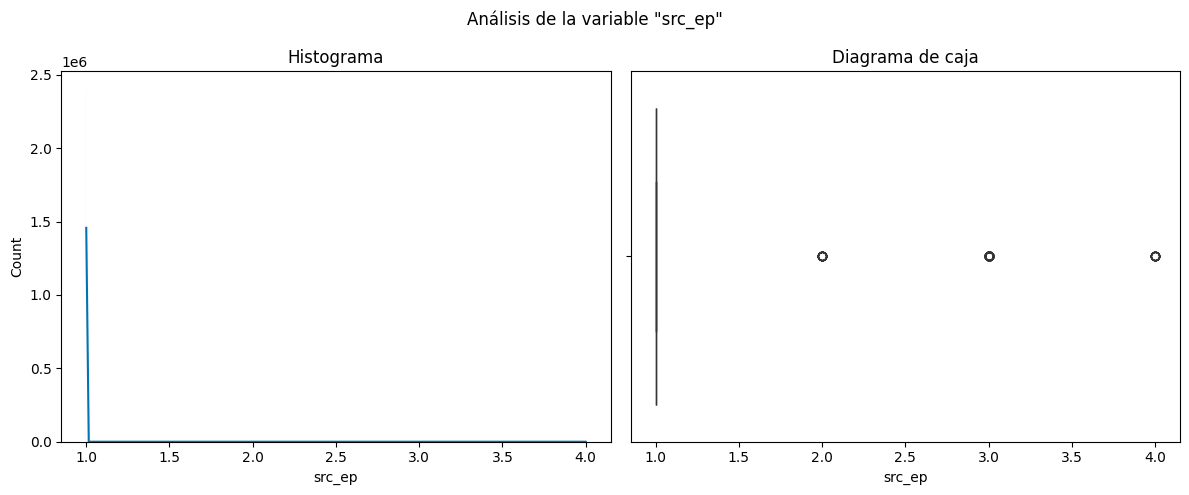

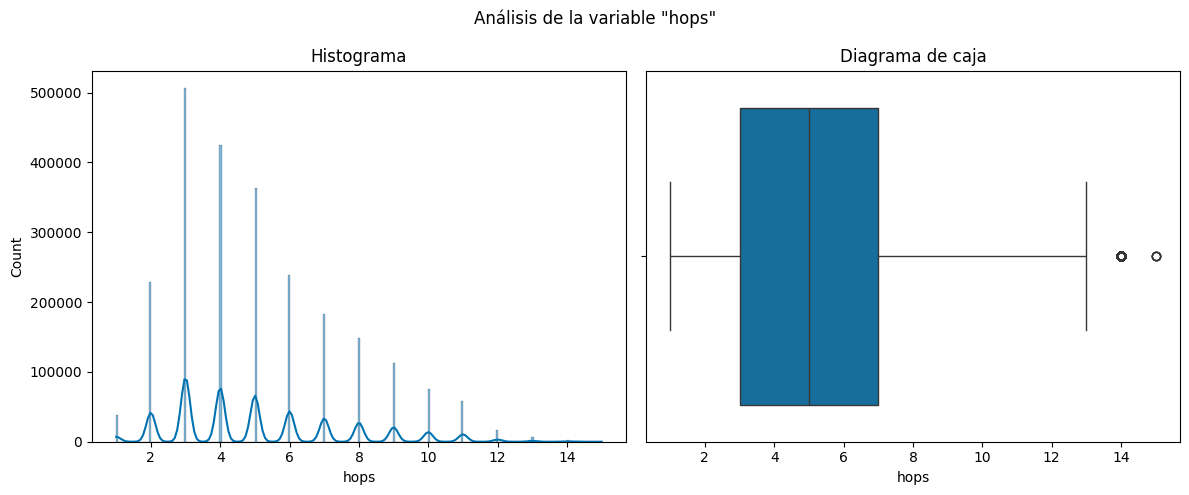

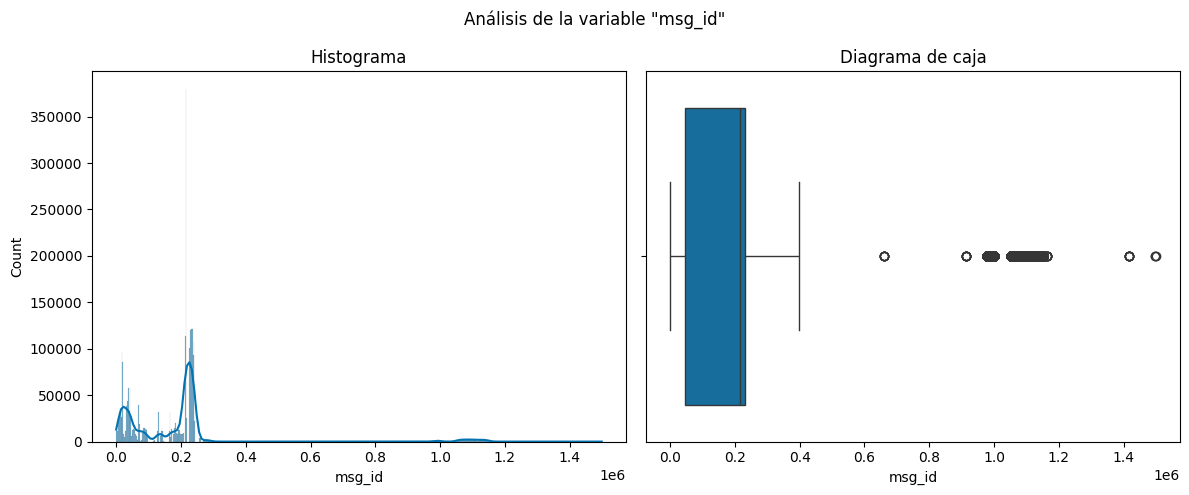

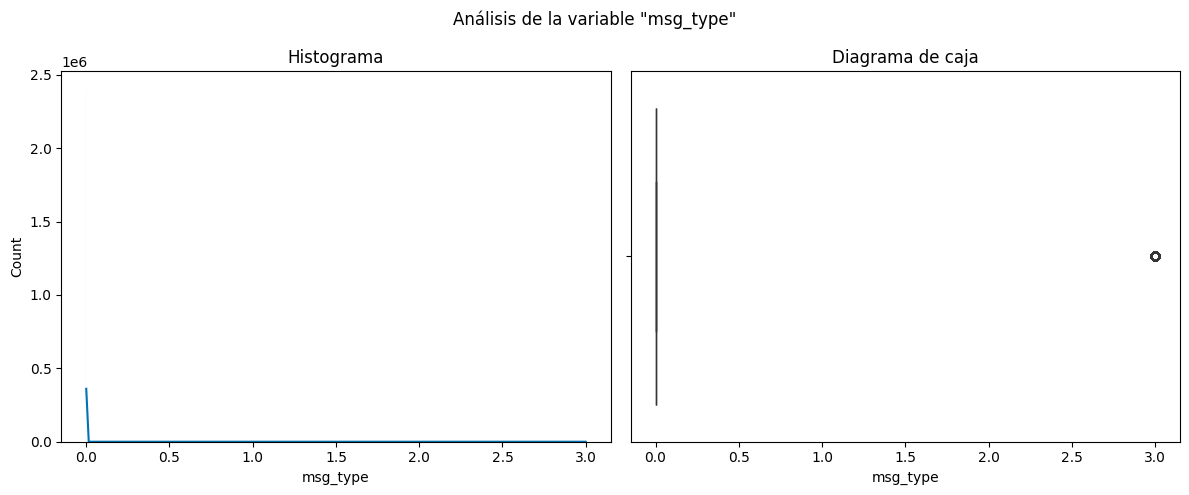

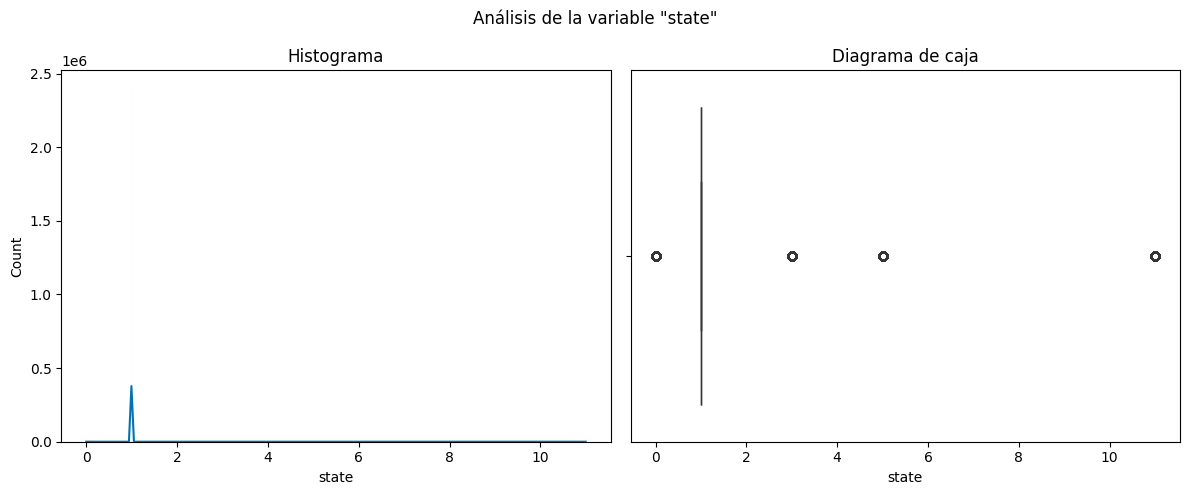

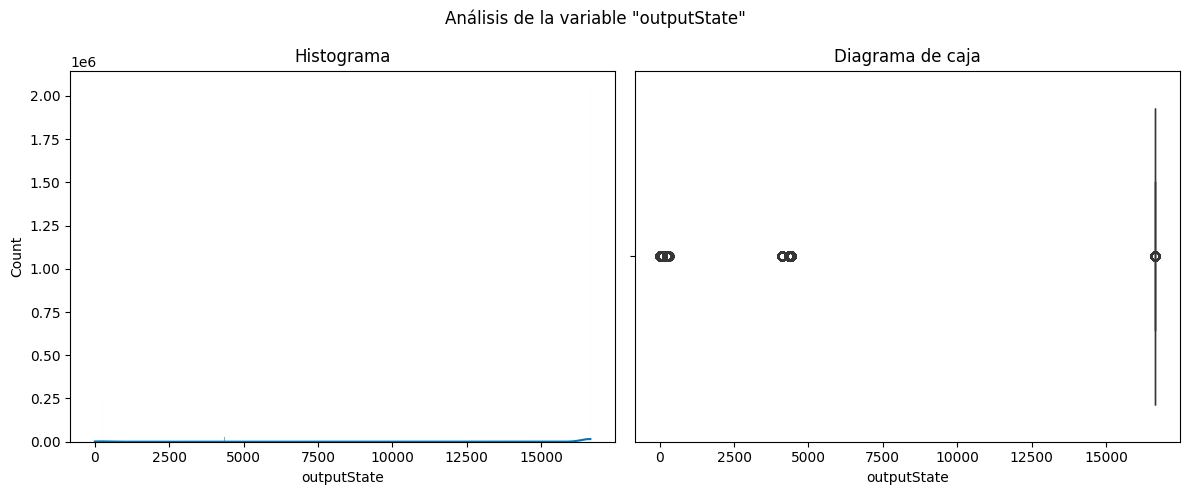

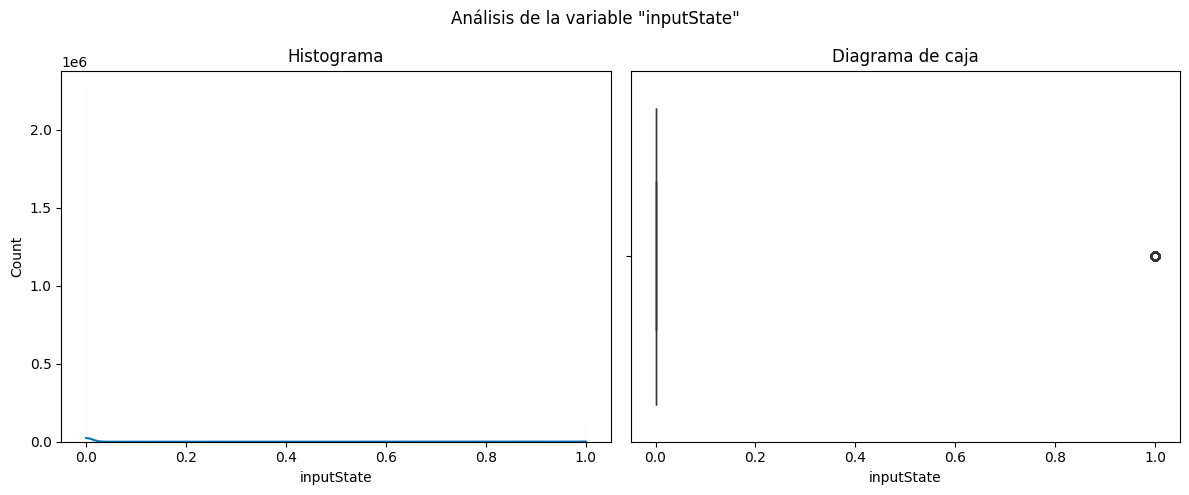

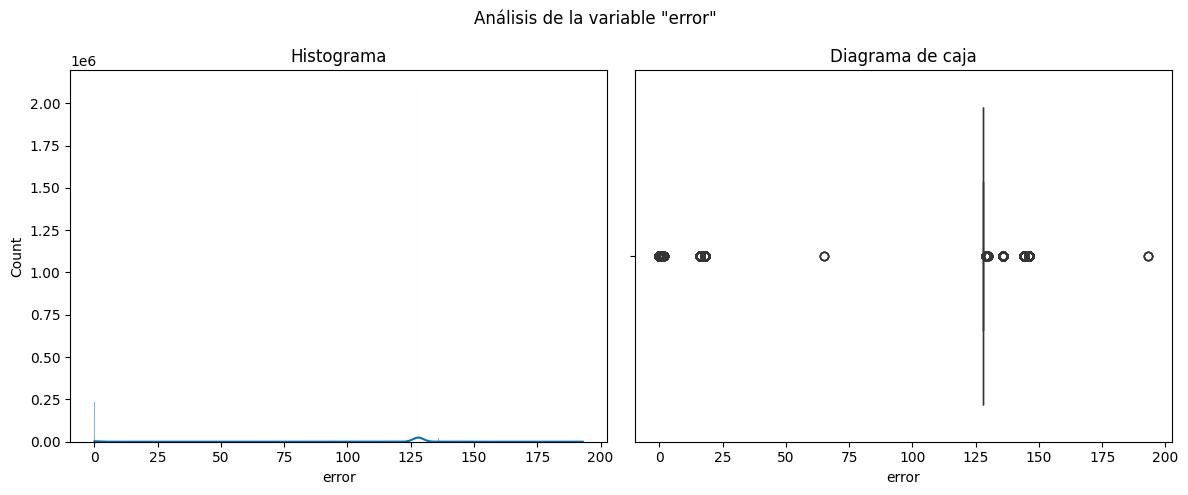

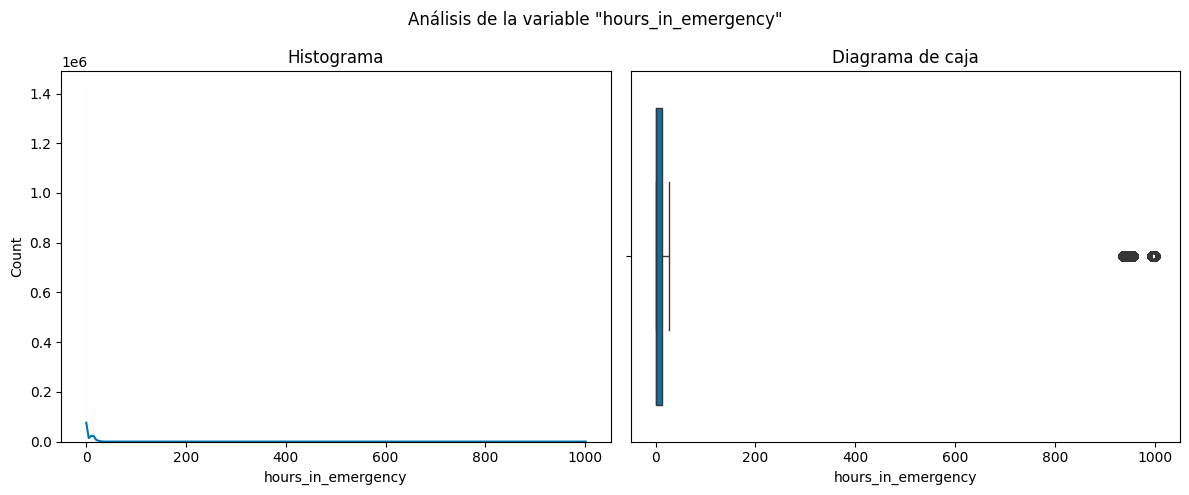

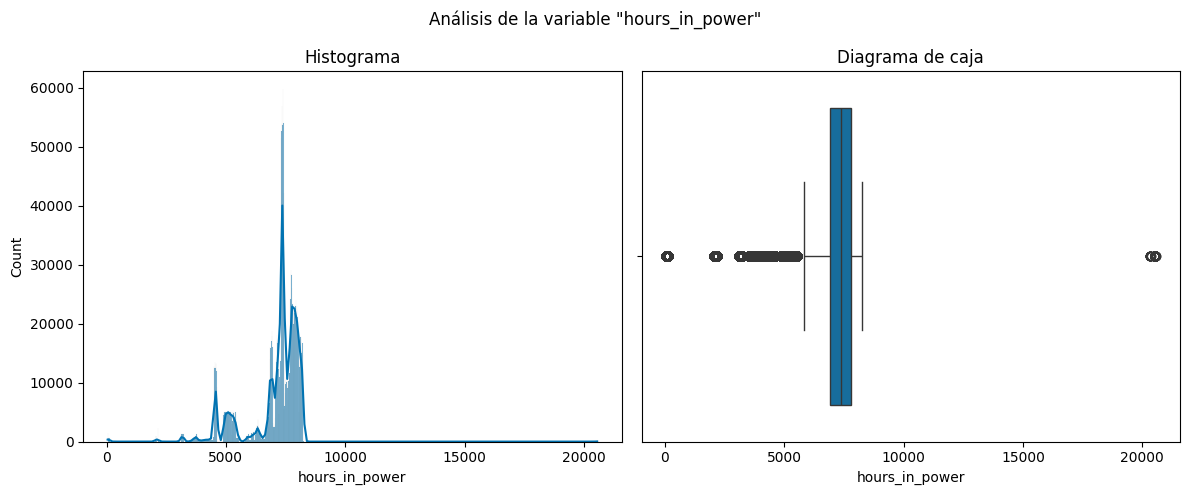

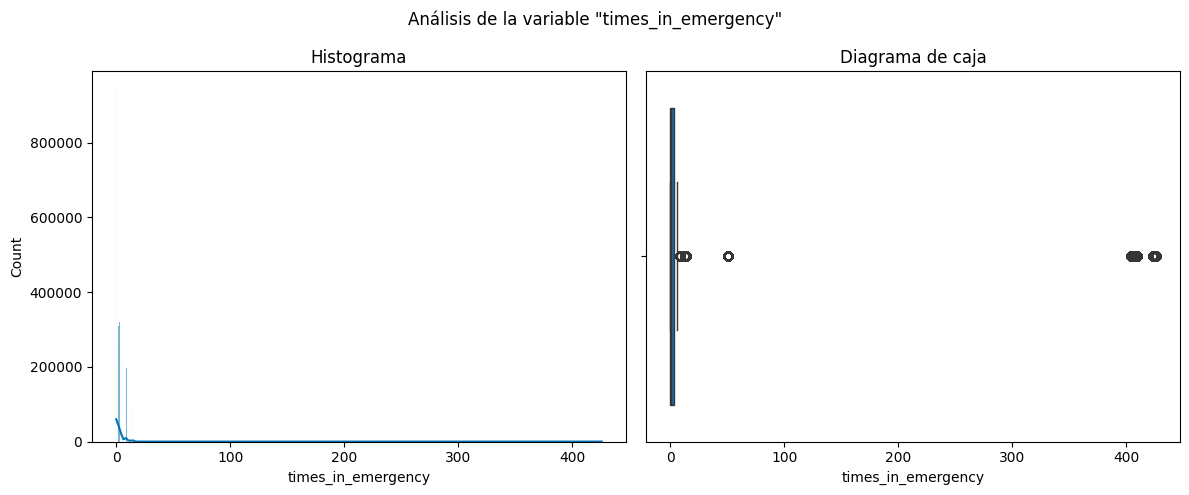

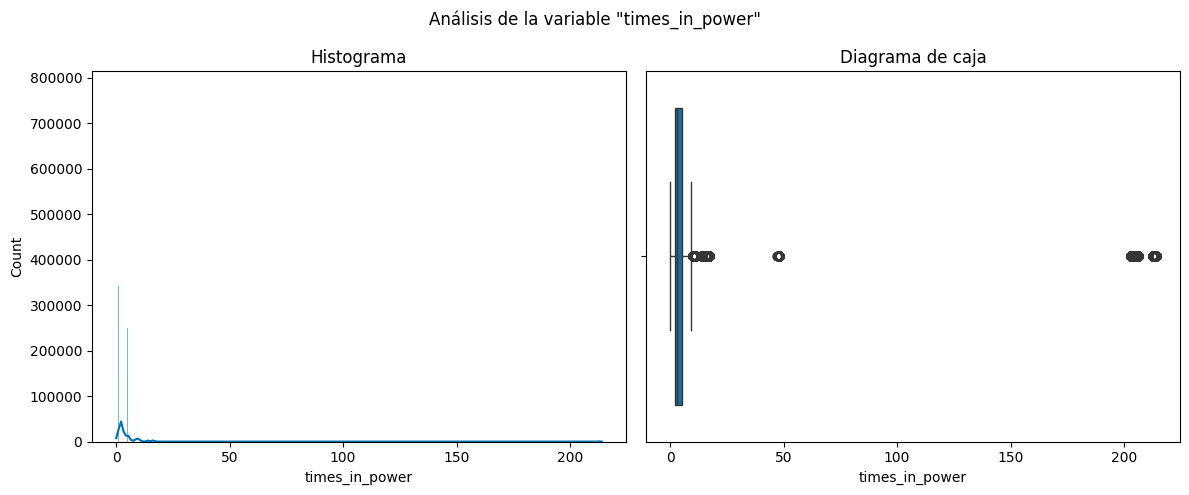

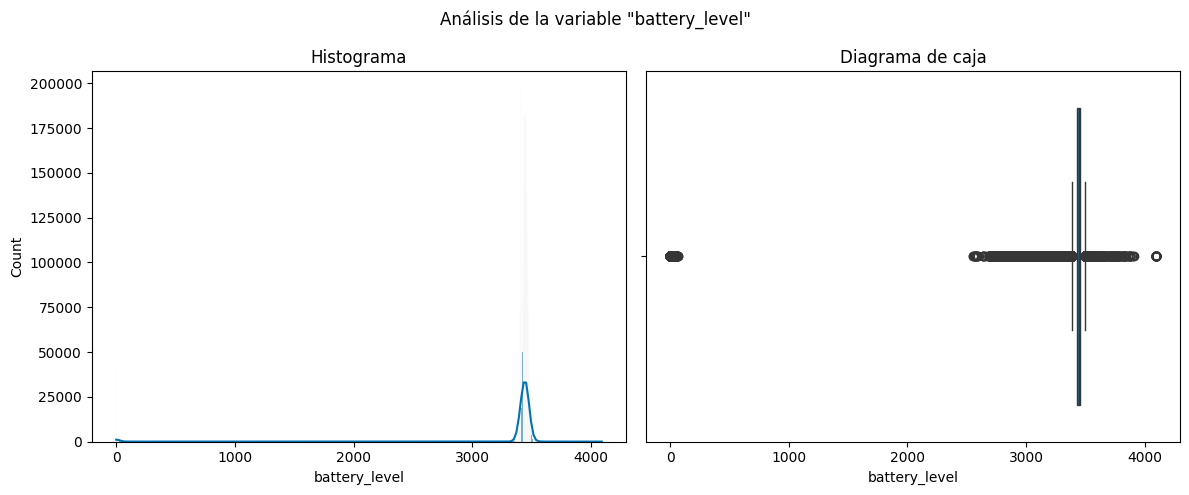

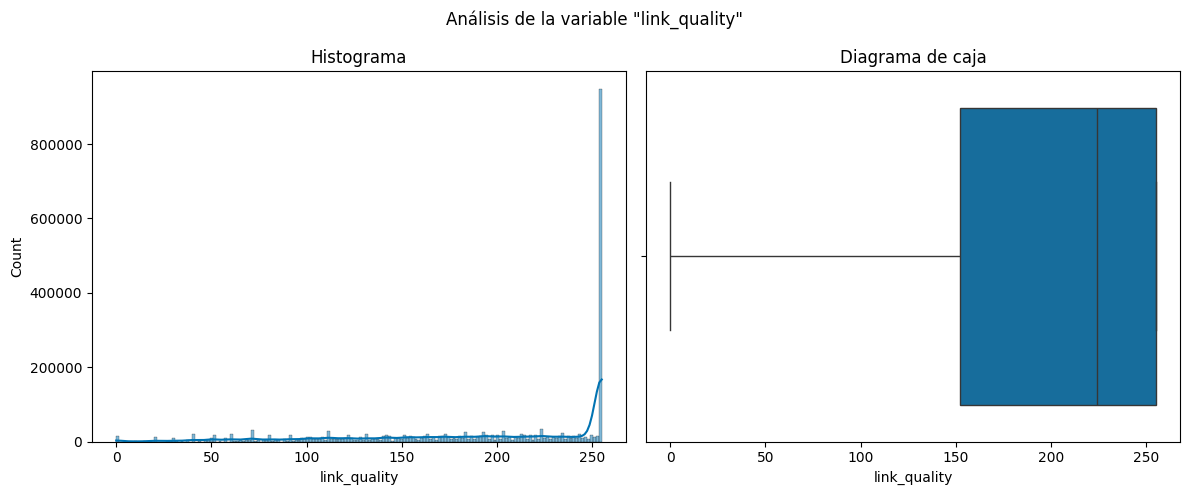

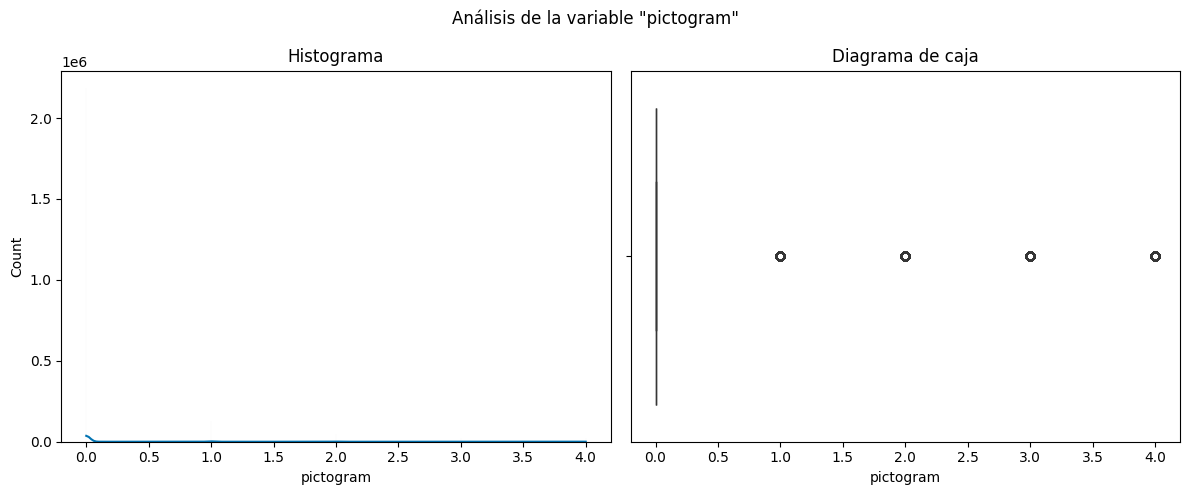

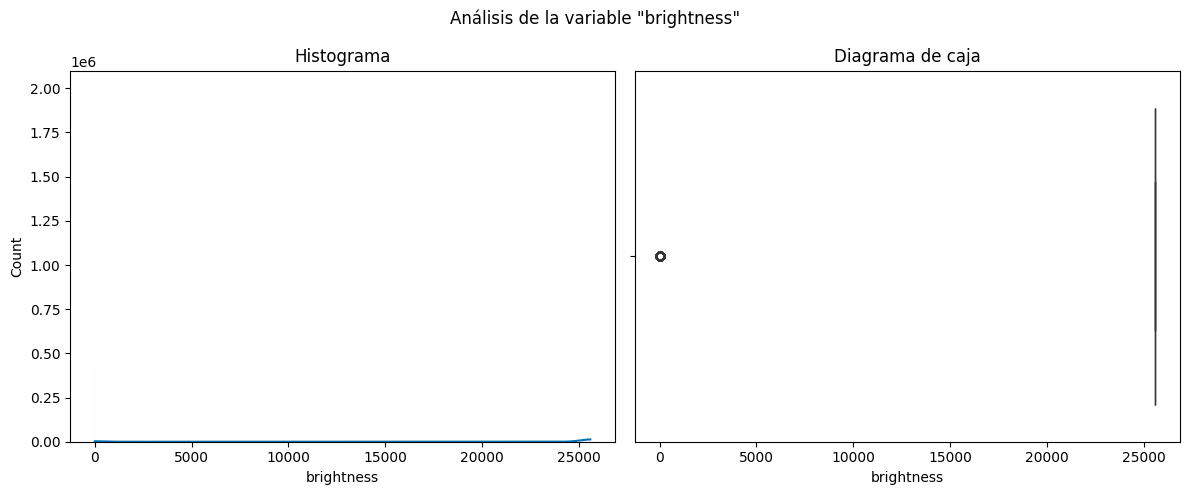

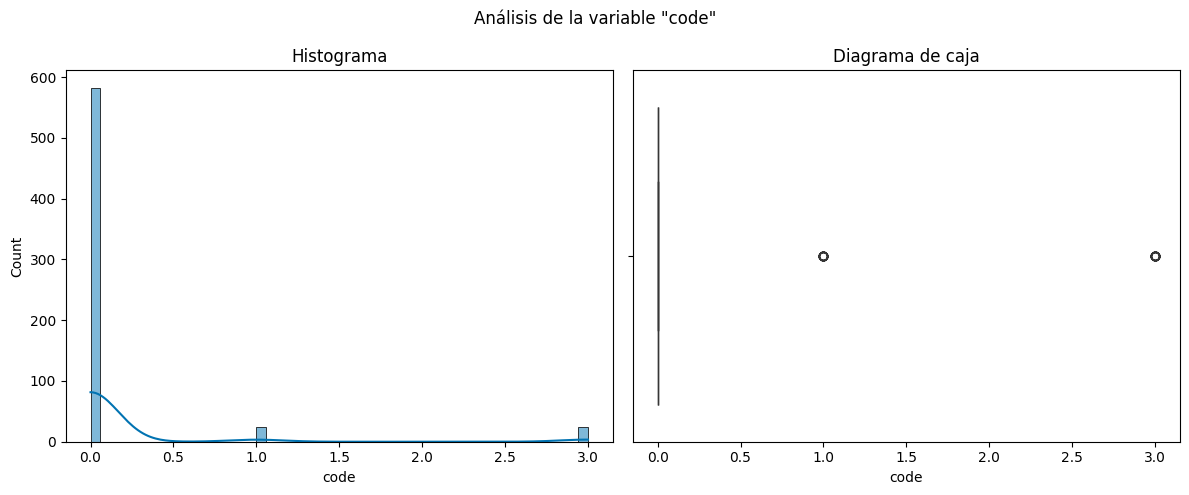

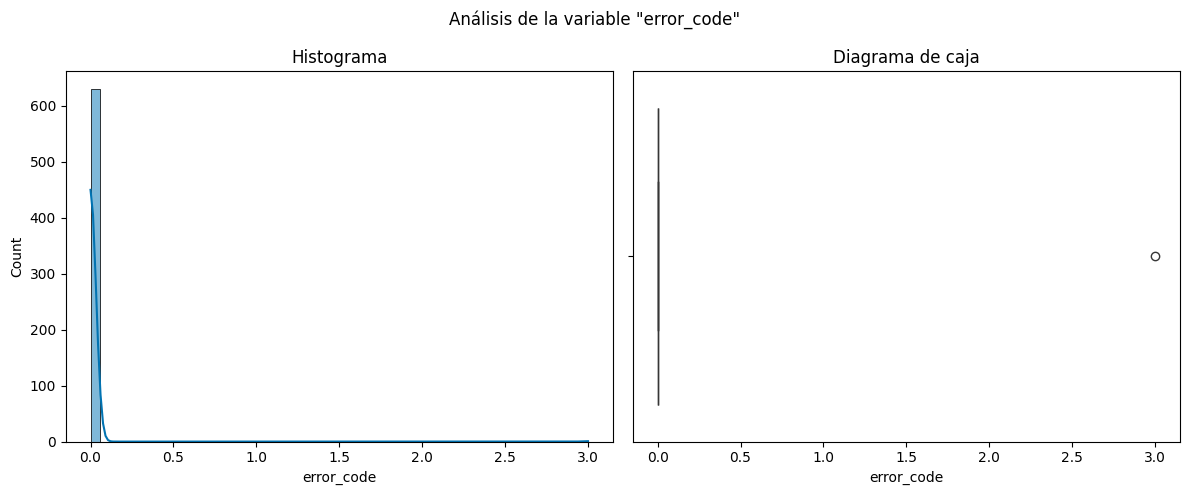

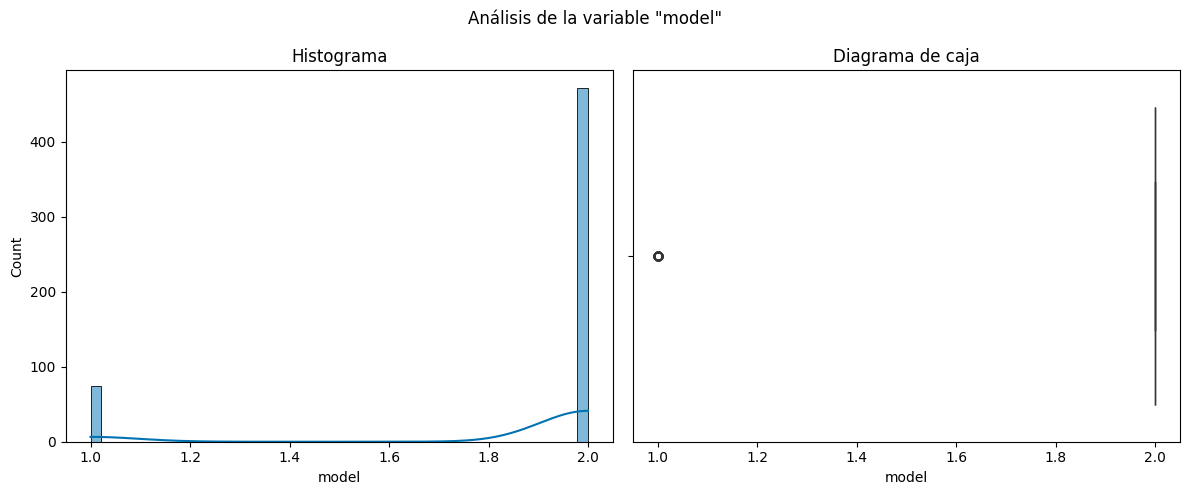

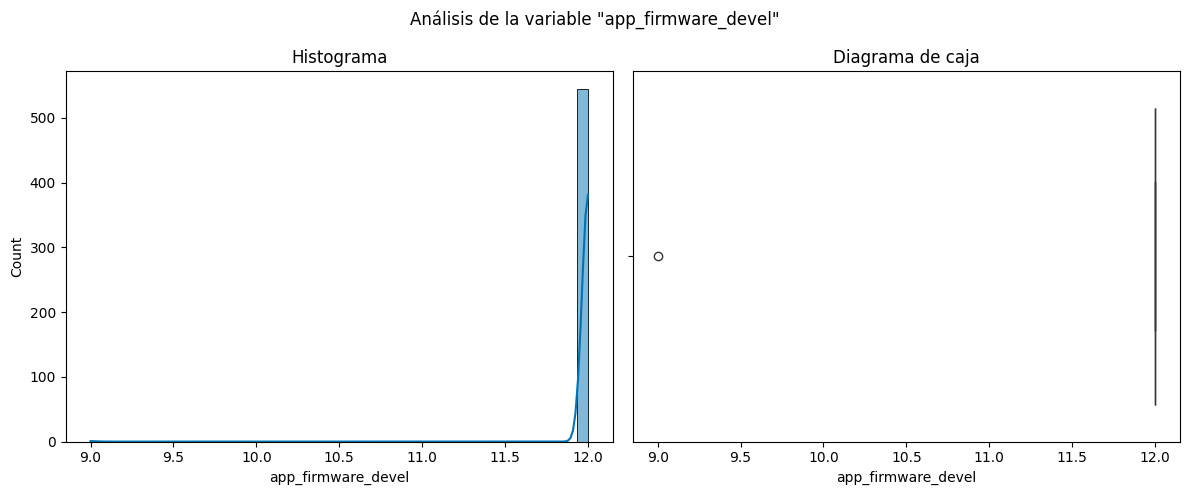

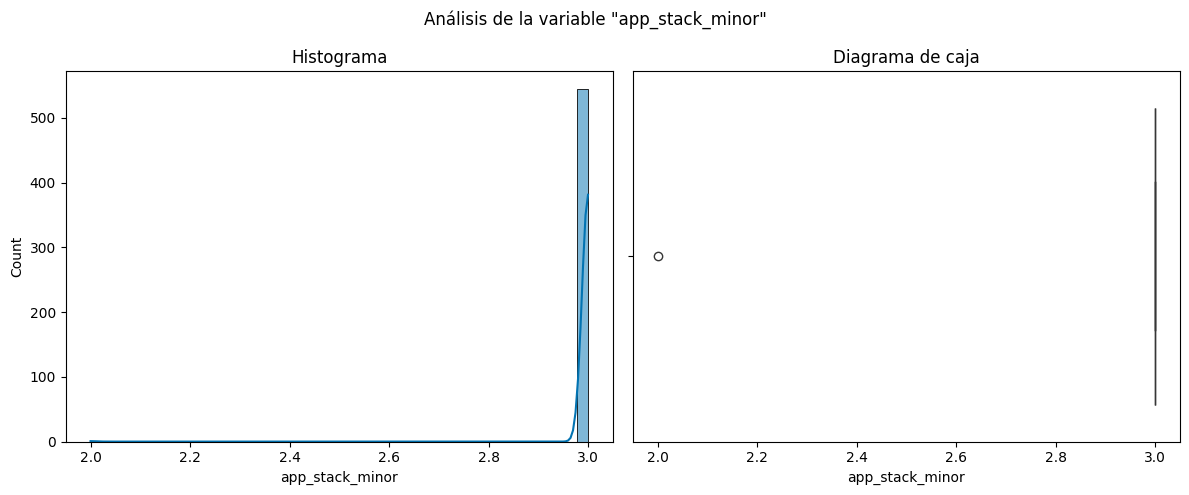

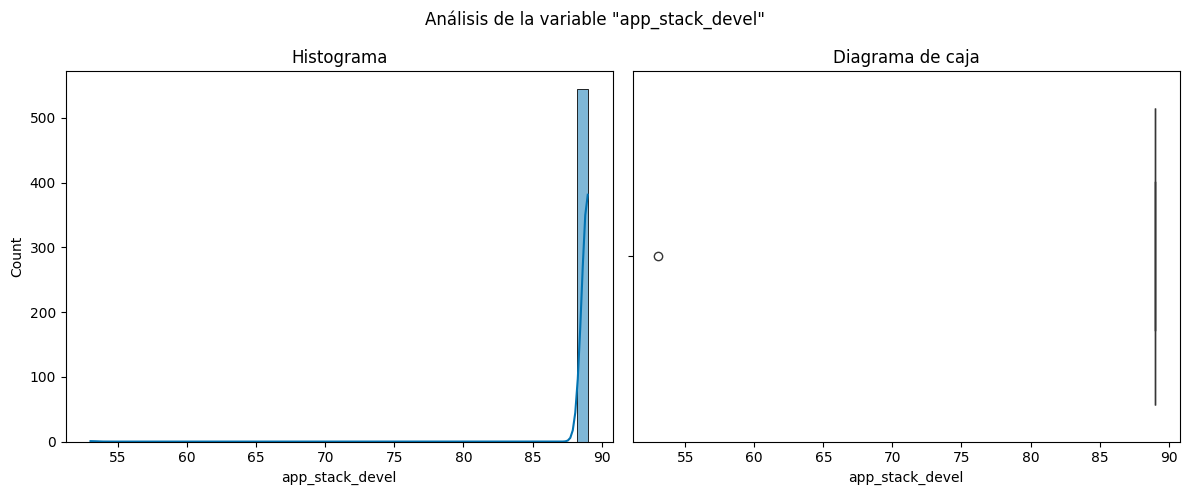

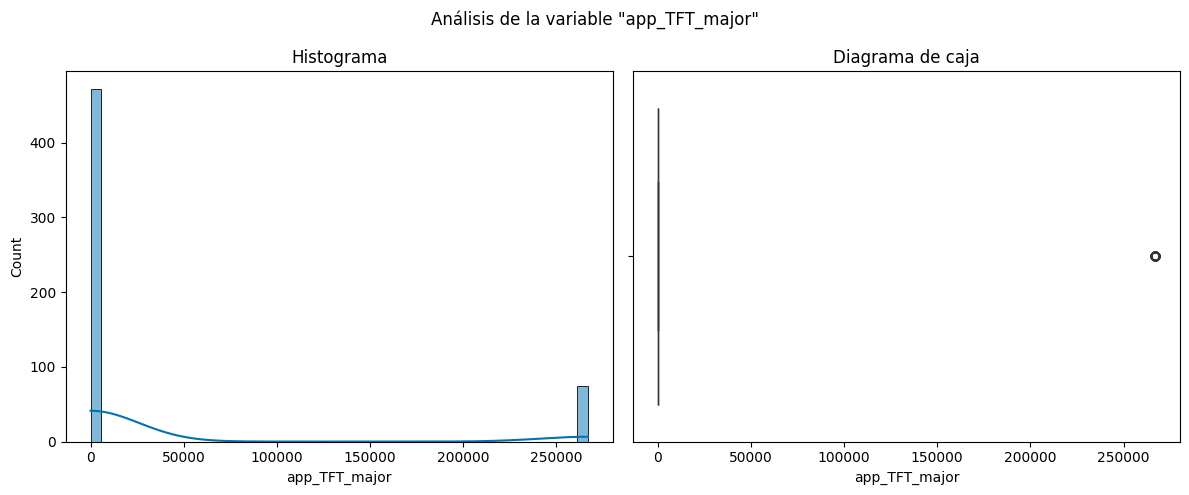

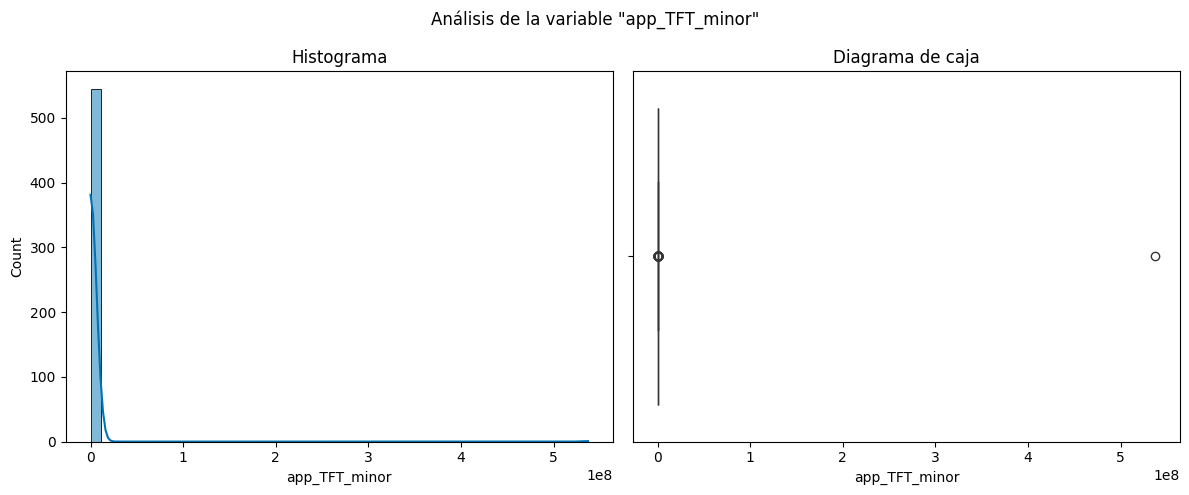

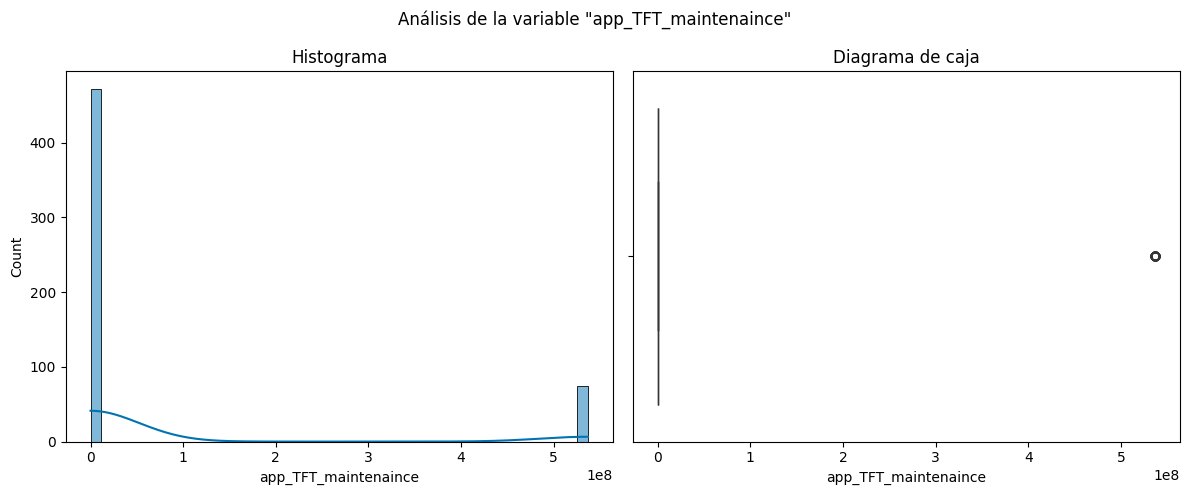

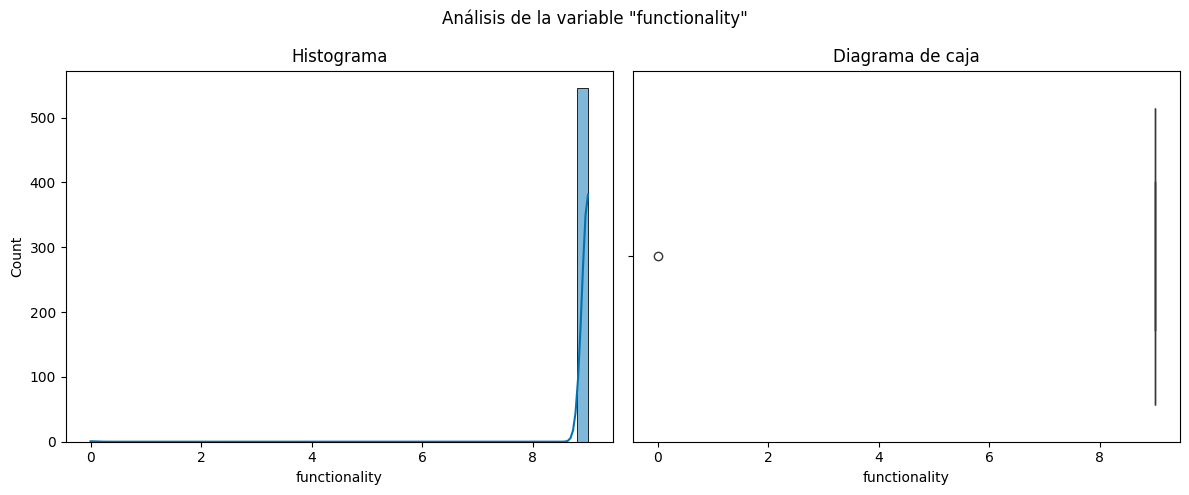

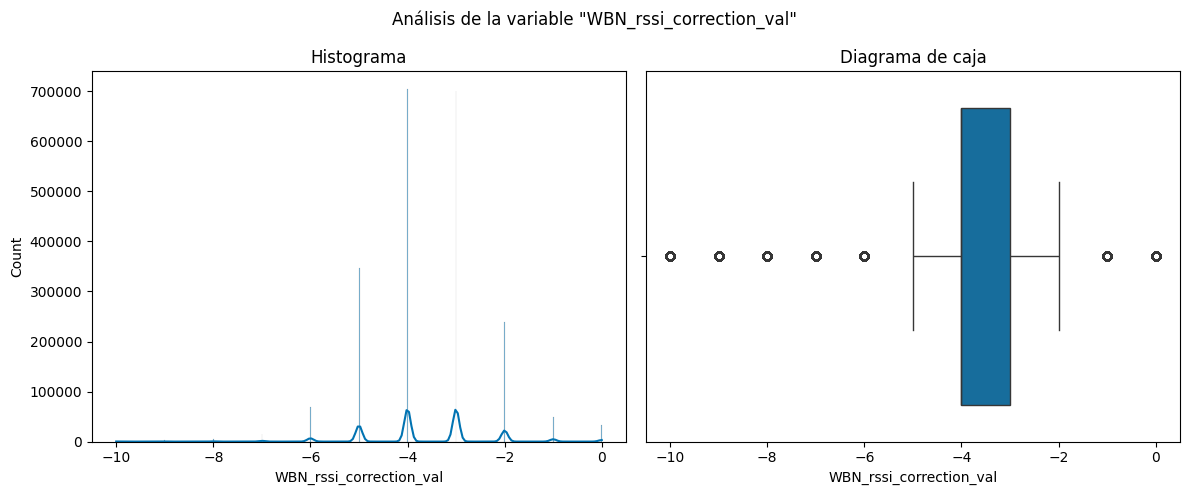

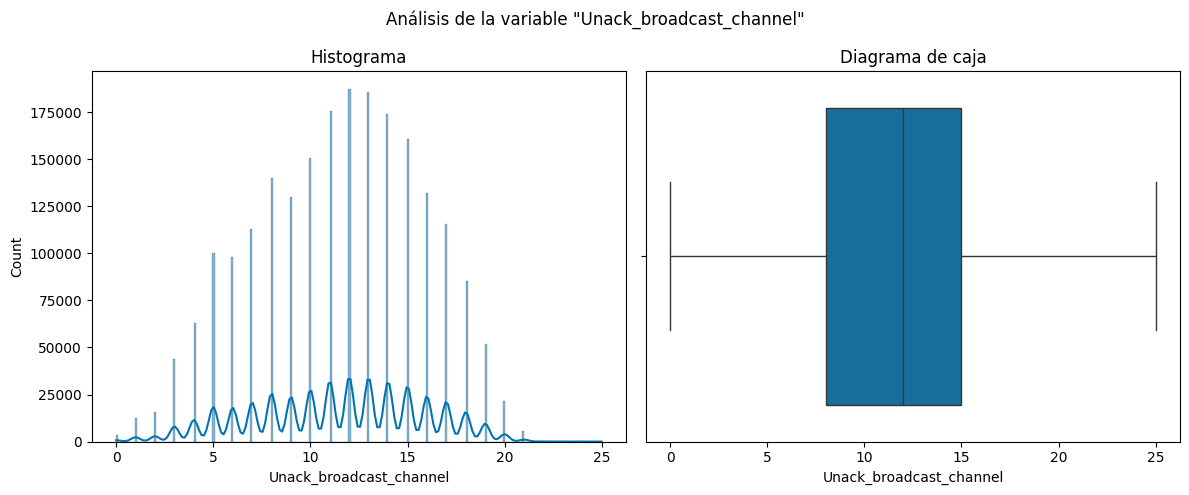

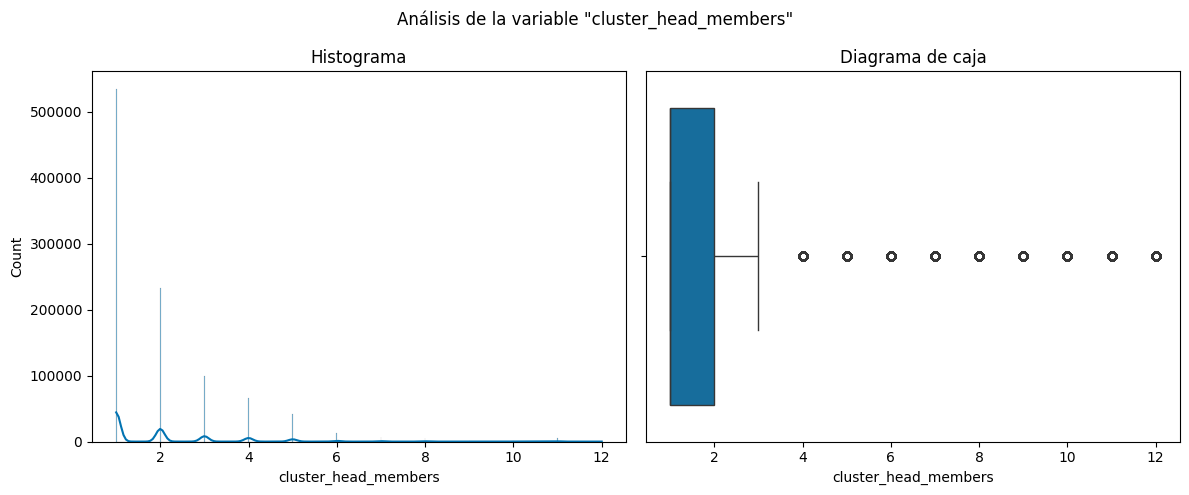

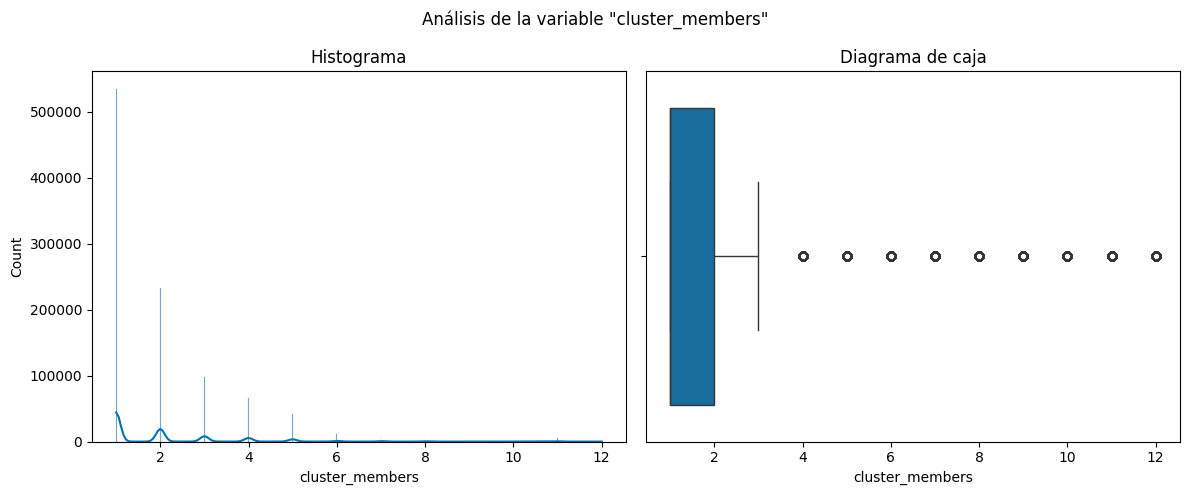

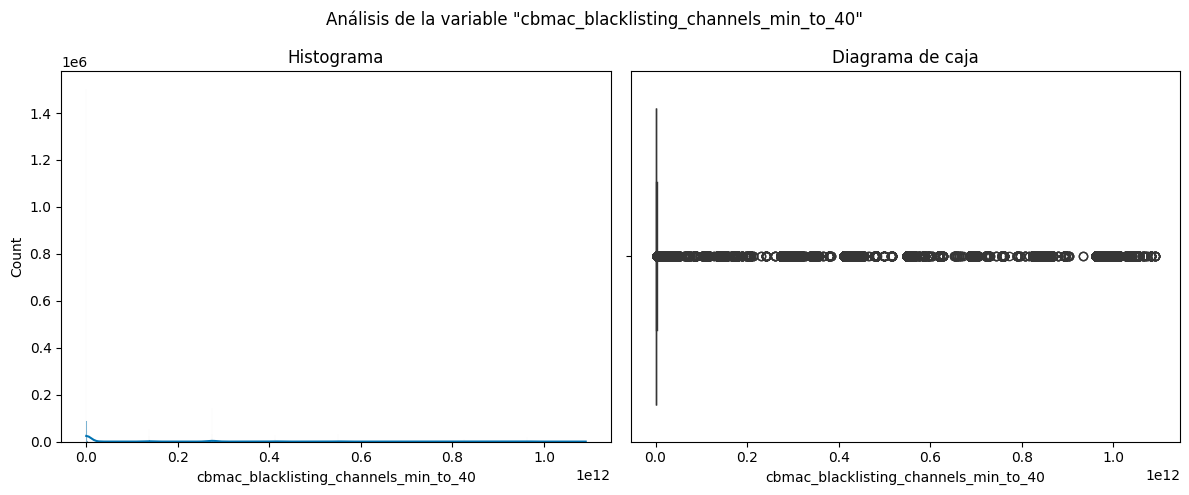

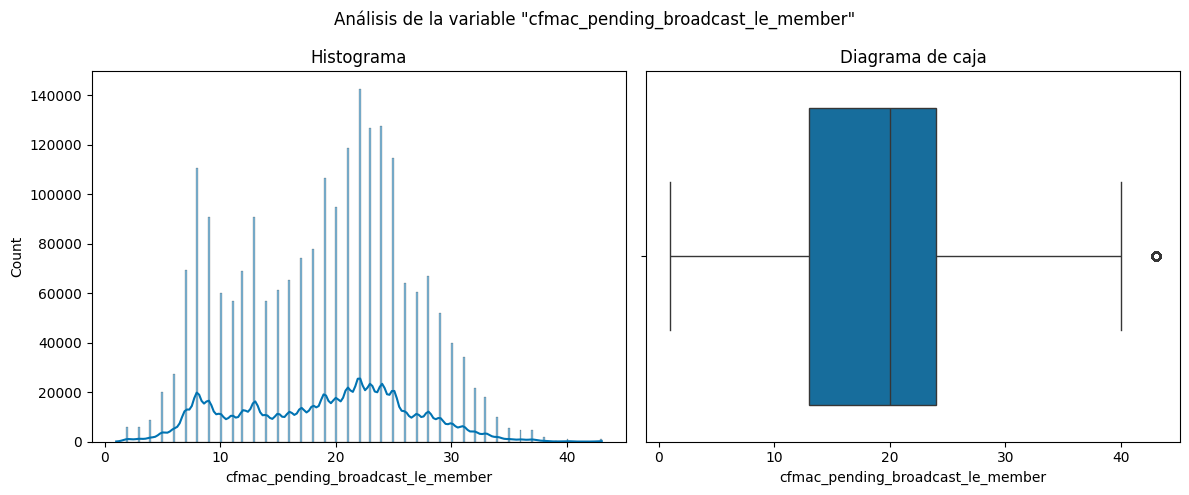

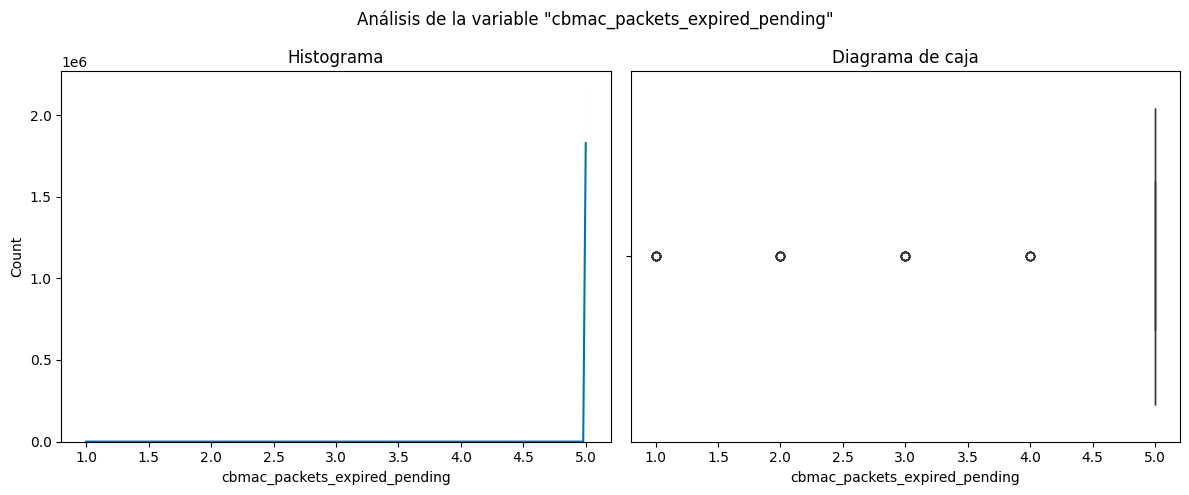

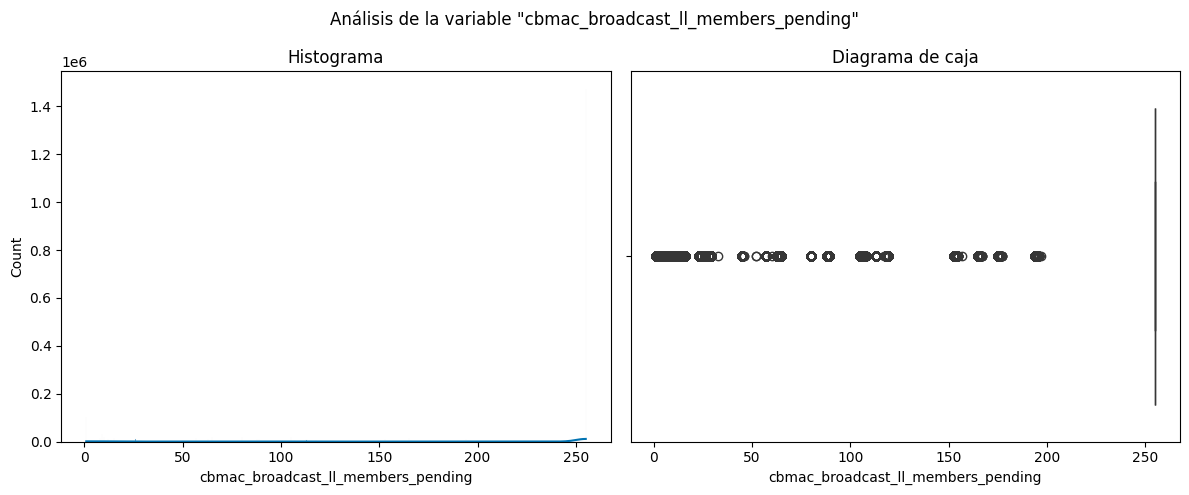

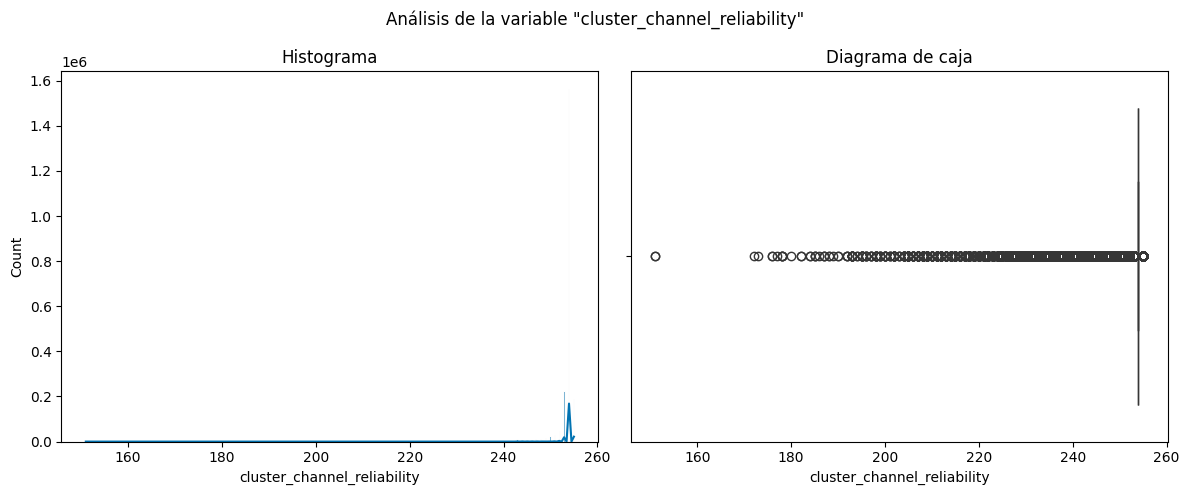

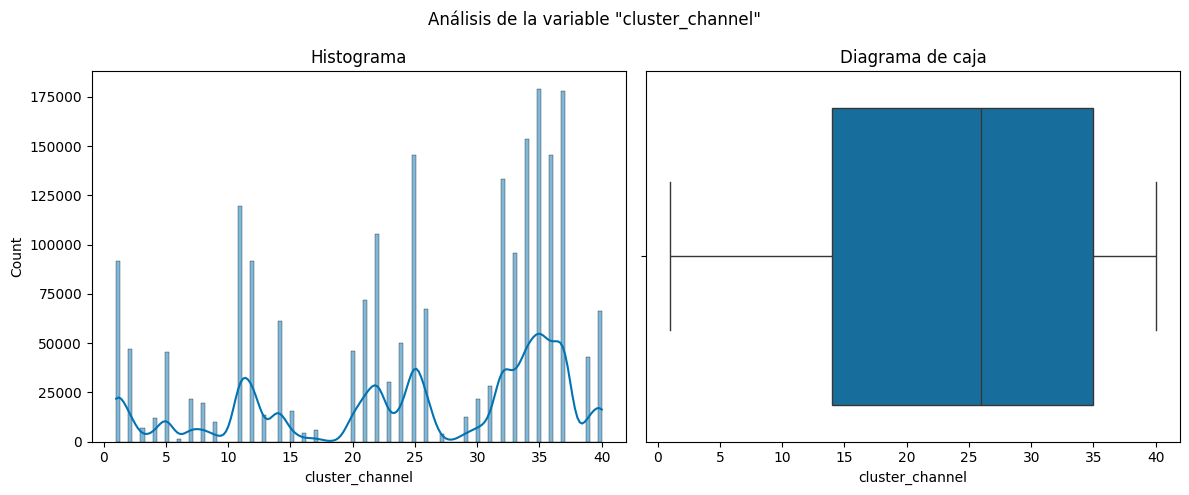

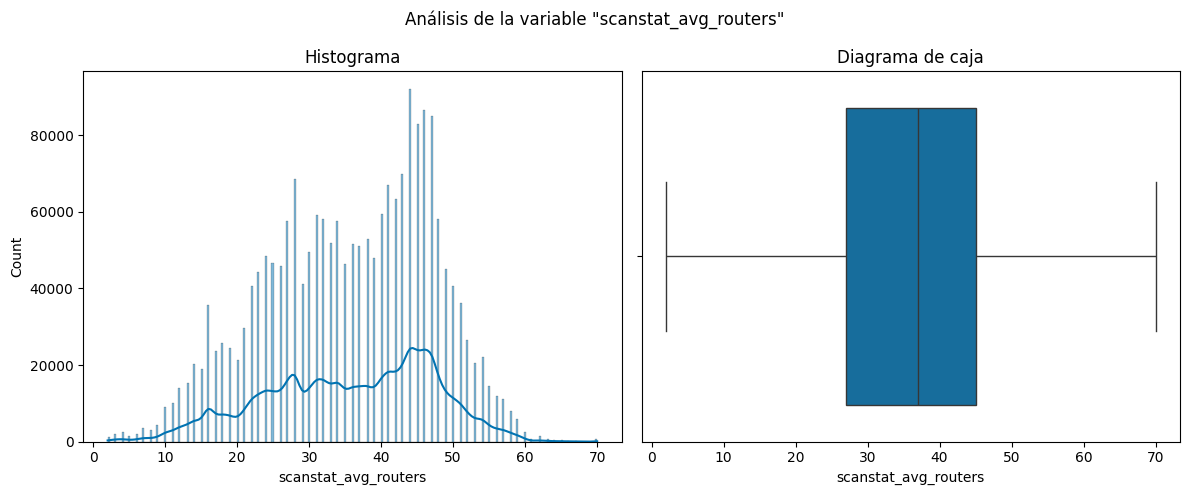

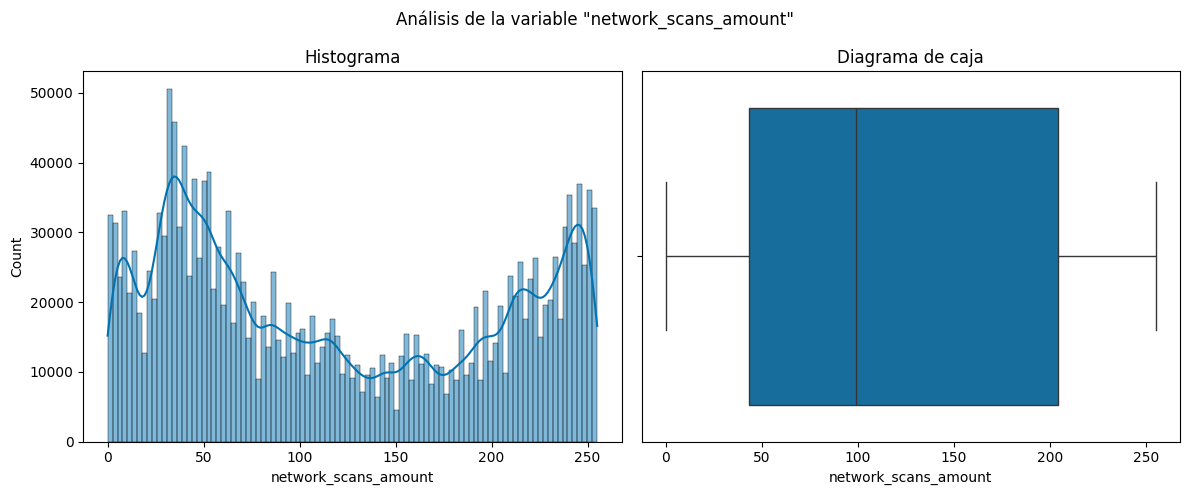

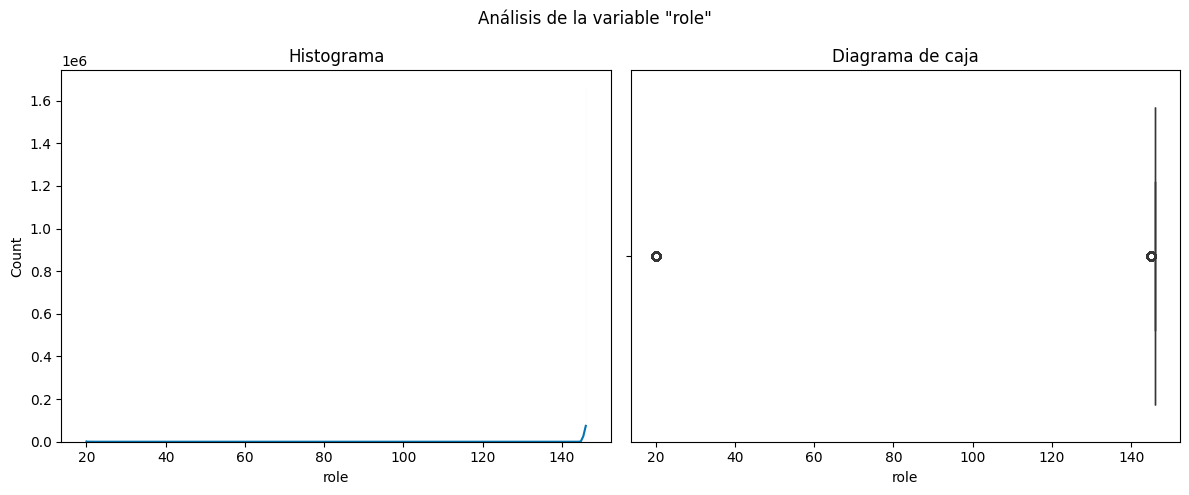

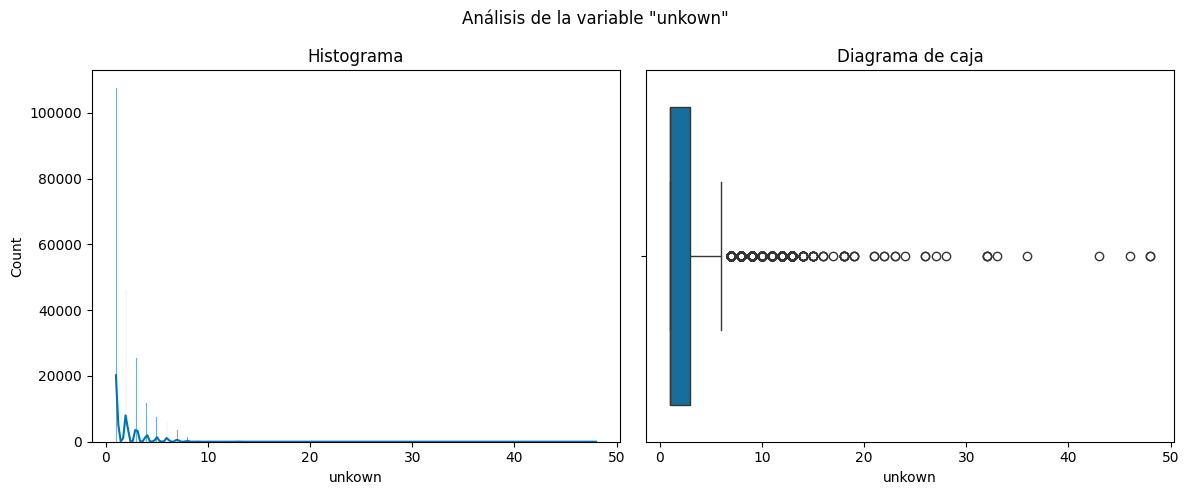

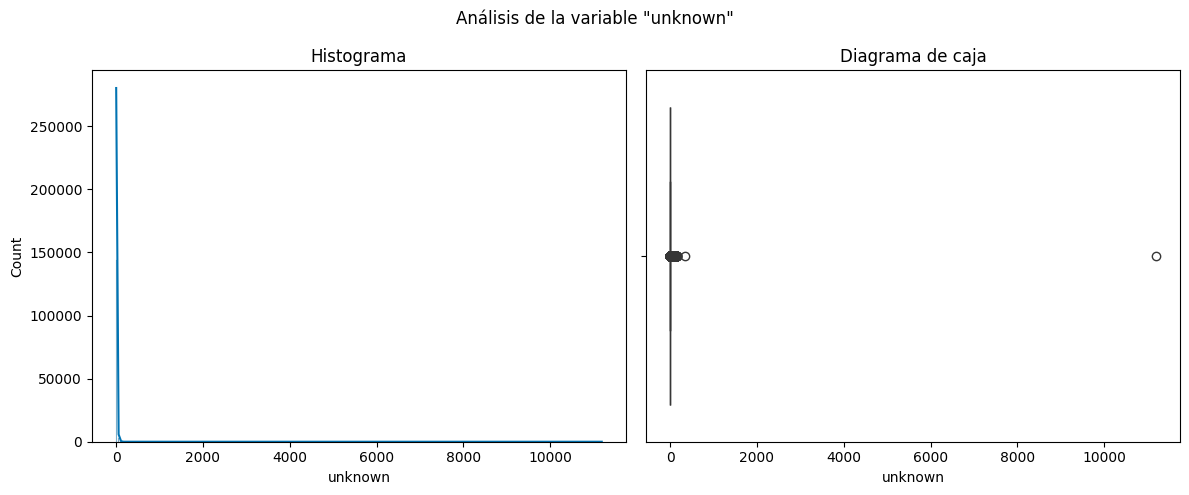

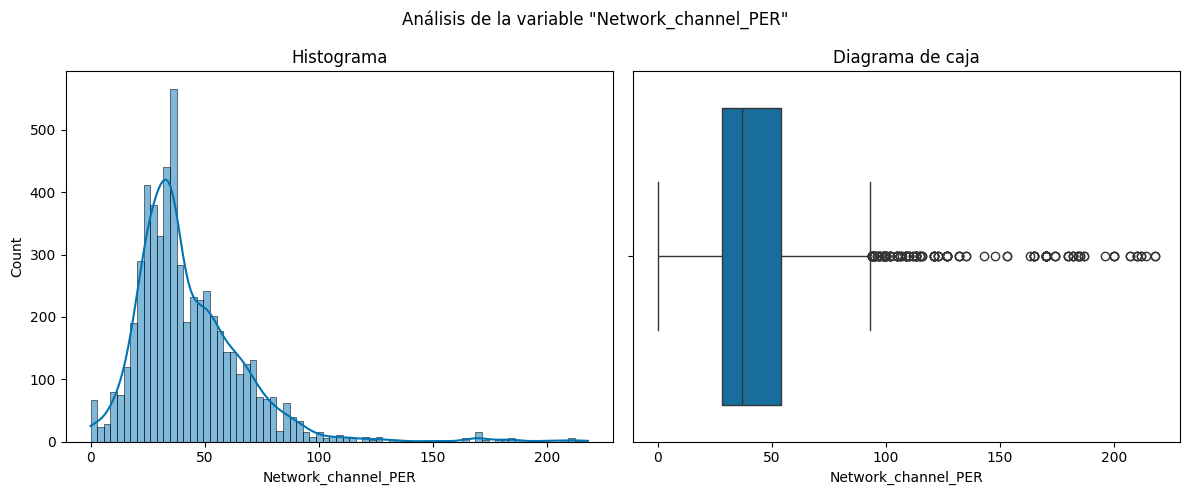

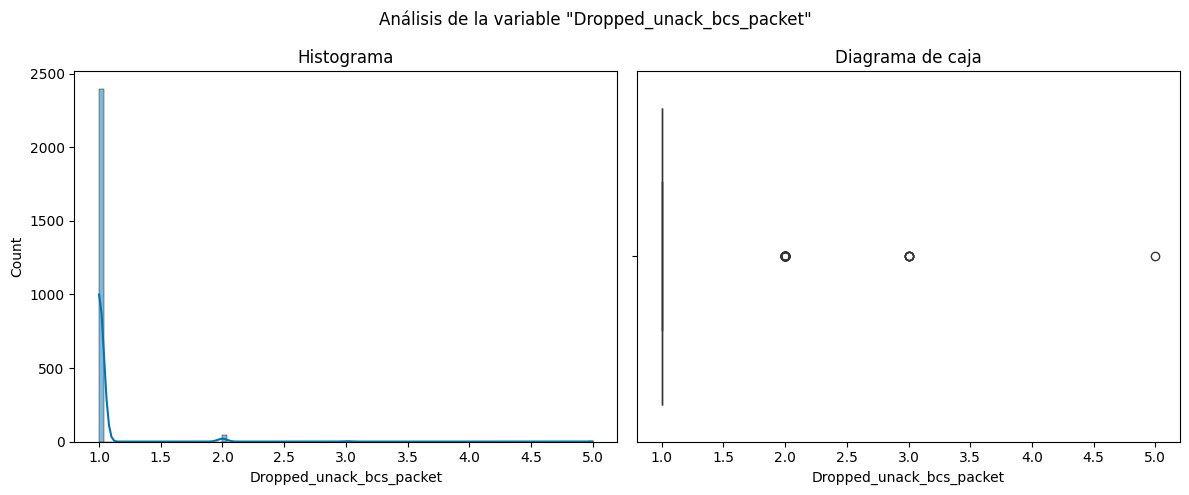

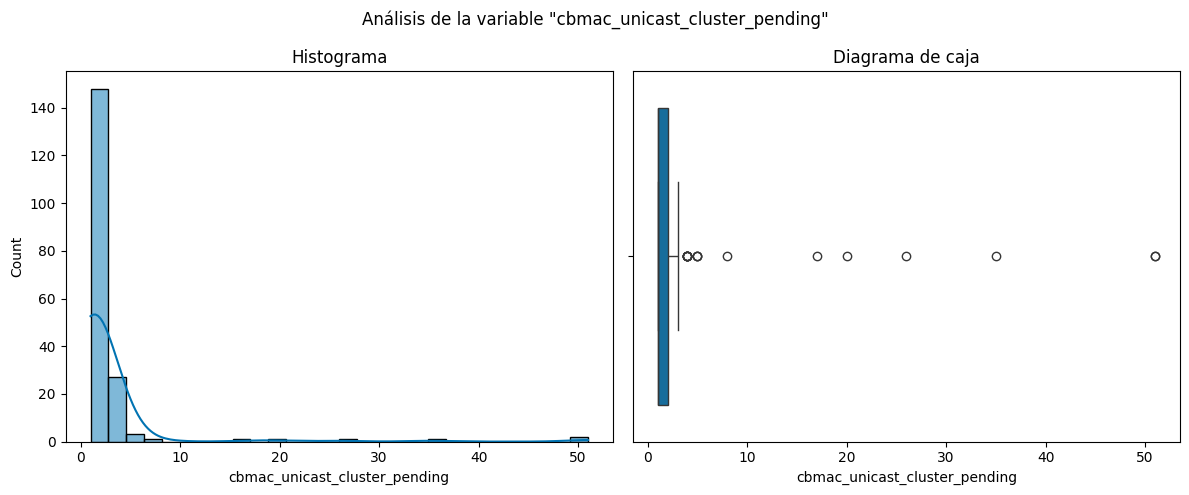

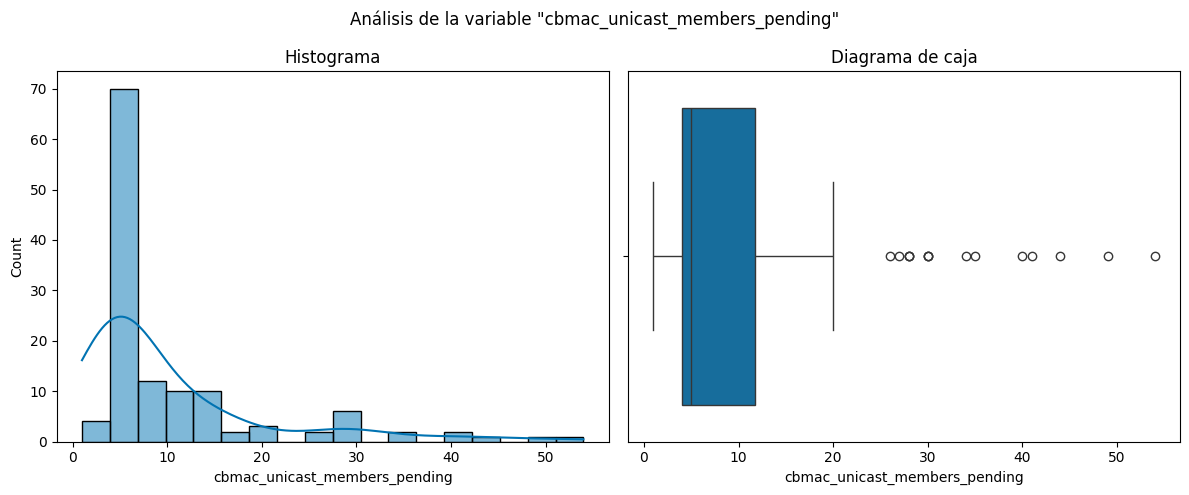

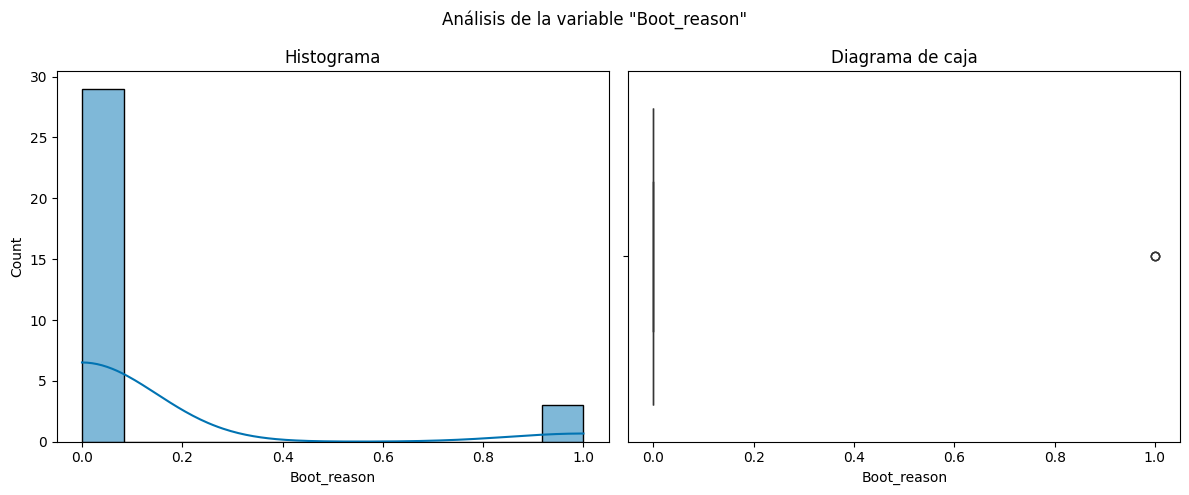

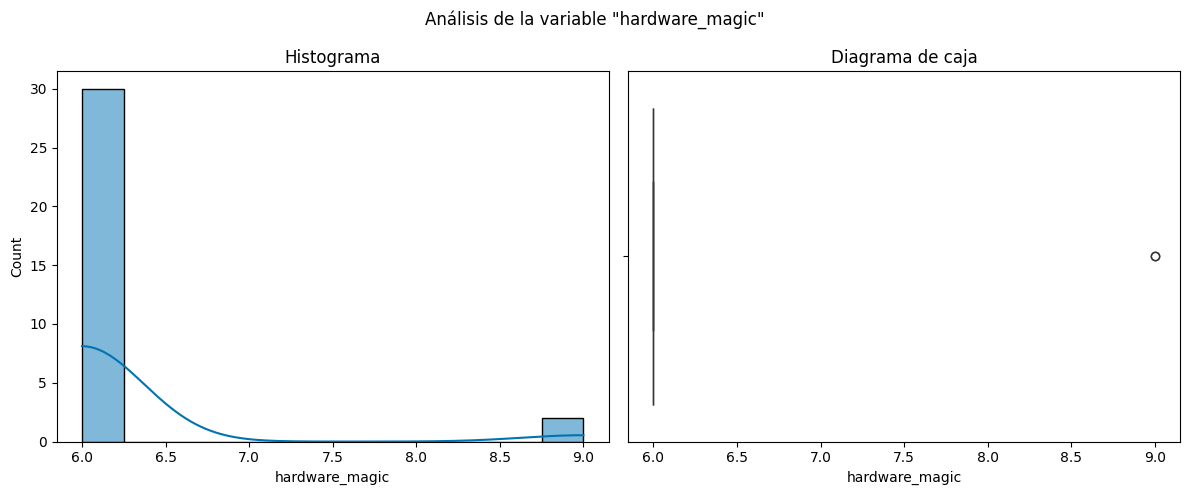

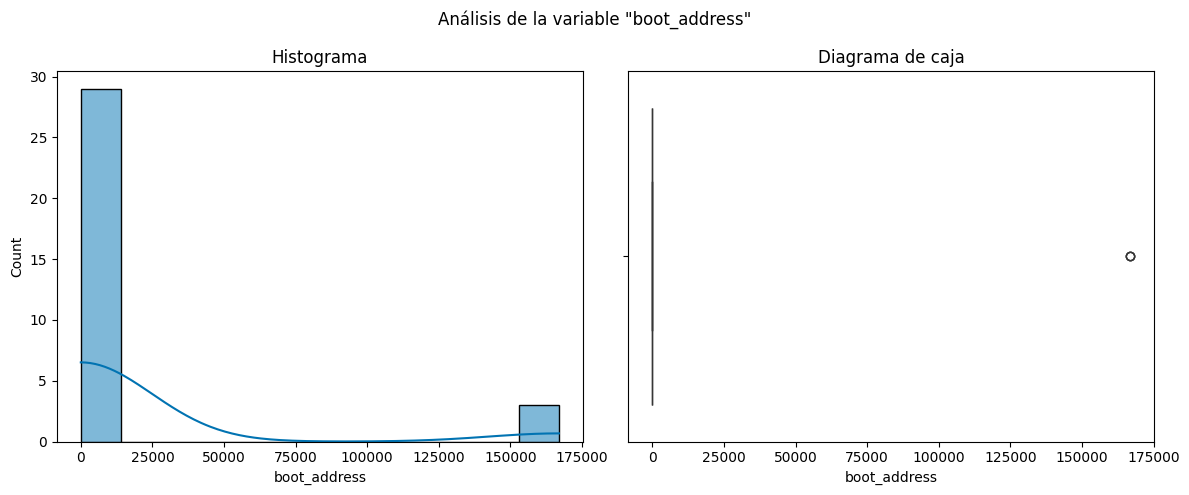

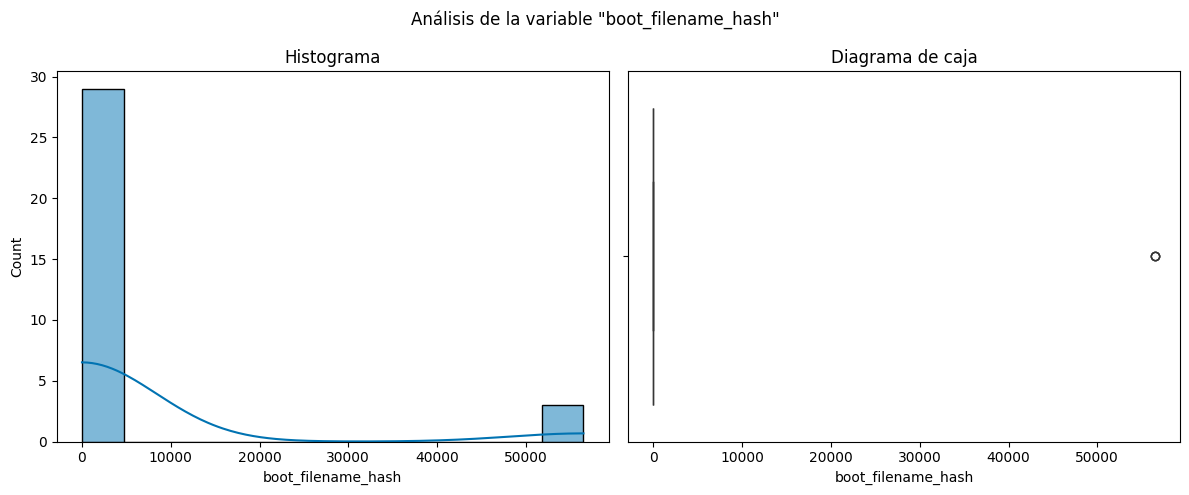

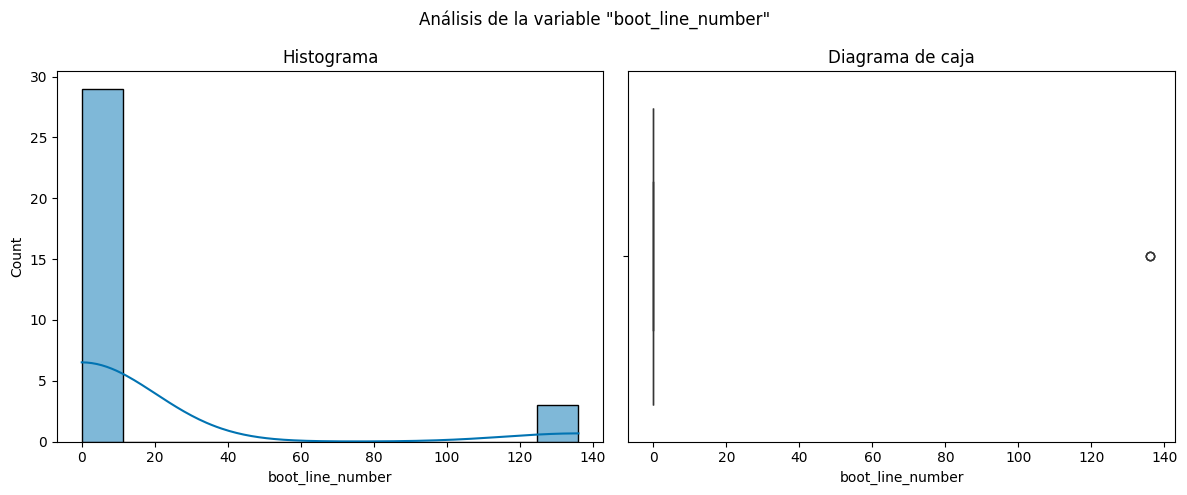

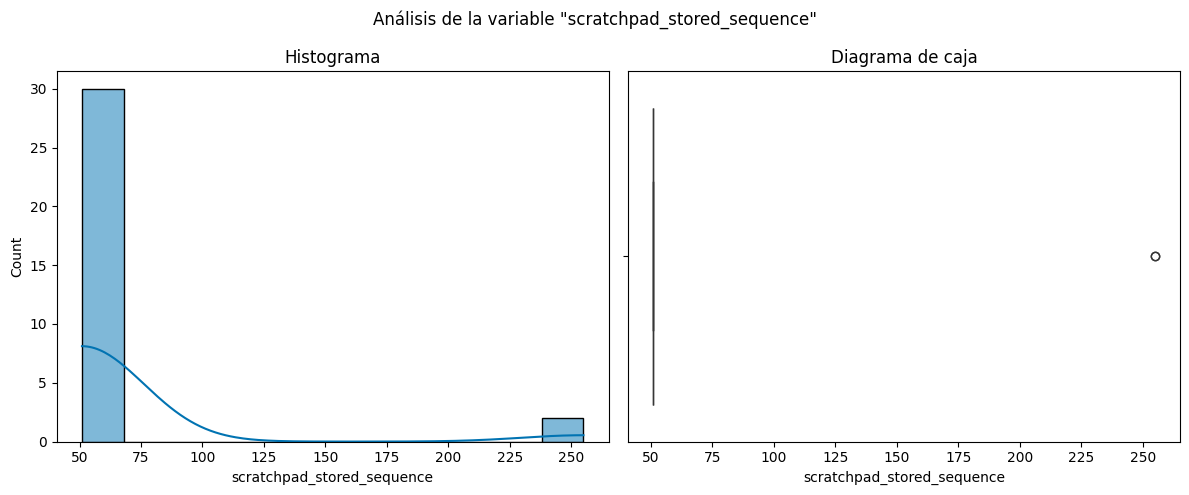

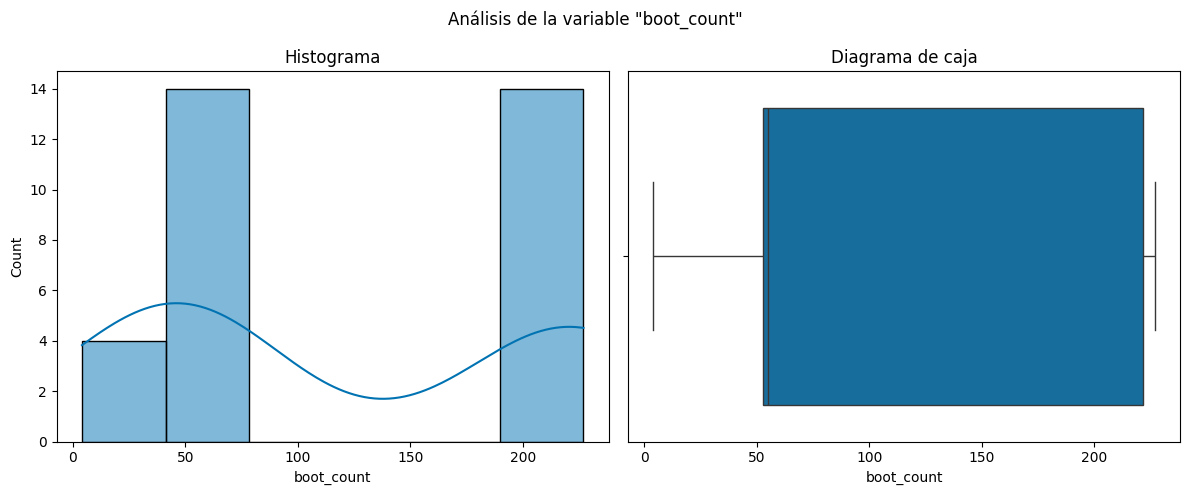

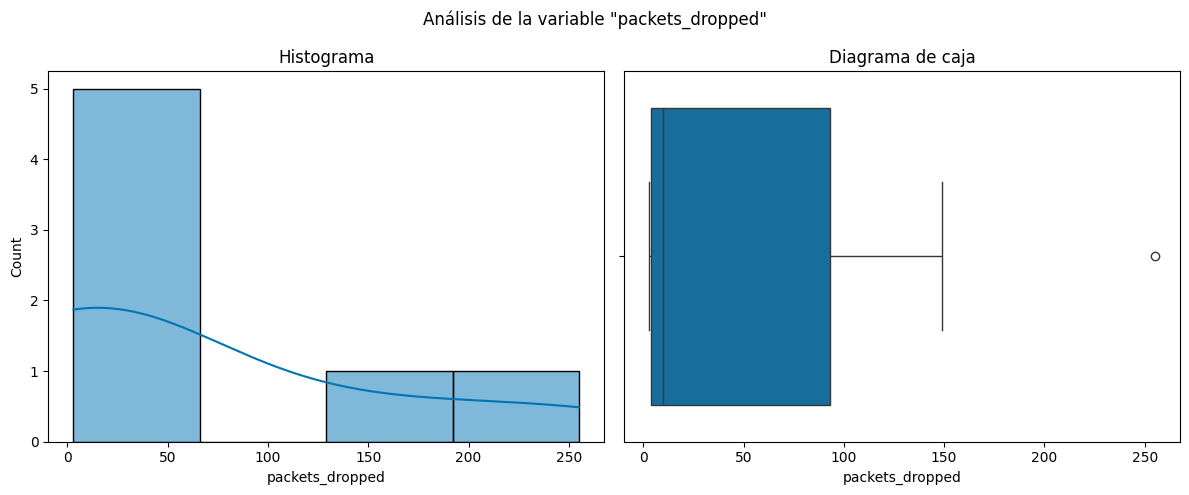

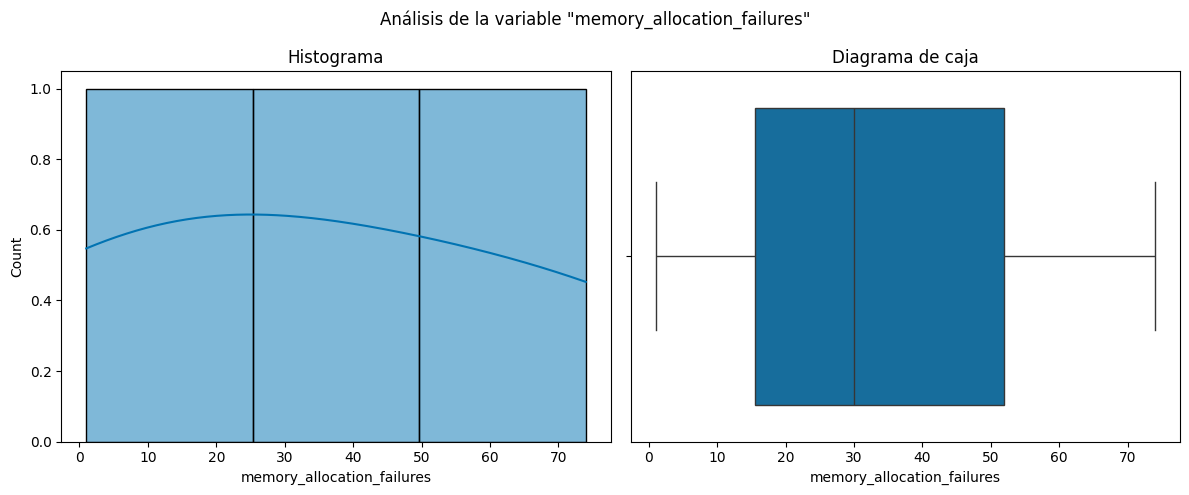

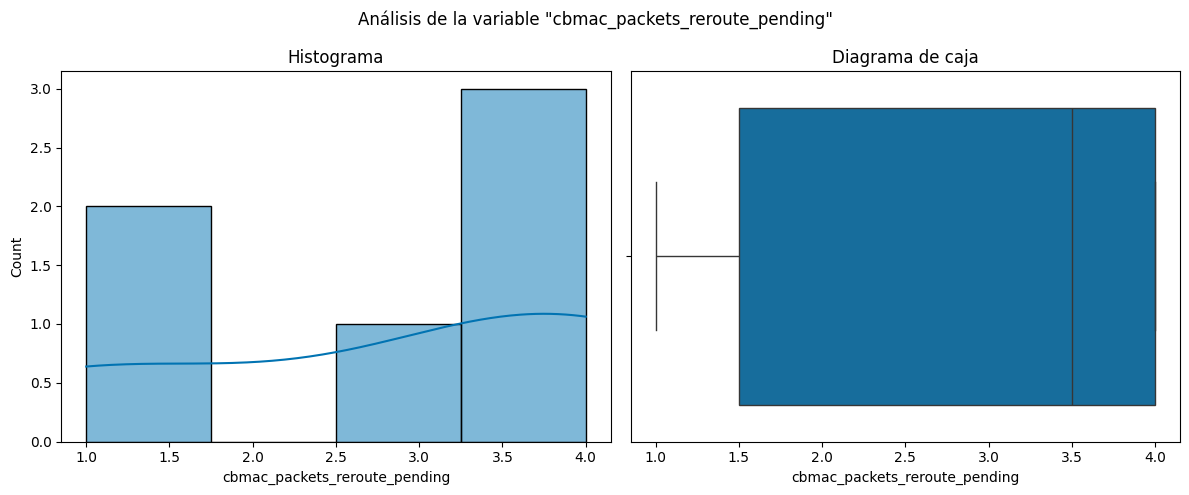

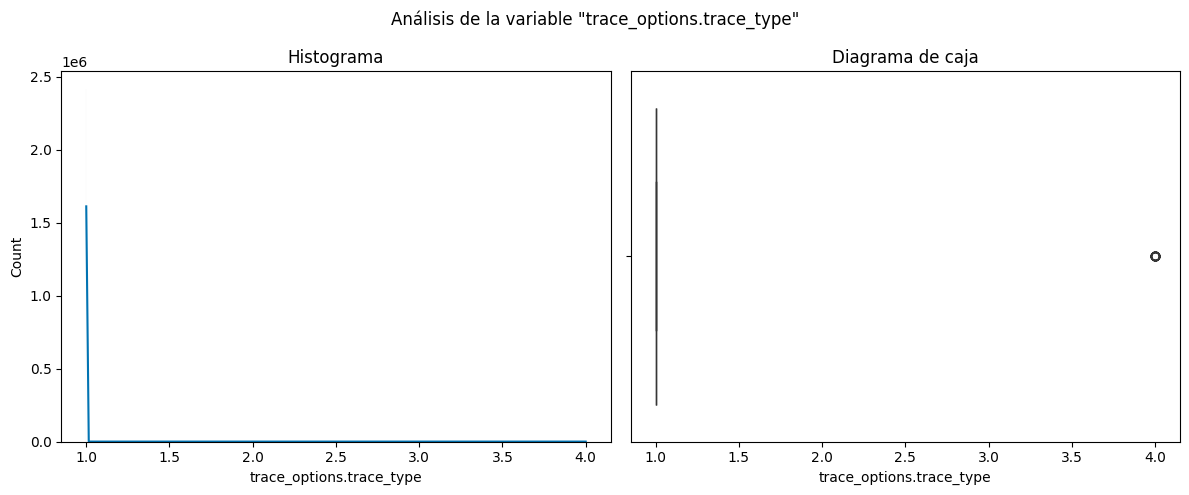

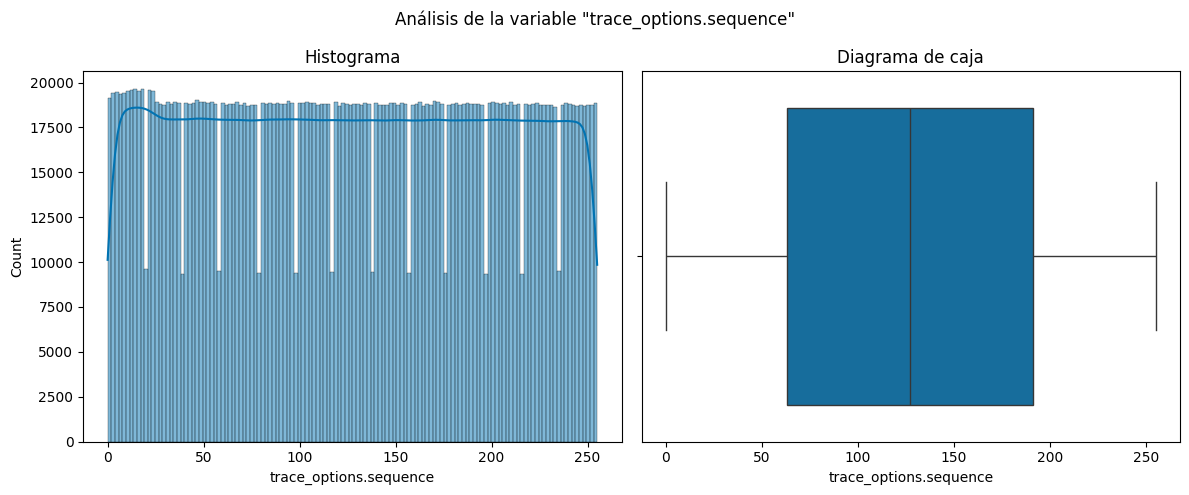

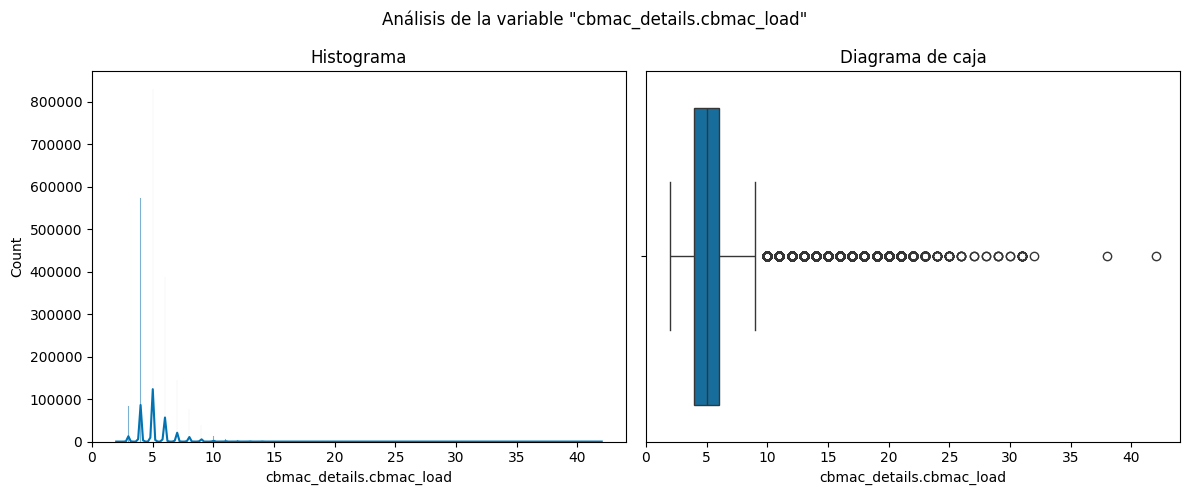

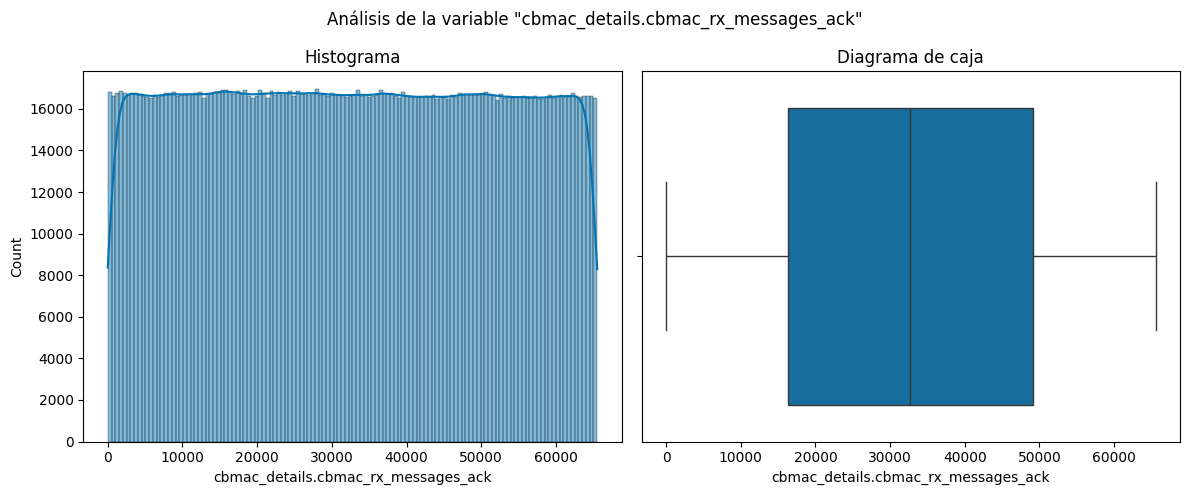

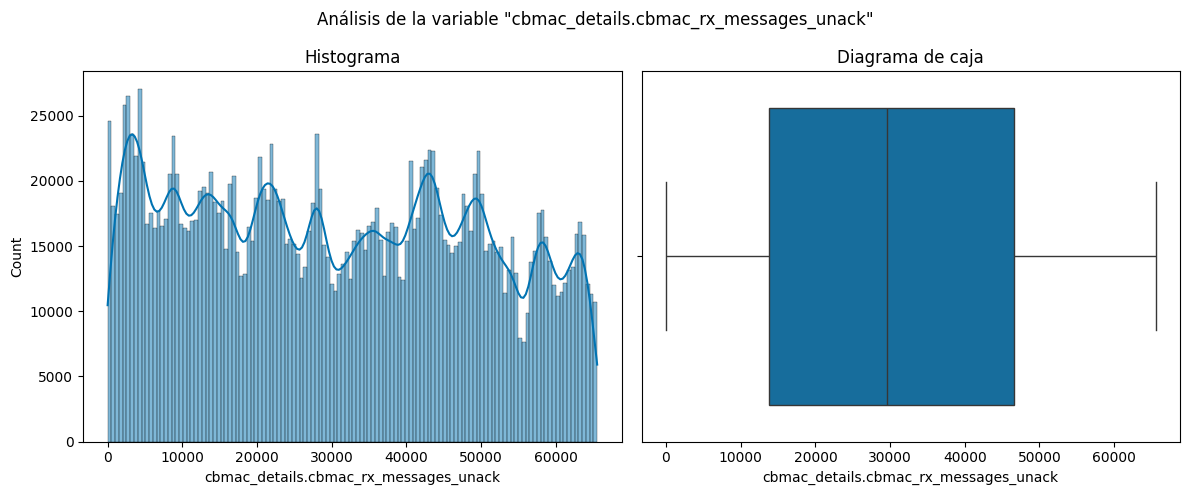

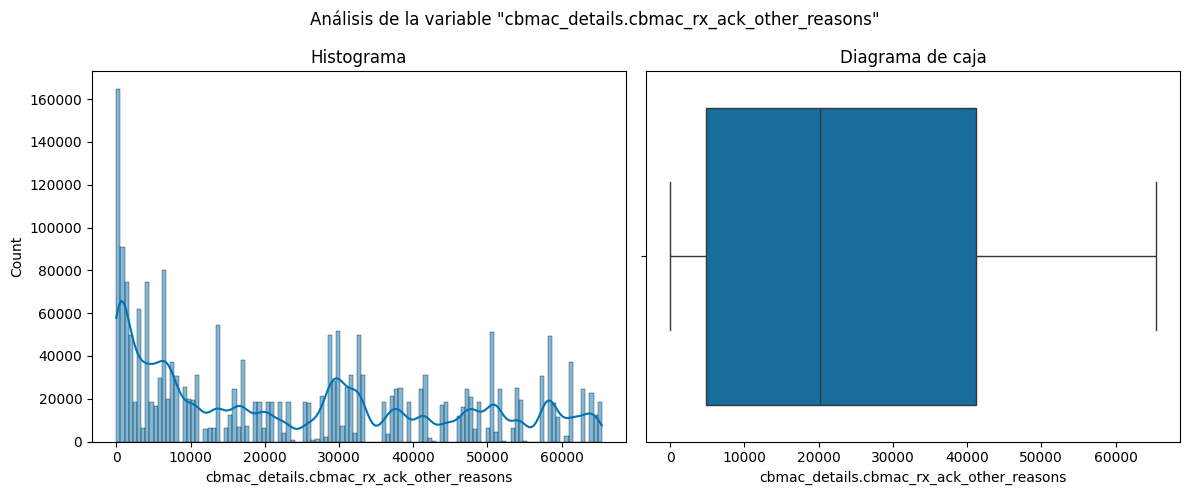

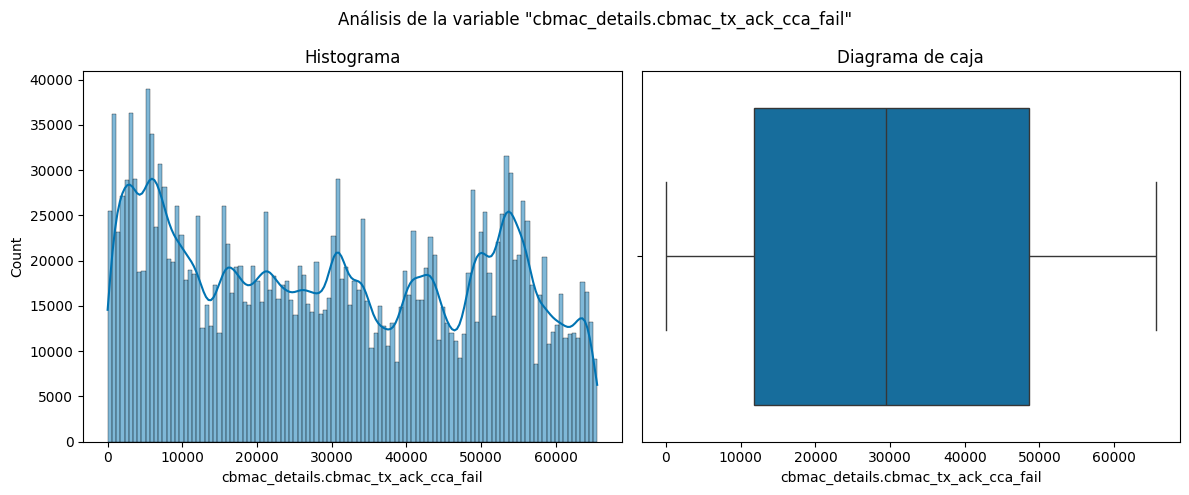

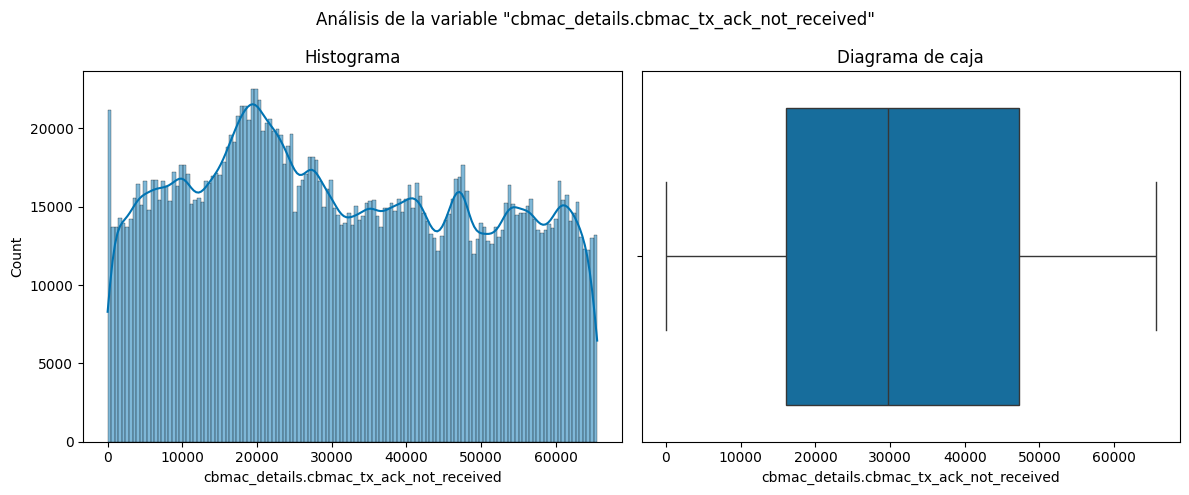

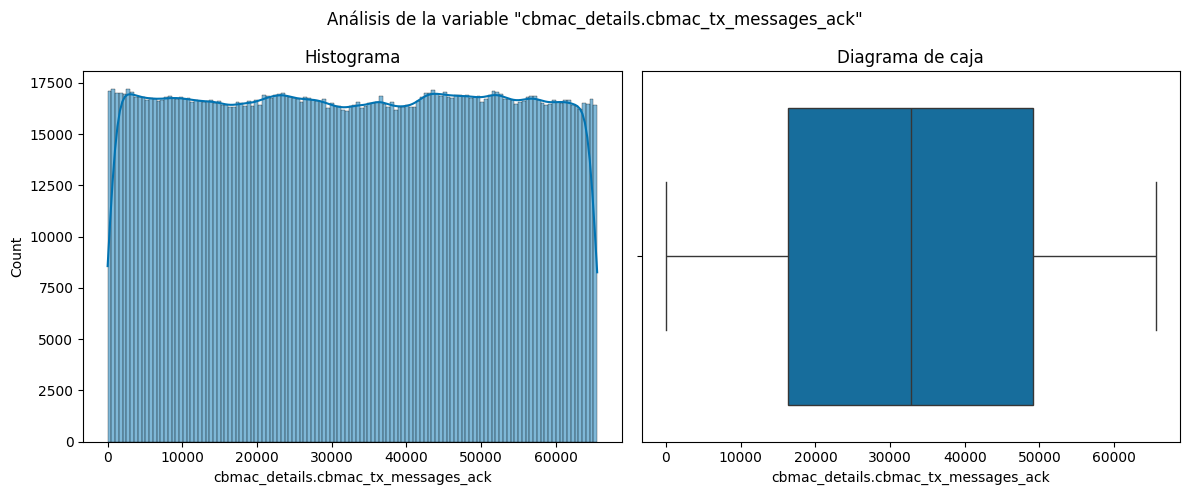

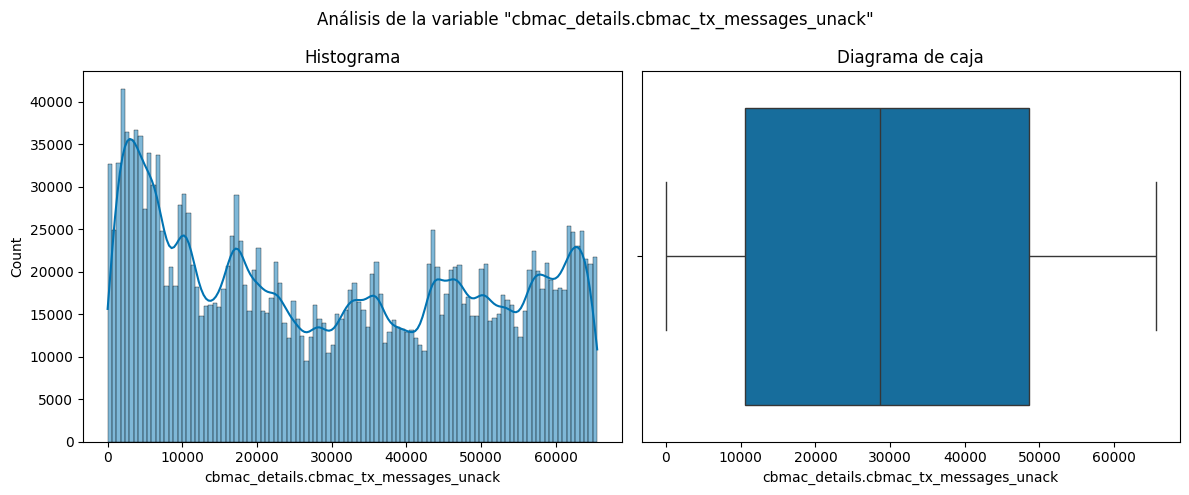

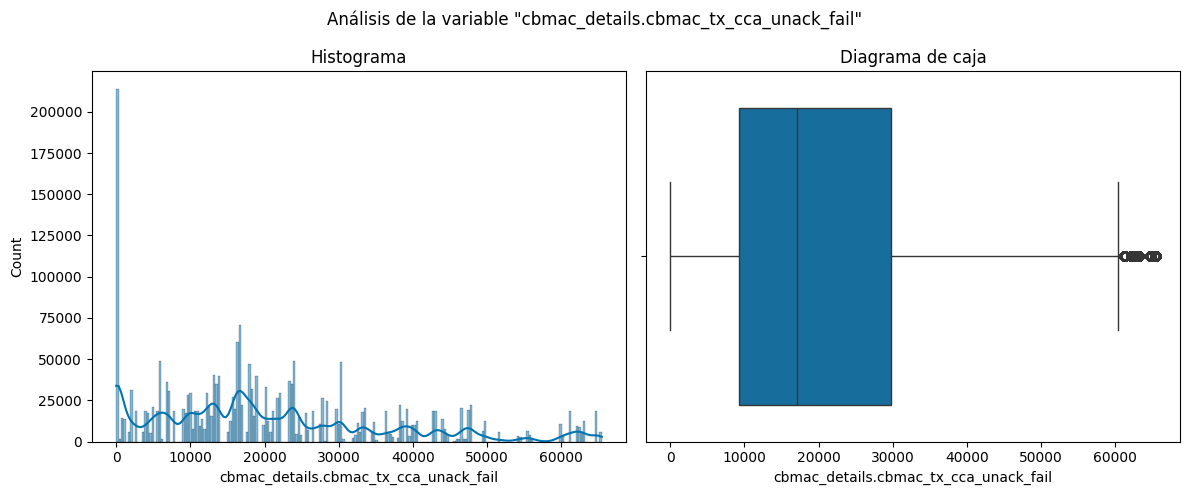

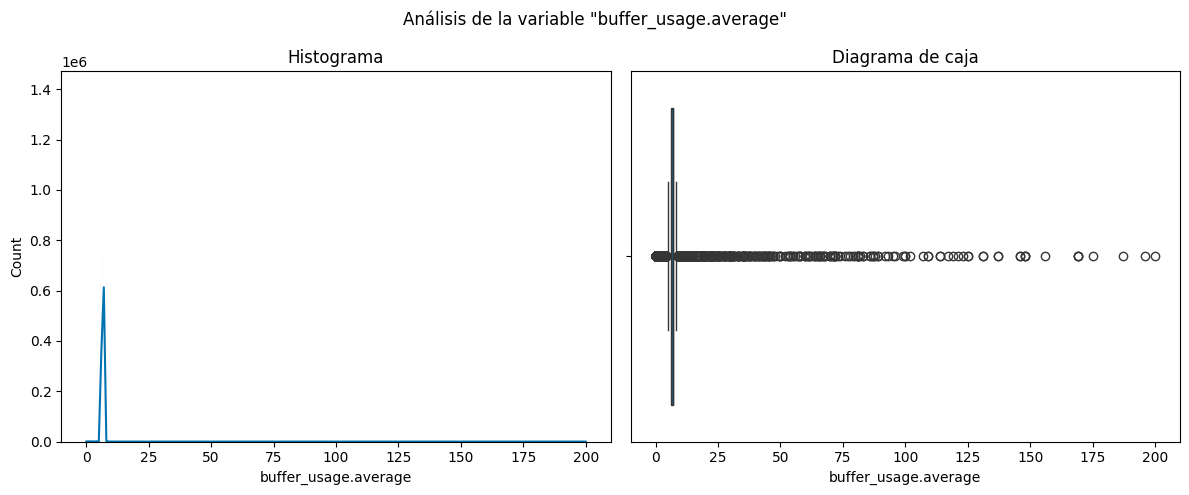

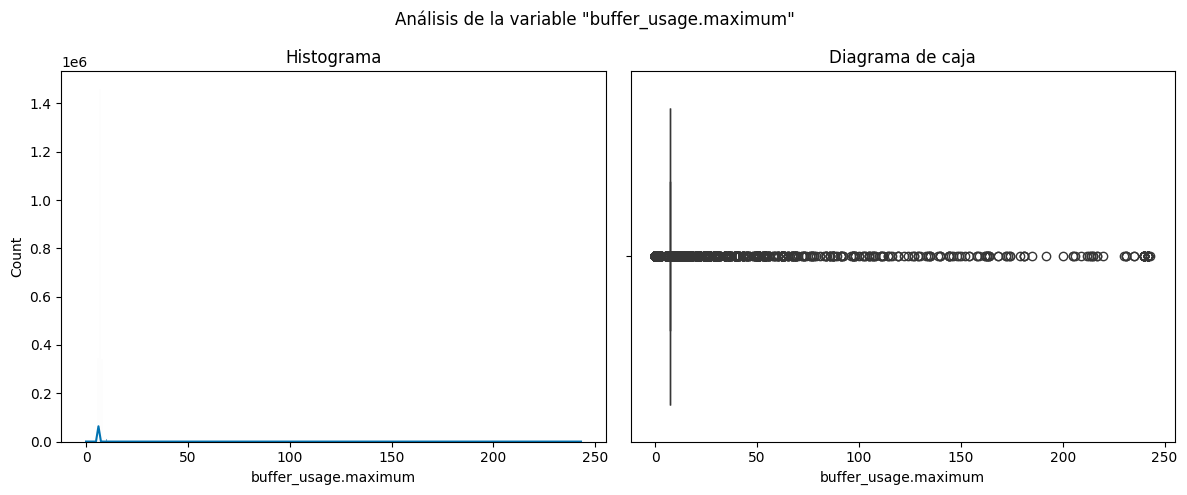

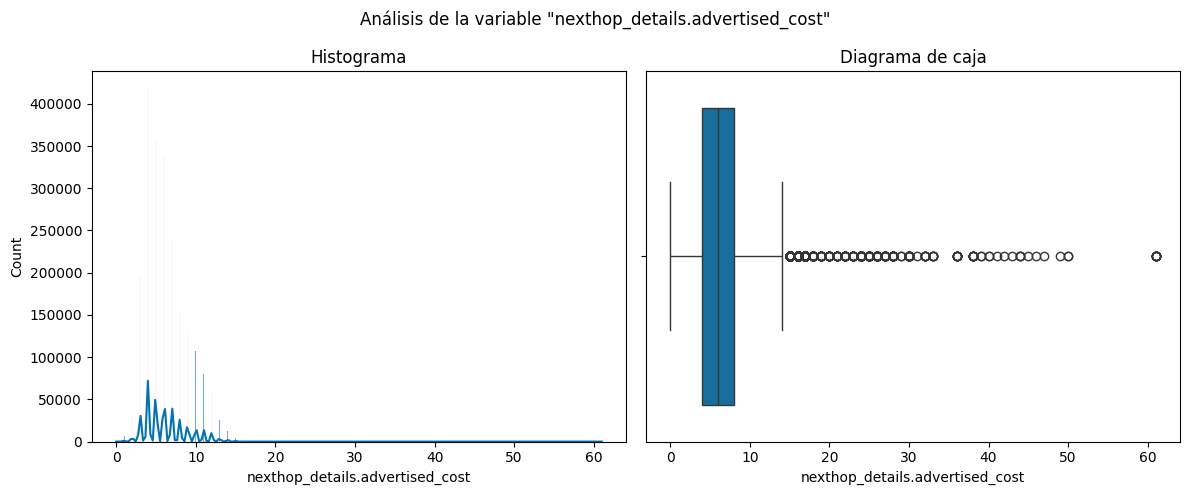

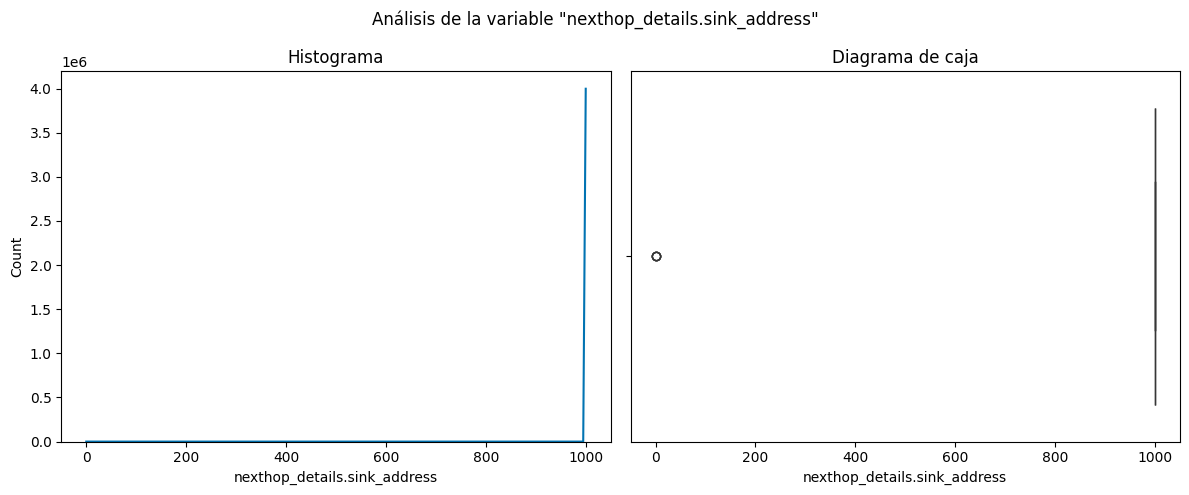

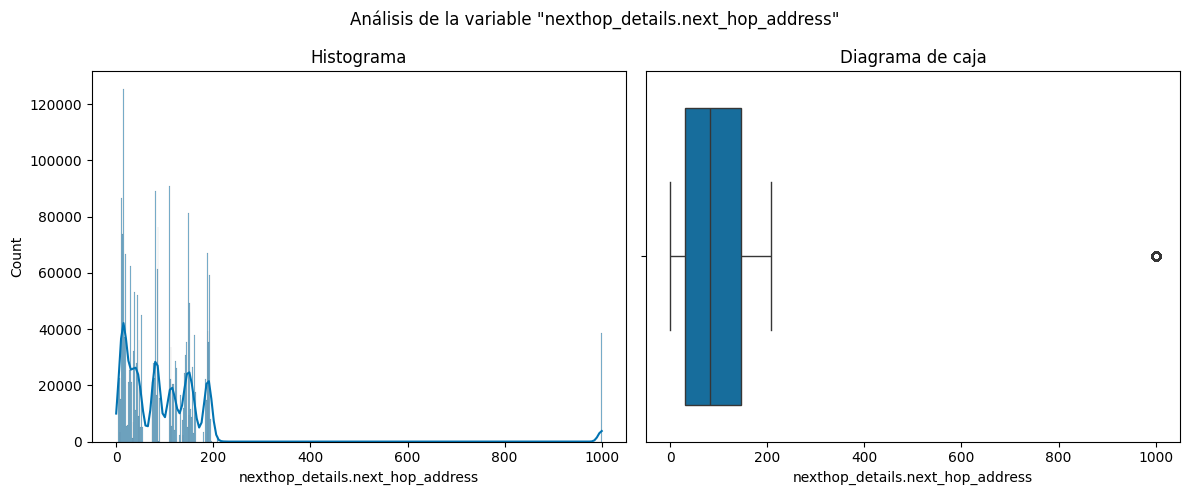

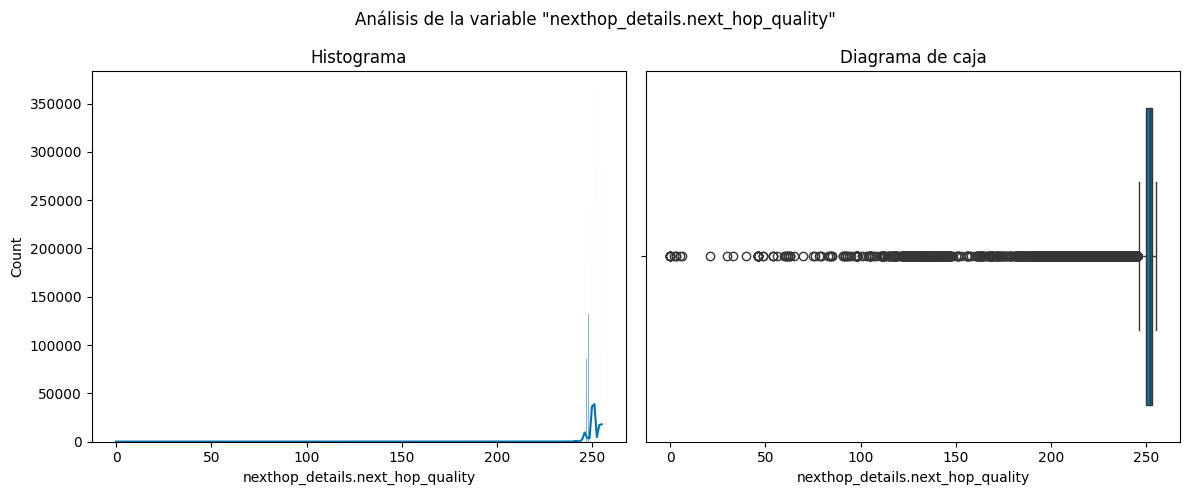

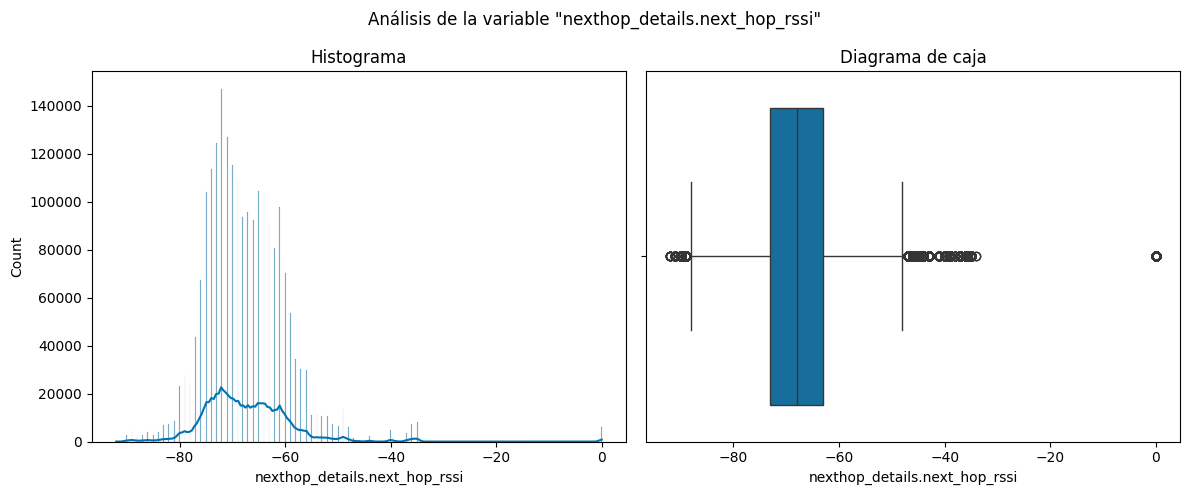

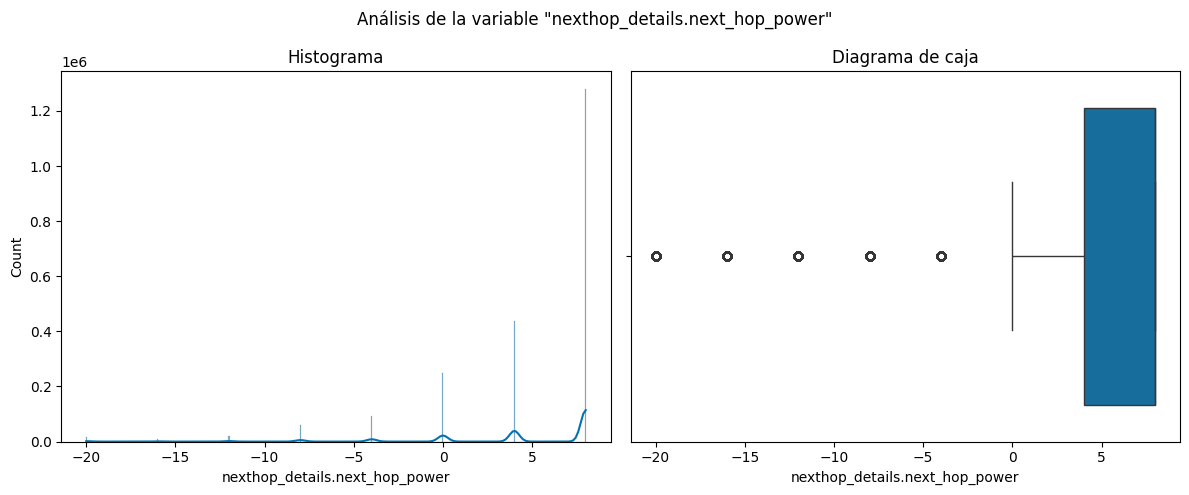

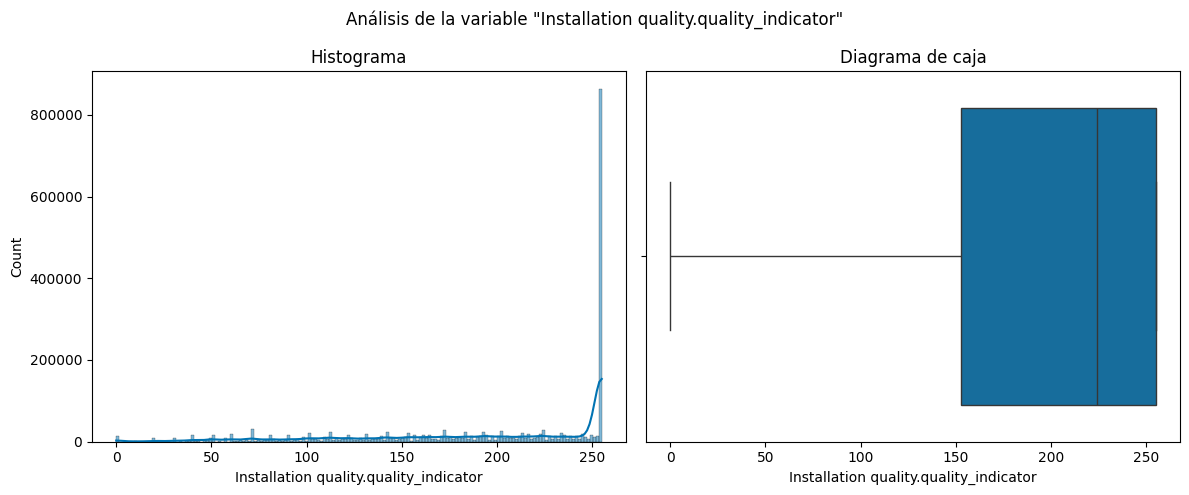

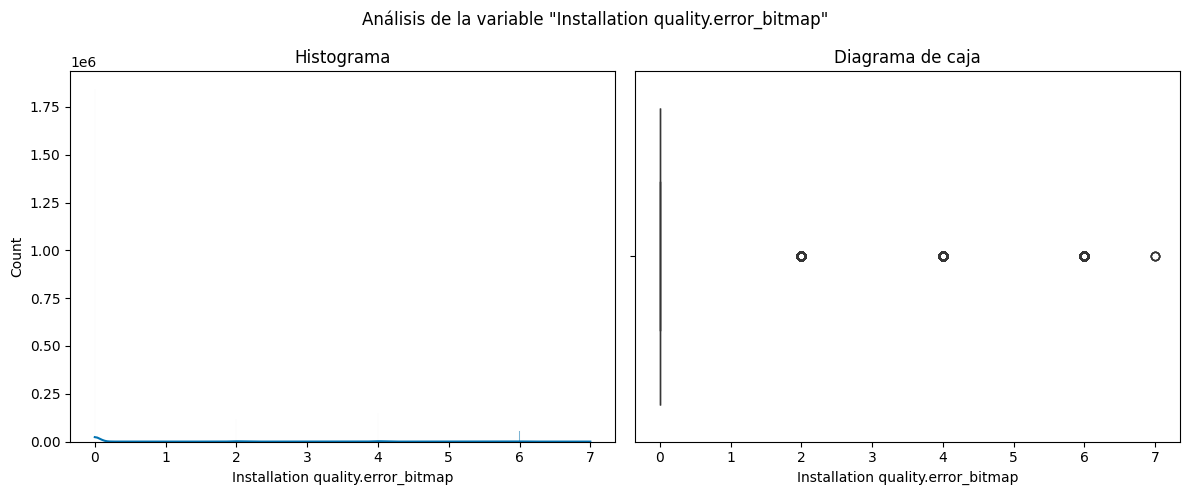

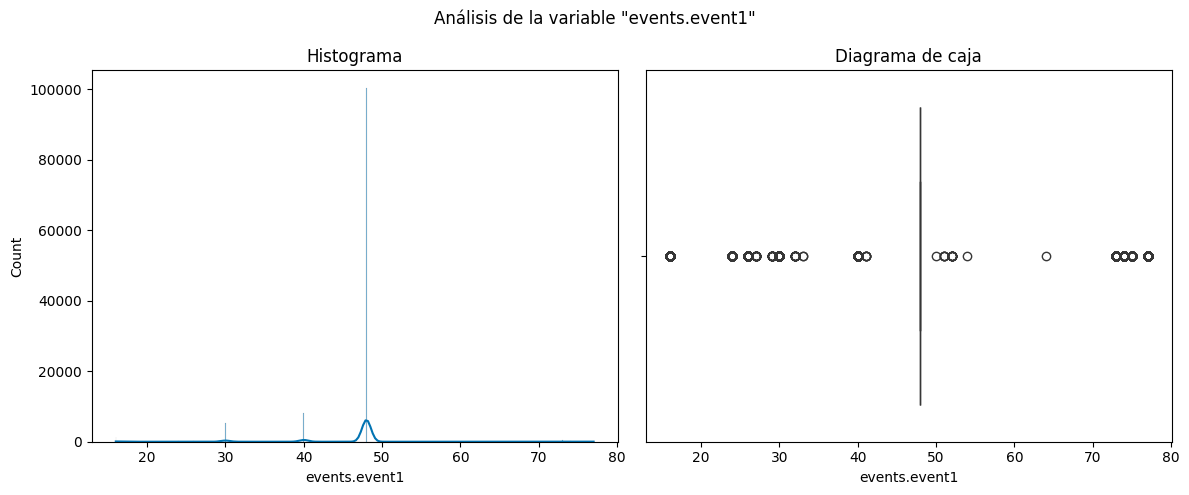

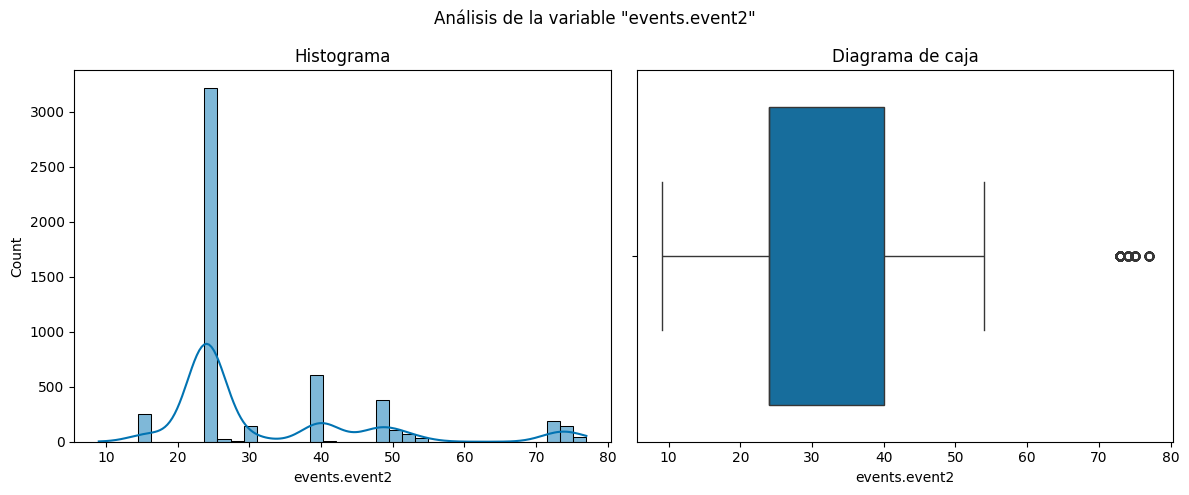

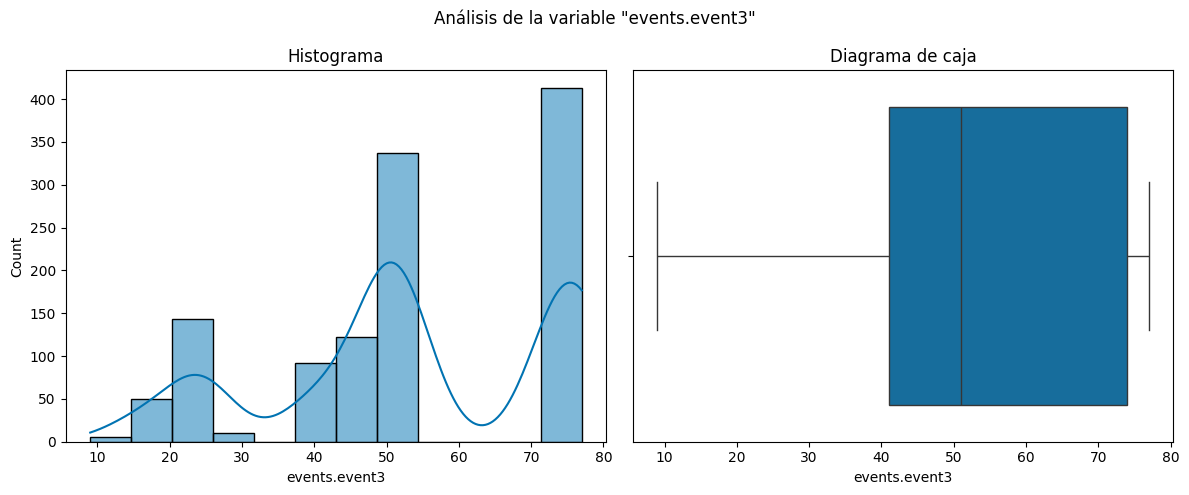

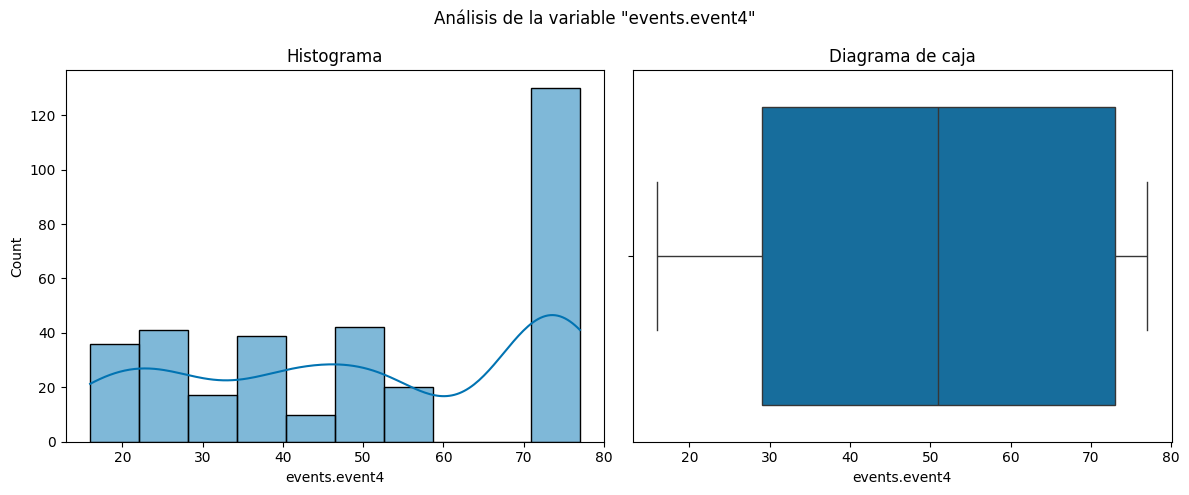

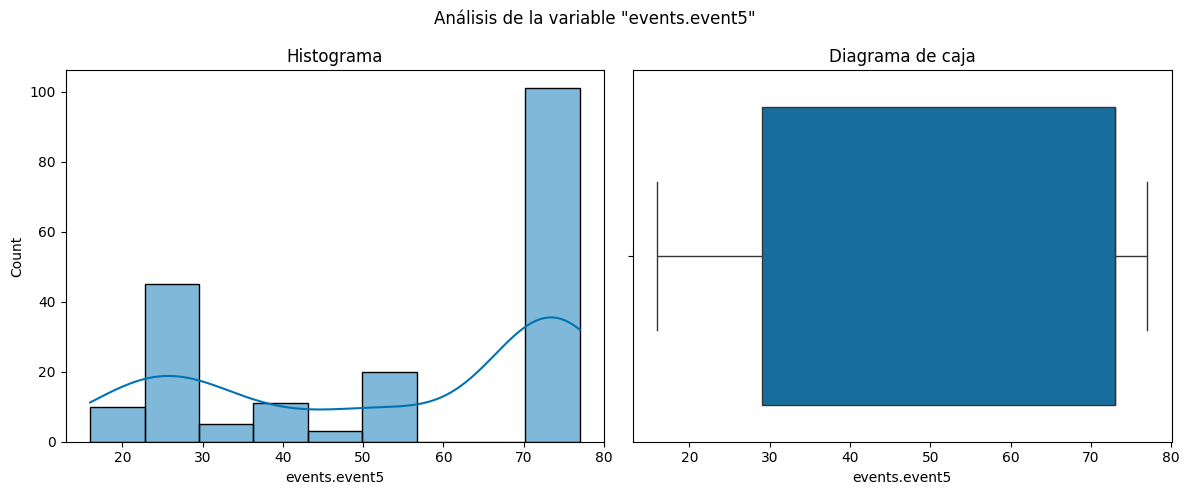

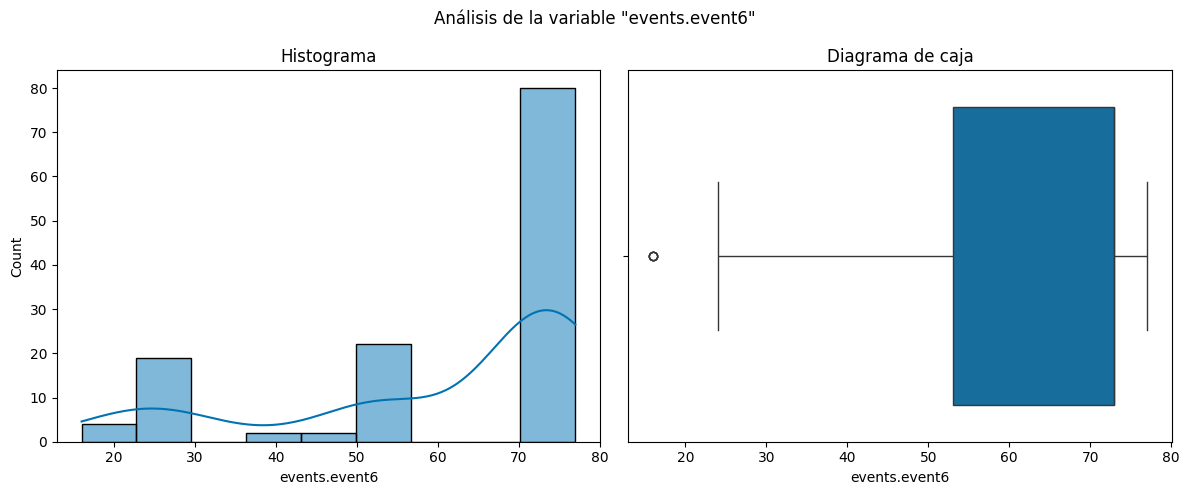

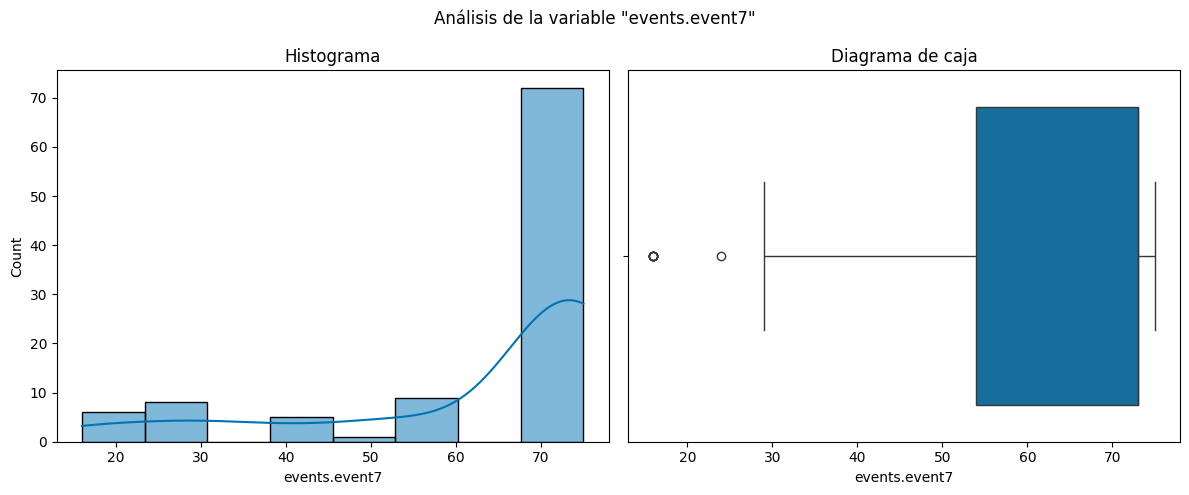

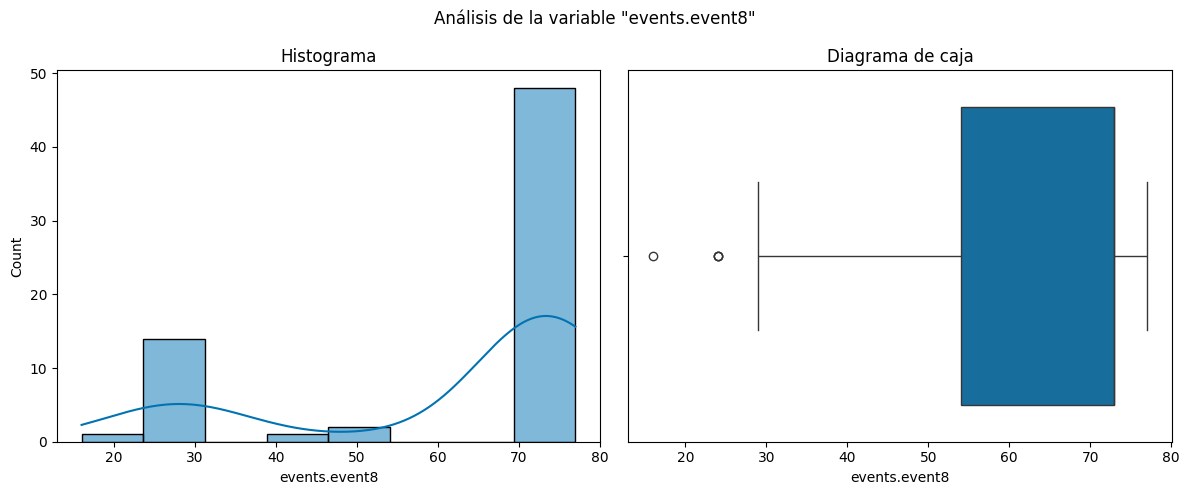

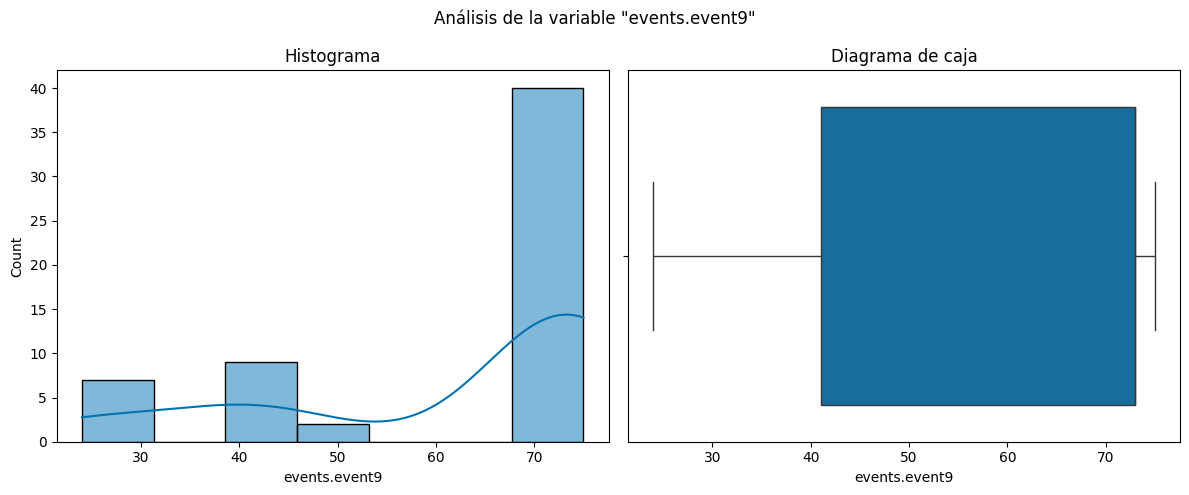

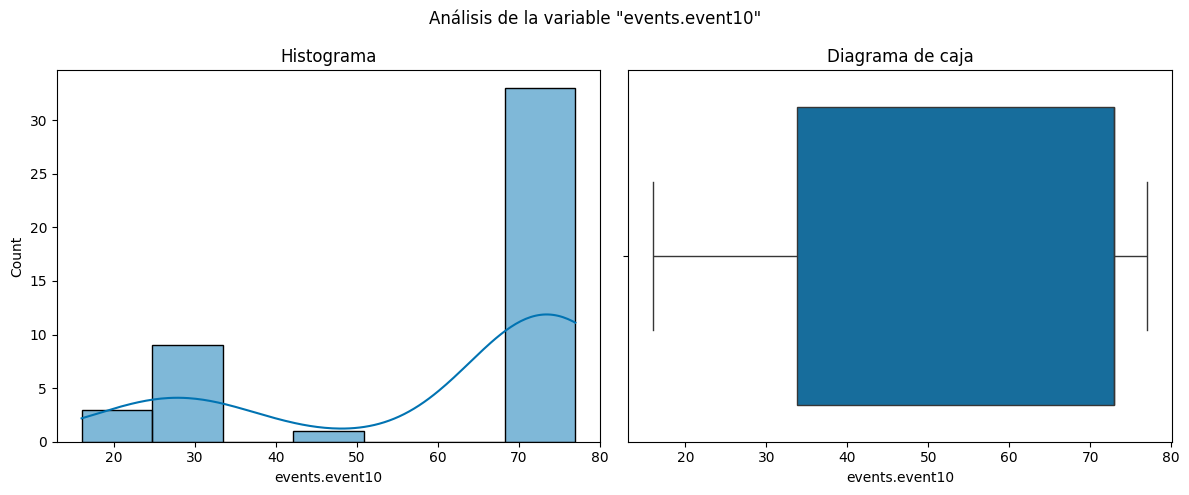

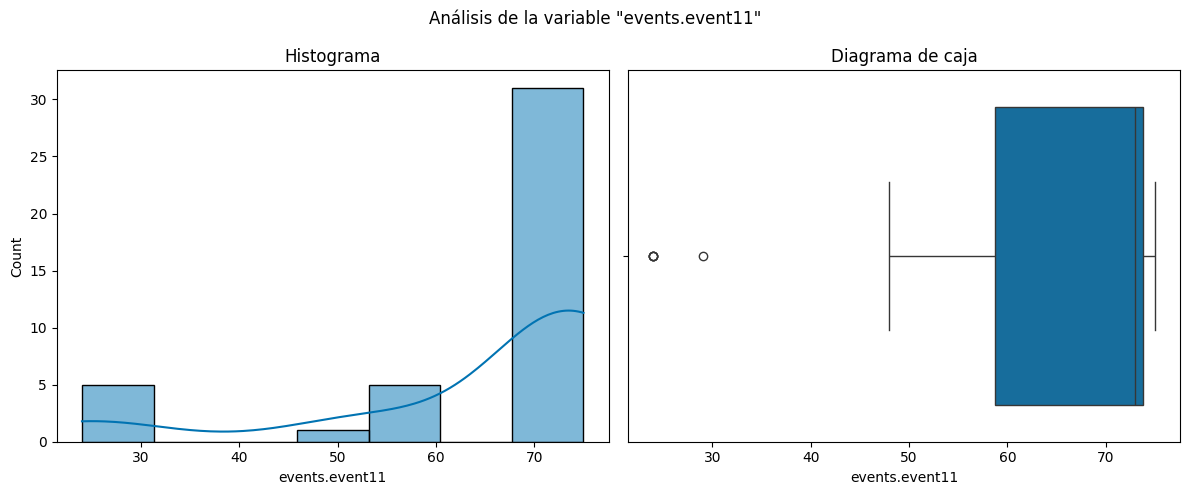

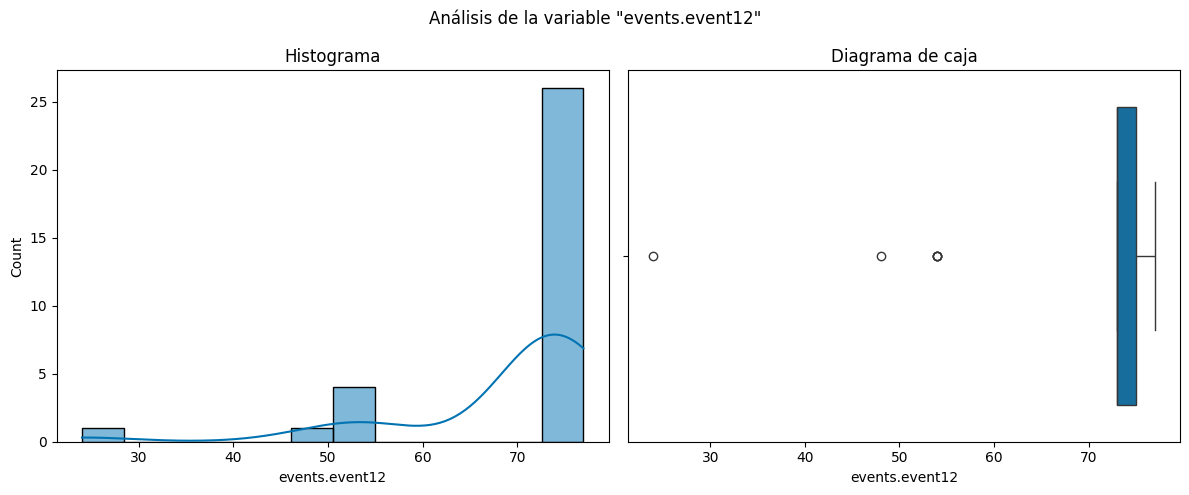

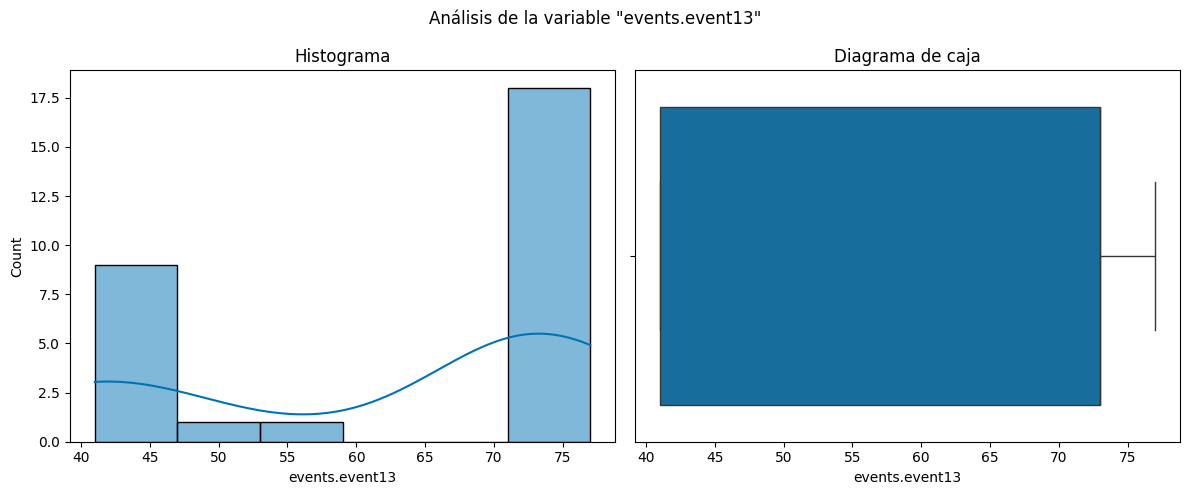

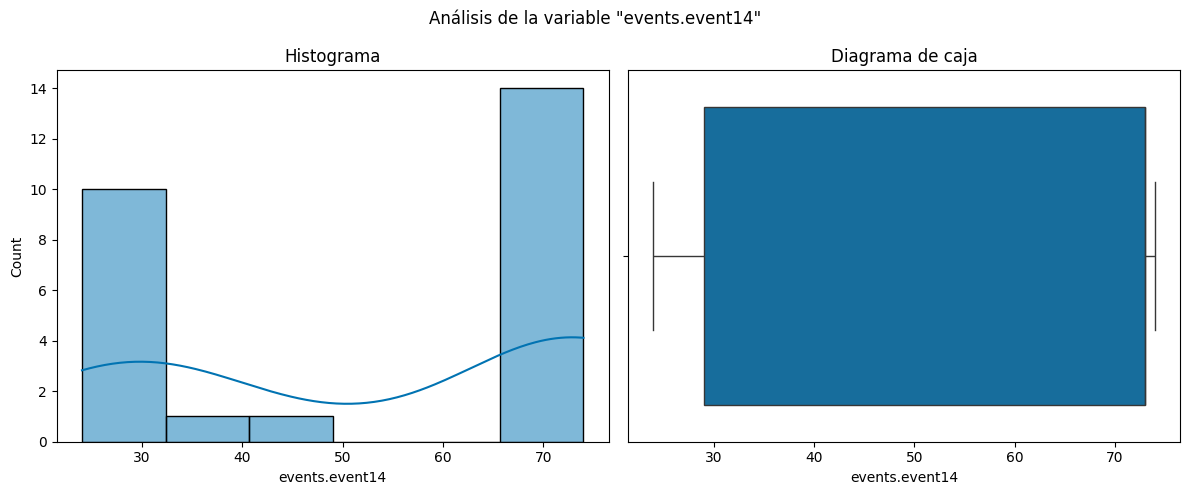

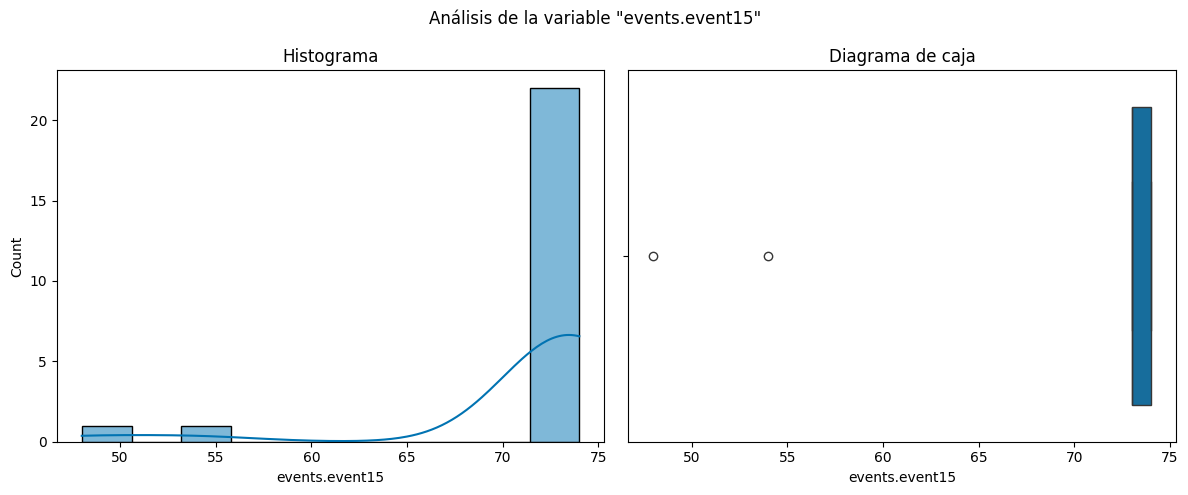

Columnas omitidas y razones:
- two_in_one_battery_level: columna constante
- configuration: columna constante
- last_hw_test_result: columna constante
- last_sw_test_result: columna constante
- configured: columna constante
- sensors: columna constante
- device_type: columna constante
- battery_type: columna constante
- app_firmware_major: columna constante
- app_firmware_minor: columna constante
- app_firmware_maintenaince: columna constante
- app_stack_major: columna constante
- app_stack_maintenaince: columna constante
- events: columna constante
- cbmac_broadcast_unack_pending: columna constante
- CCA_limit_dBm: columna constante
- Rx_gain: columna constante
- boot_fault_reason: columna constante
- stack_profile: columna constante
- scratchpad_processed_sequence: columna constante
- otap_support: columna constante
- cbmac_details: columna constante
- buffer_usage: columna constante
- nexthop_details: columna constante
- Installation quality: columna constante
- trace_options: colum

In [ ]:
# Create plots
skipped = {}
const_cols = []
for column in numerical_features:
    try:
        # Extraer la columna
        x = X_train[column]

        # Comprobar que queda más de 1 valor
        if len(x) < 2:
            skipped[column] = "menos de 2 valores"
            continue

        # Evitar columnas constantes (boxplot rompe si no varían)
        if x.nunique() < 2:
            skipped[column] = "columna constante"
            continue

        # Graficar
        plt.figure(figsize=(12,5))

        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(x, kde=True)
        plt.title("Histograma")

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=x)
        plt.title("Diagrama de caja")

        plt.suptitle(f'Análisis de la variable \"{column}\"')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error en la columna '{column}': {e}")

print("Columnas omitidas y razones:")
for col, reason in skipped.items():
    if reason == "columna constante":
        const_cols.append(col)
    print(f"- {col}: {reason}")

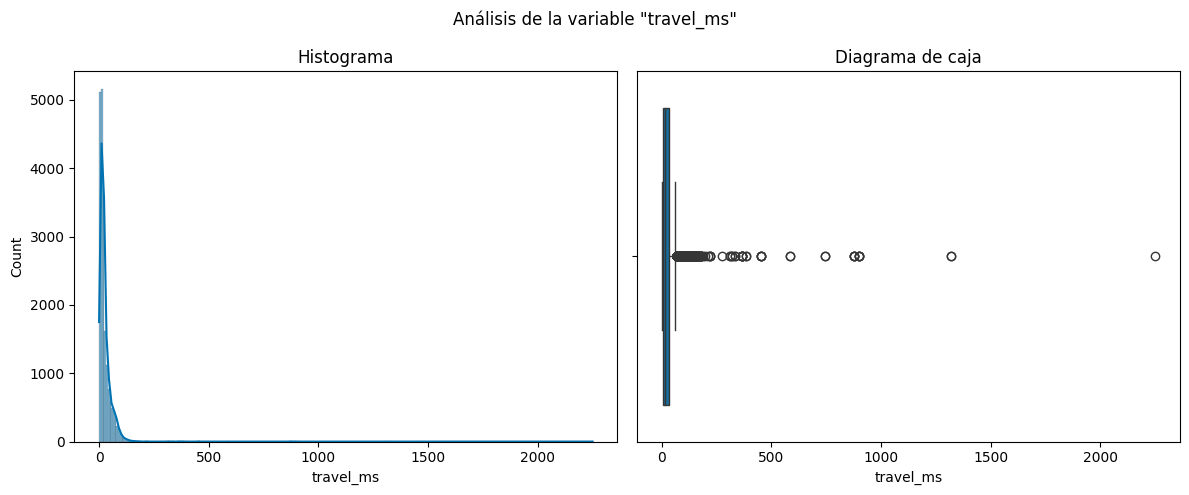

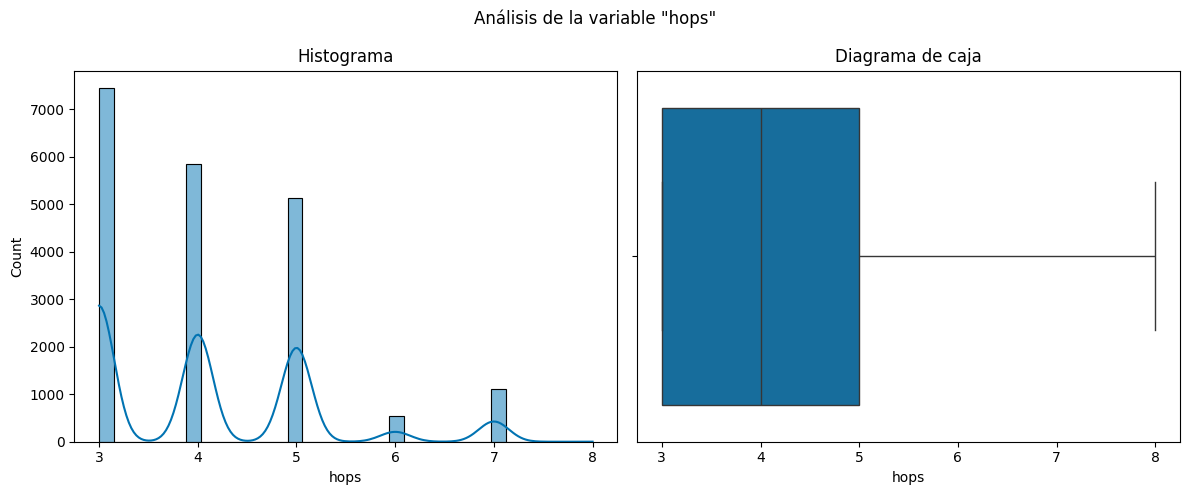

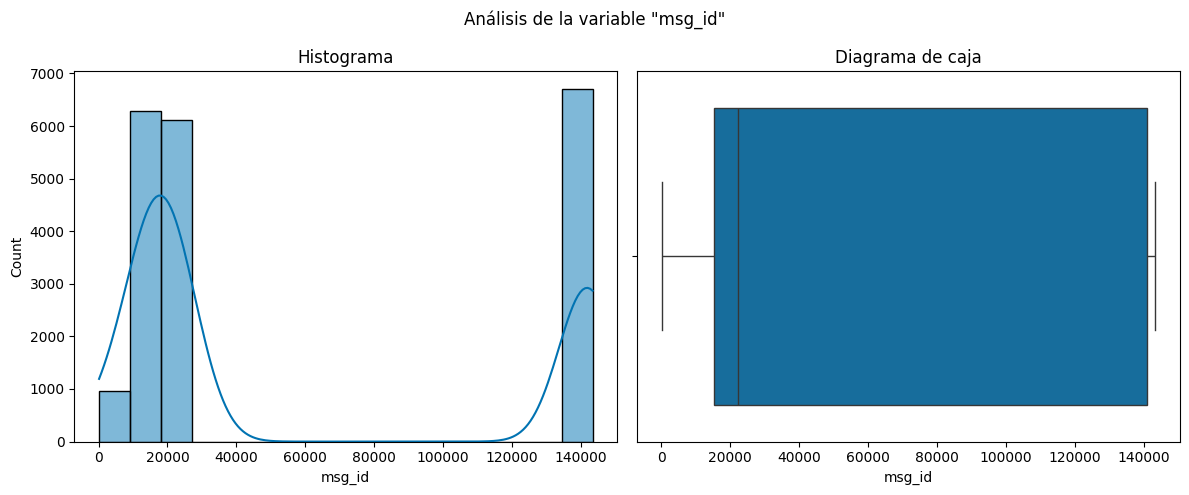

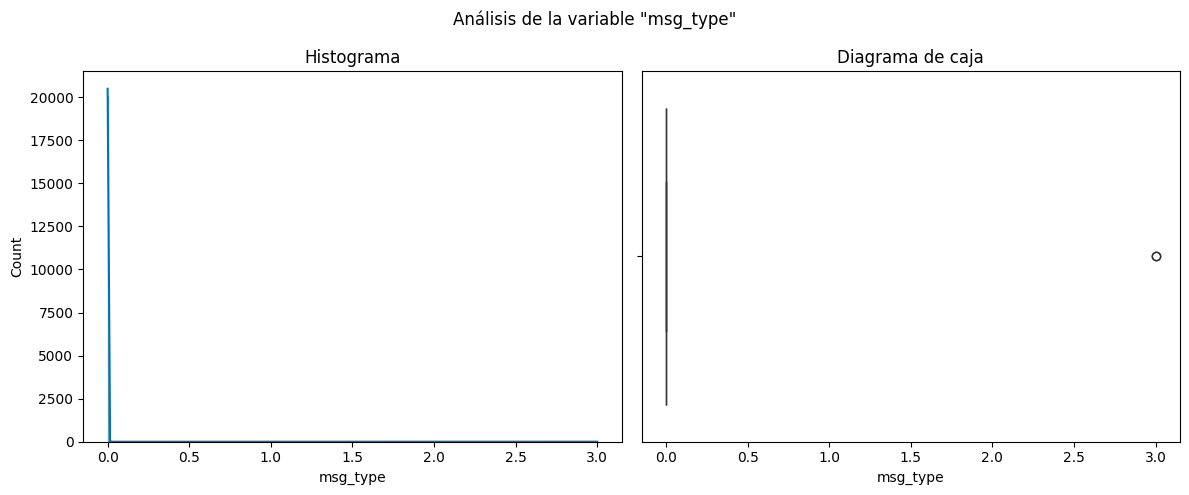

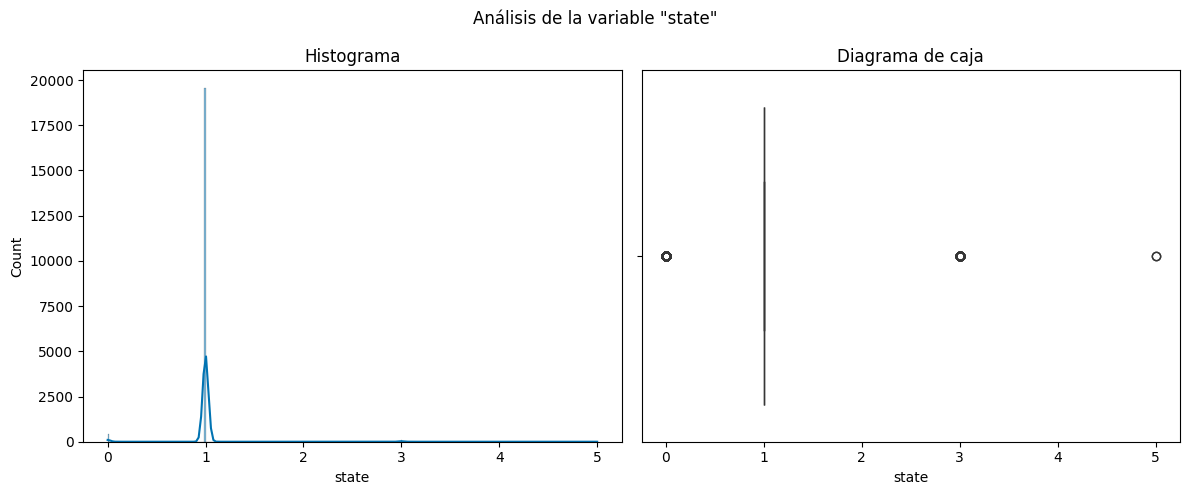

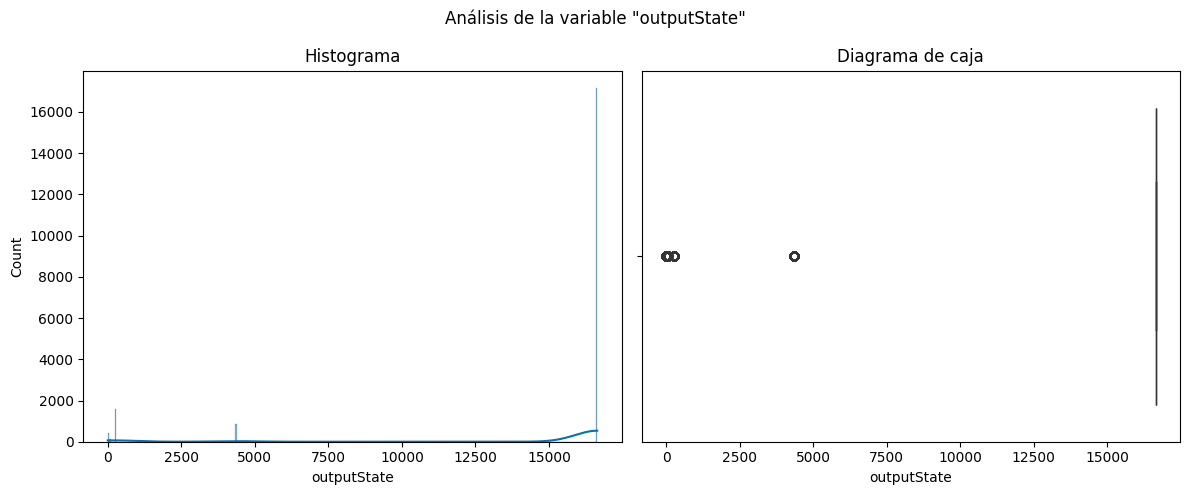

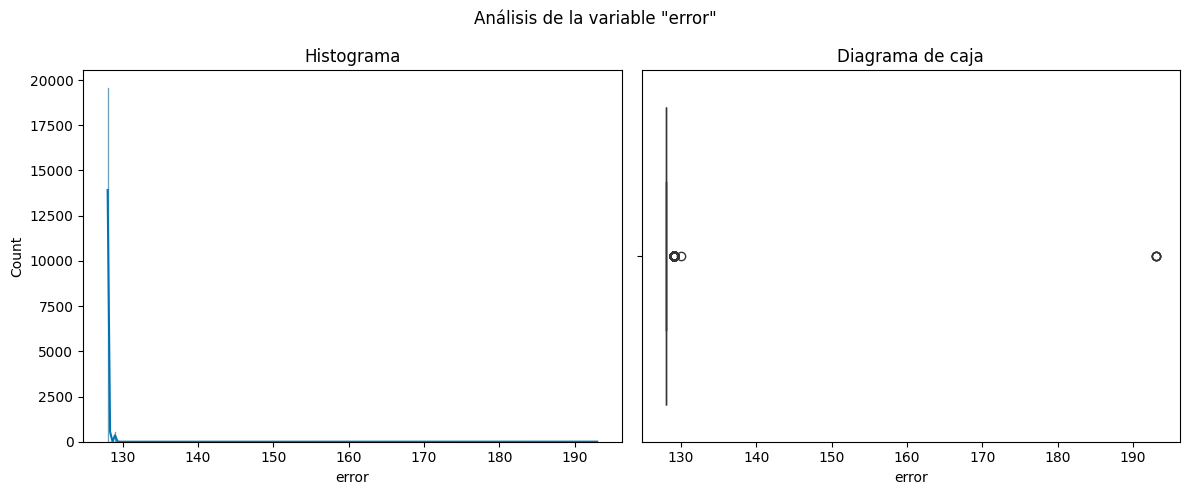

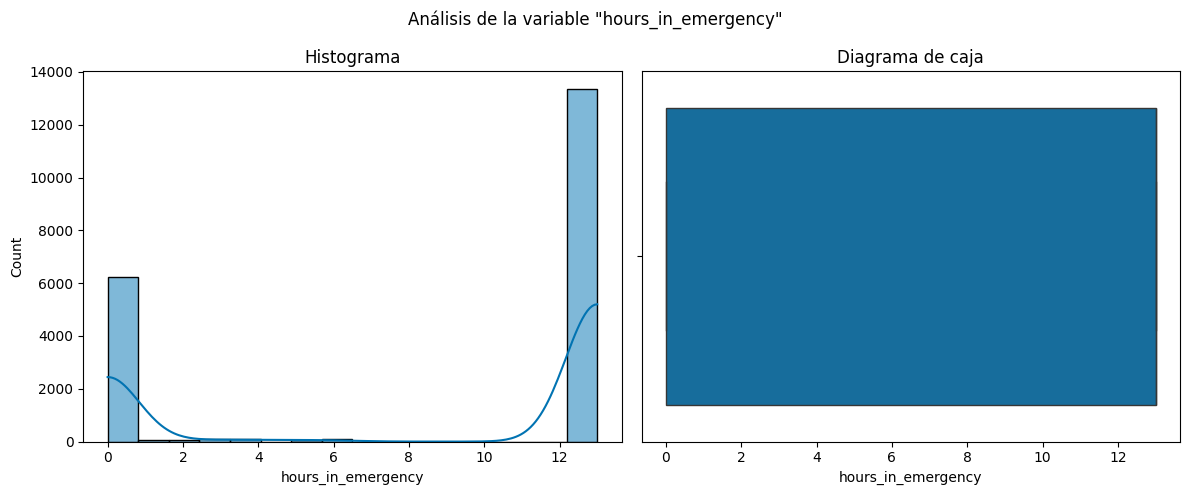

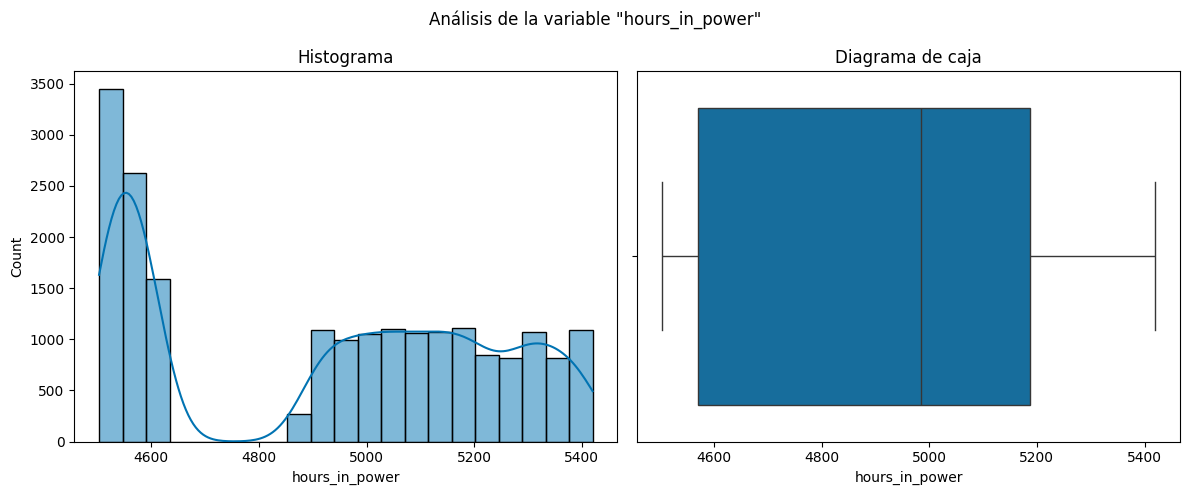

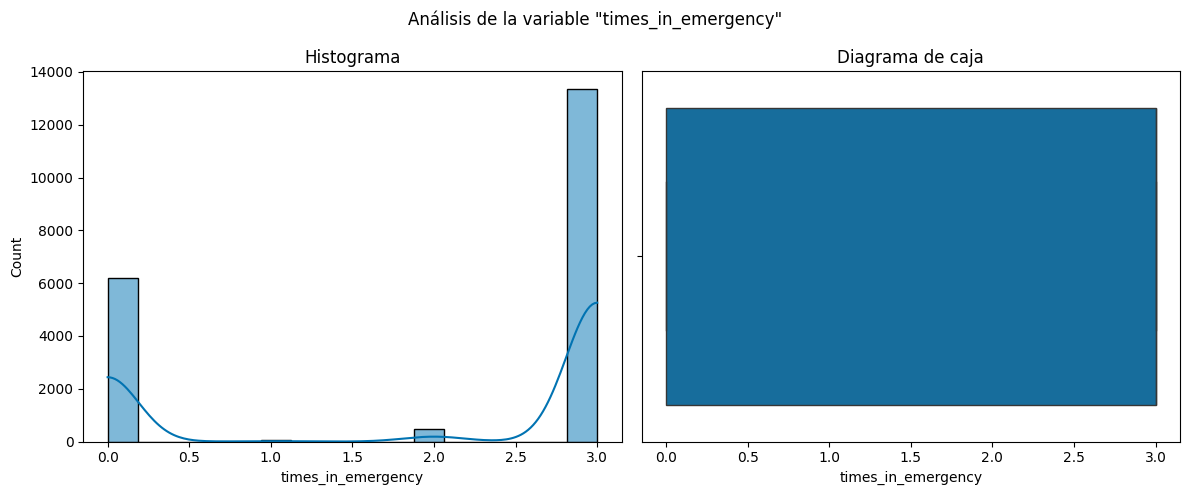

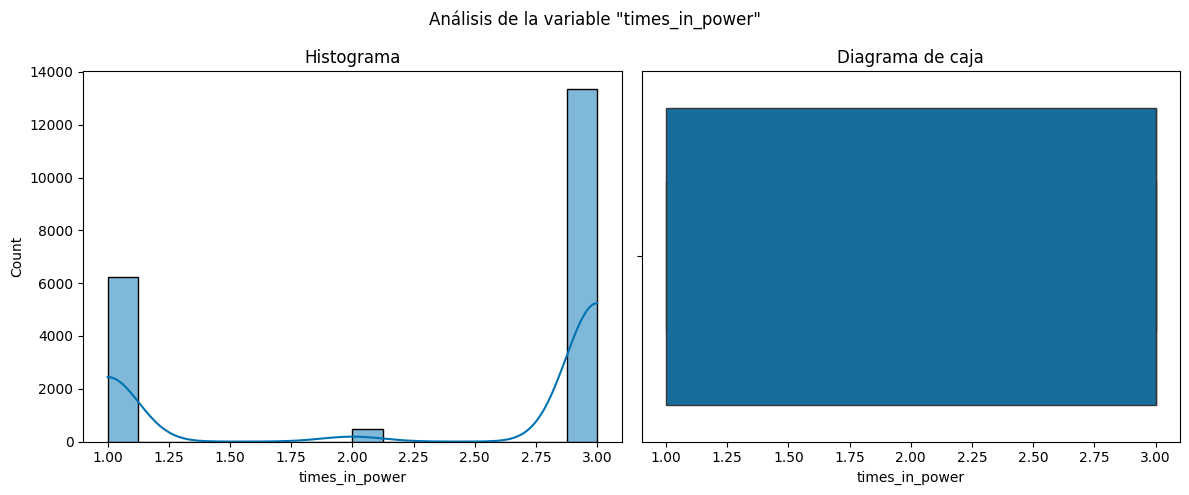

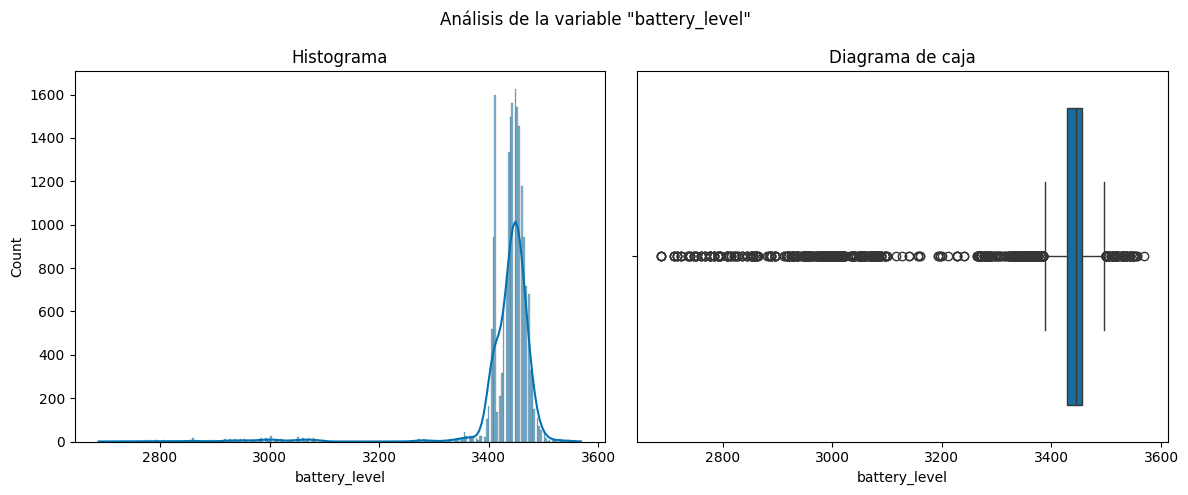

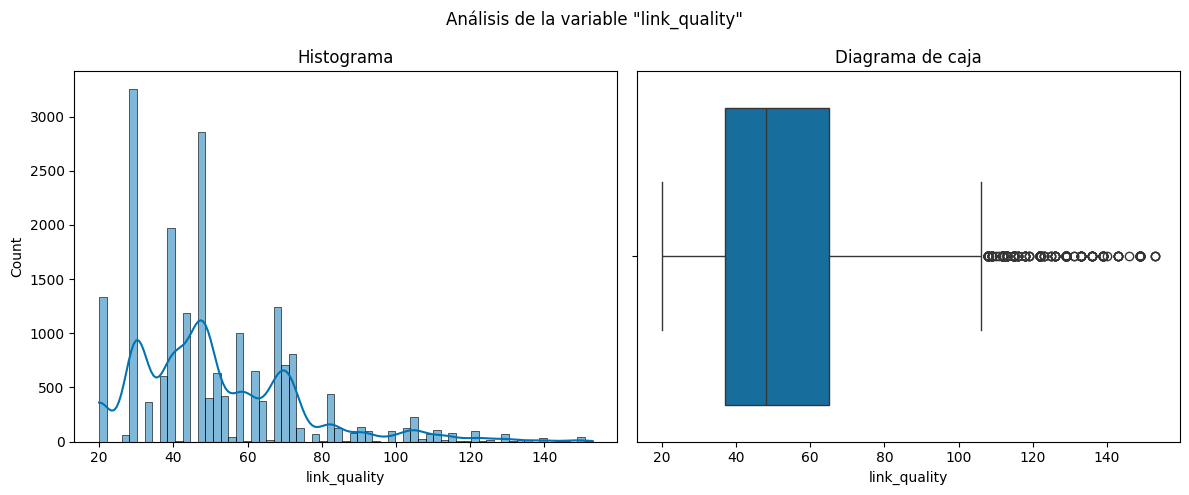

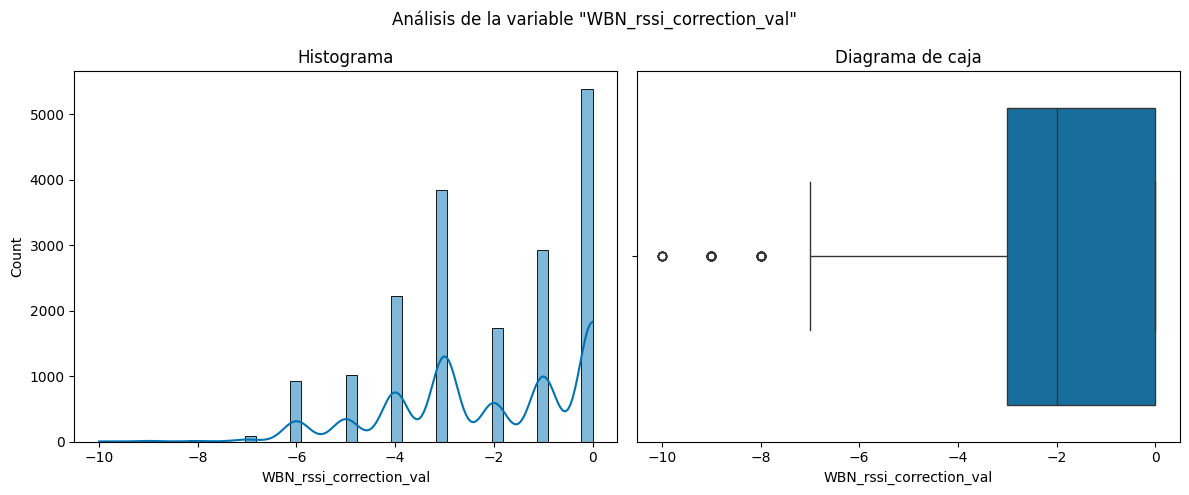

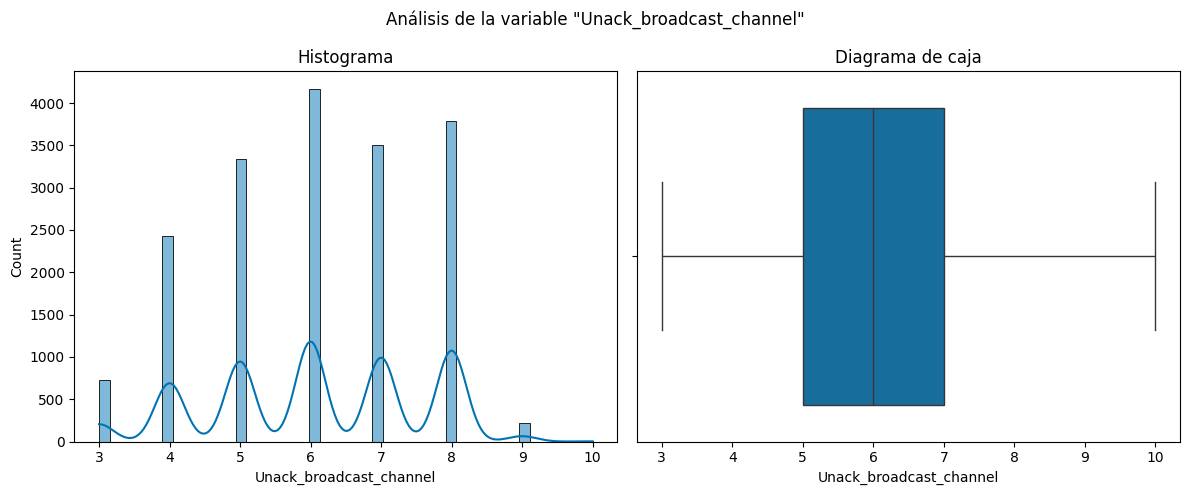

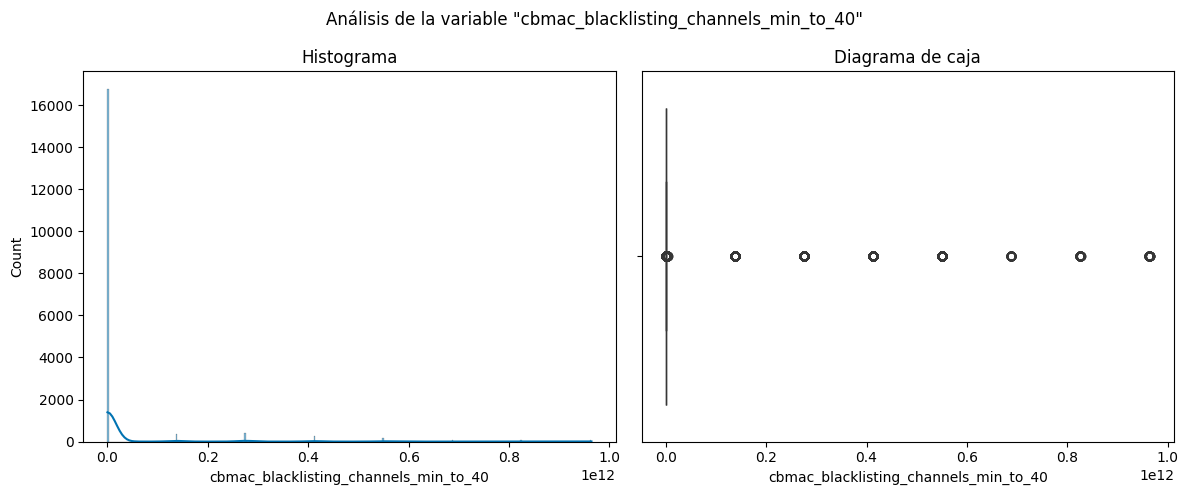

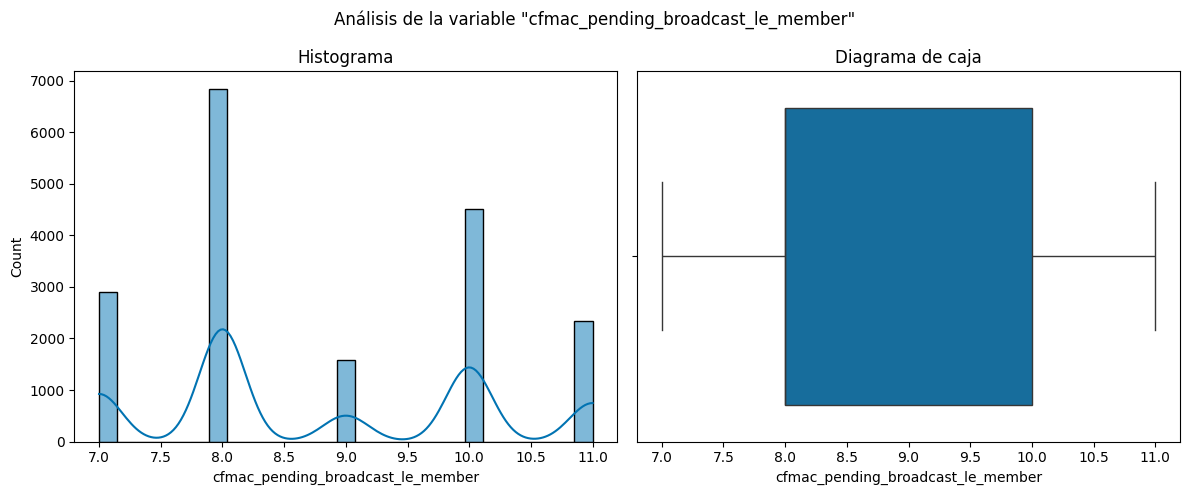

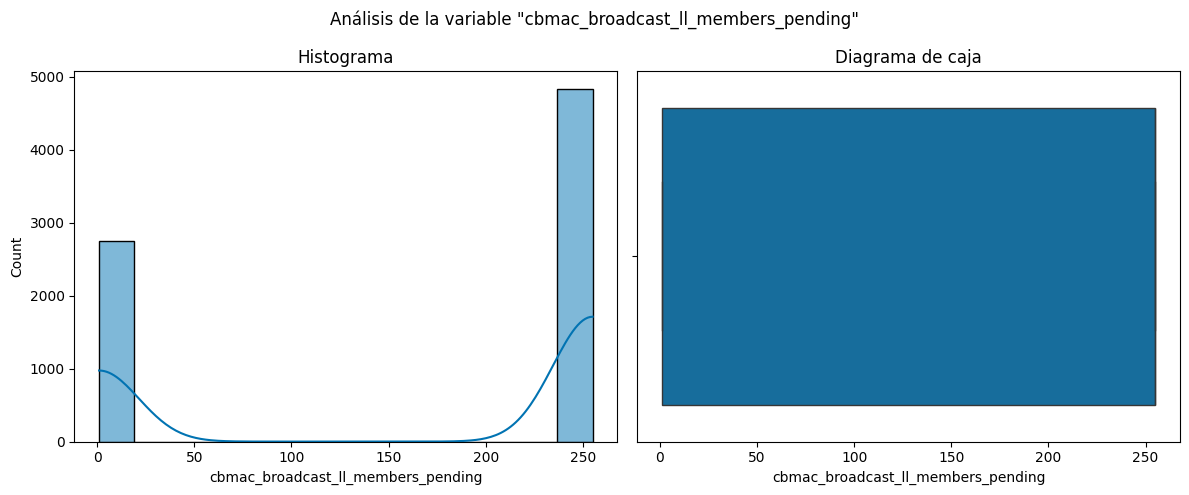

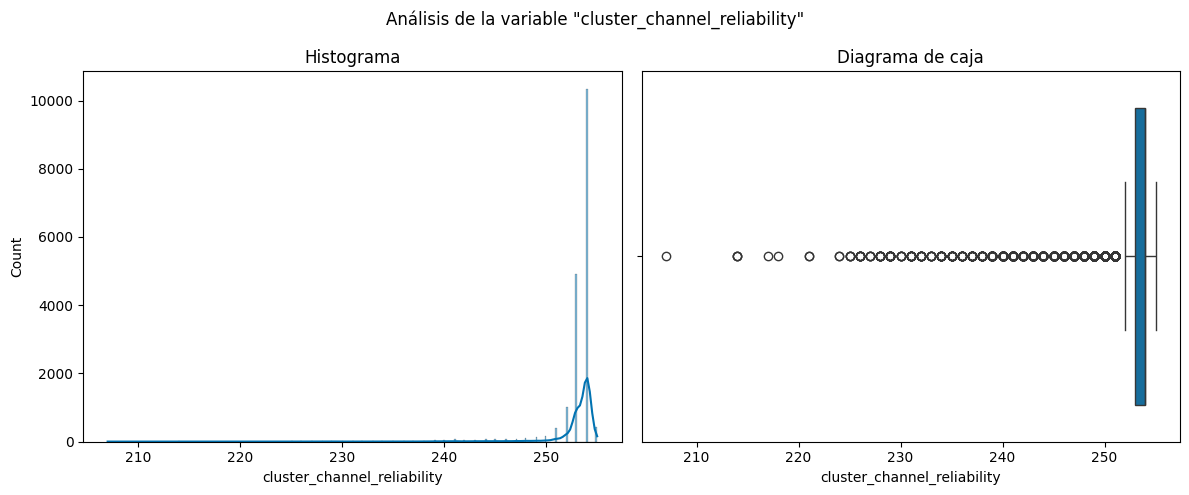

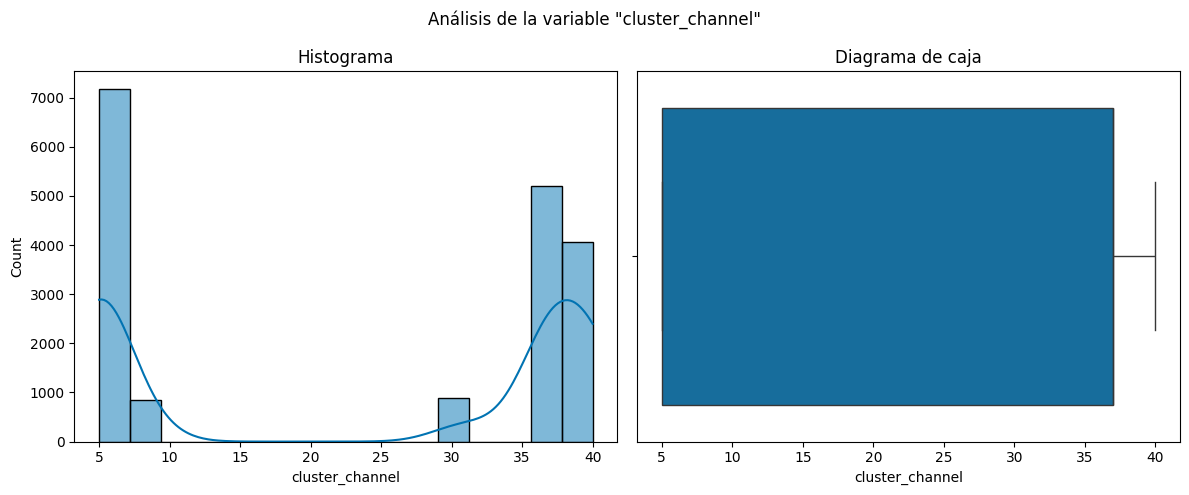

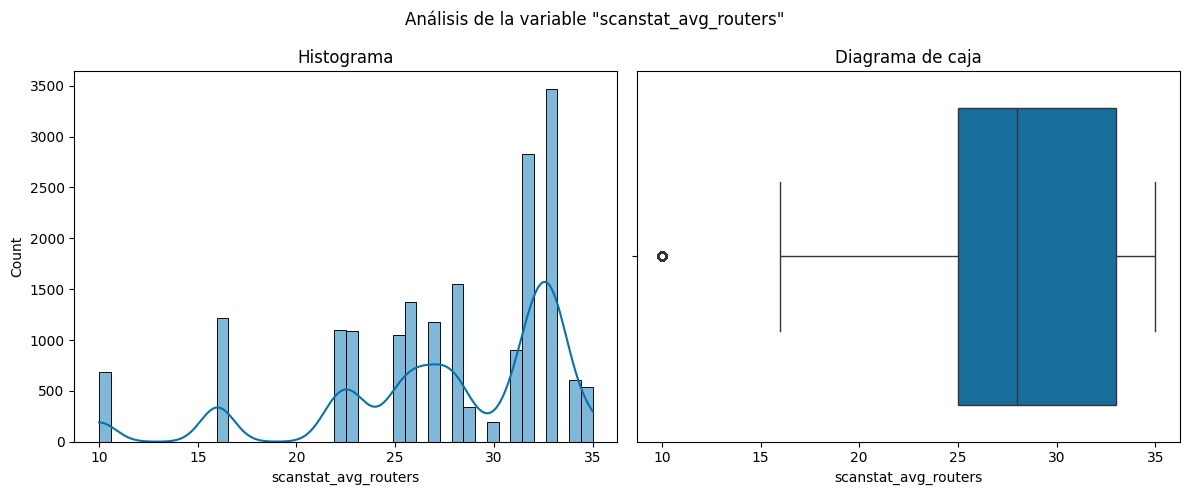

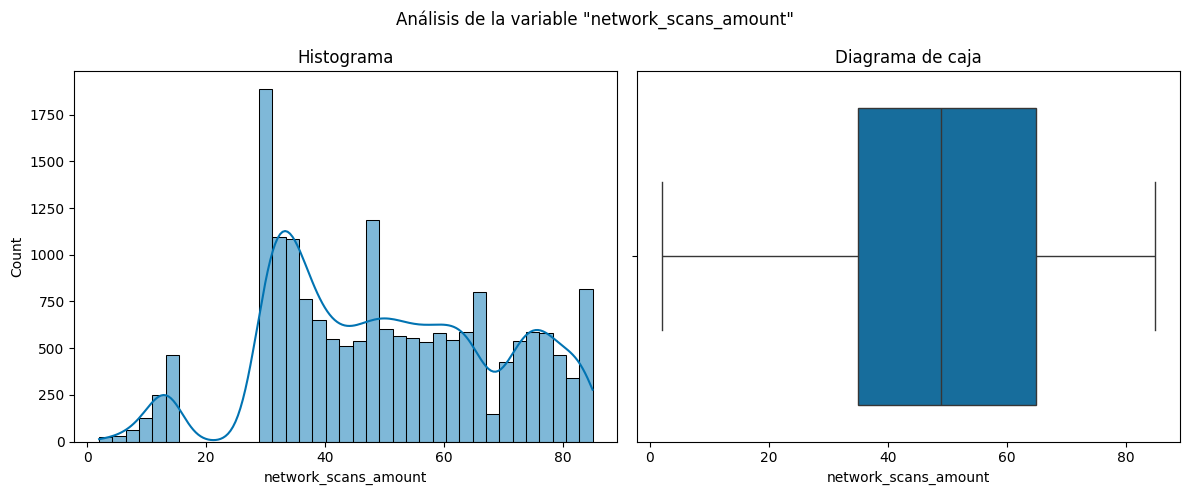

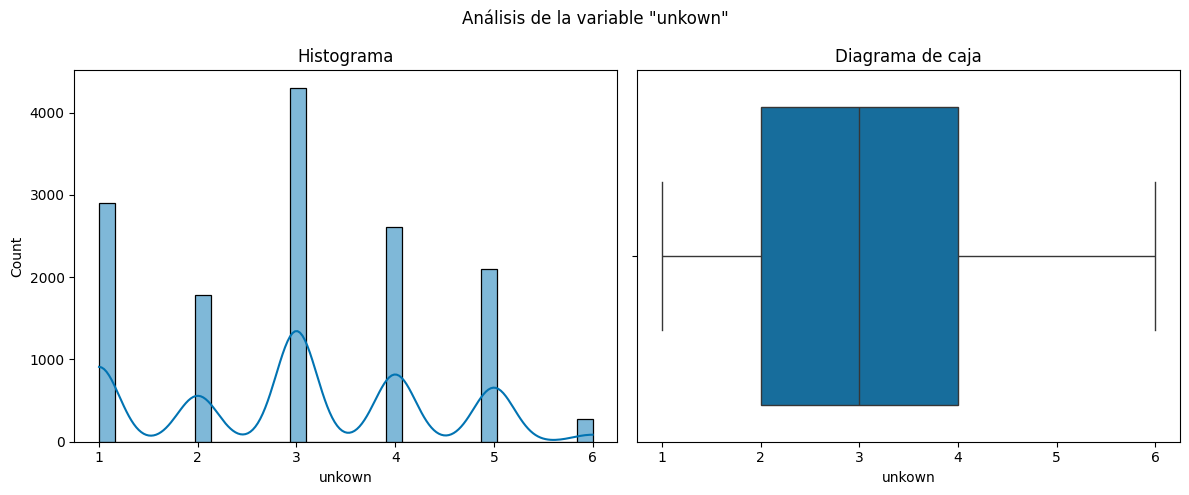

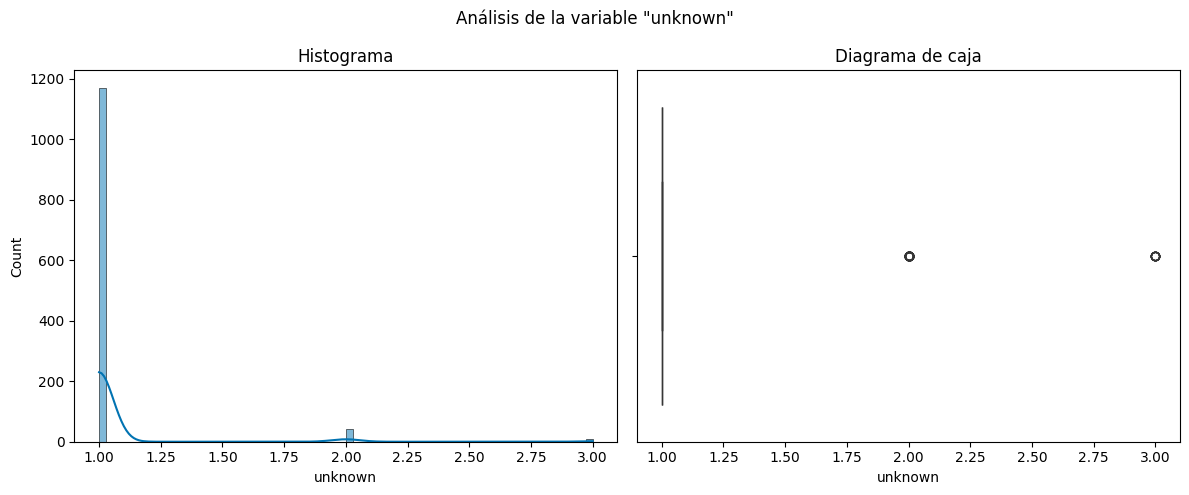

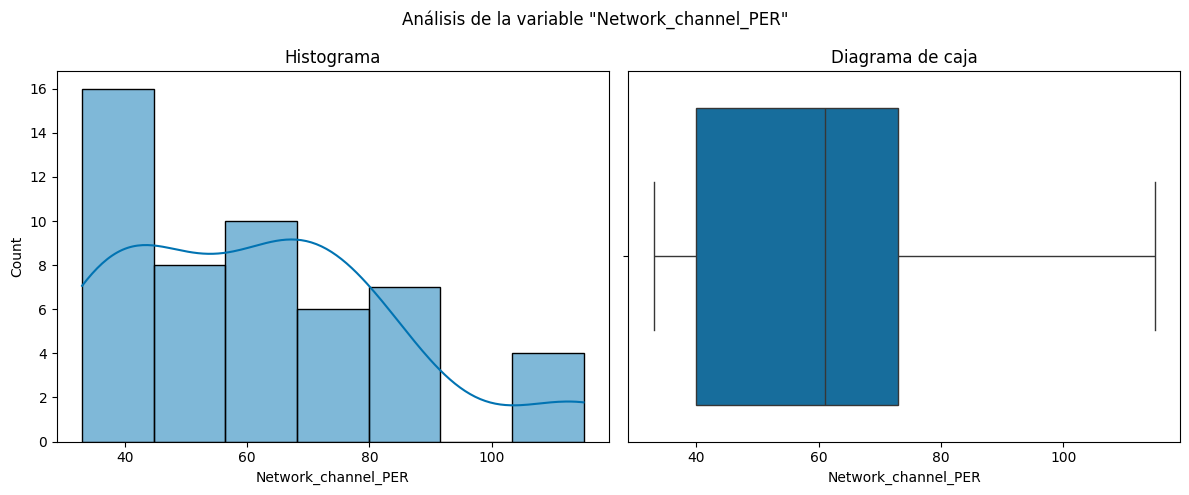

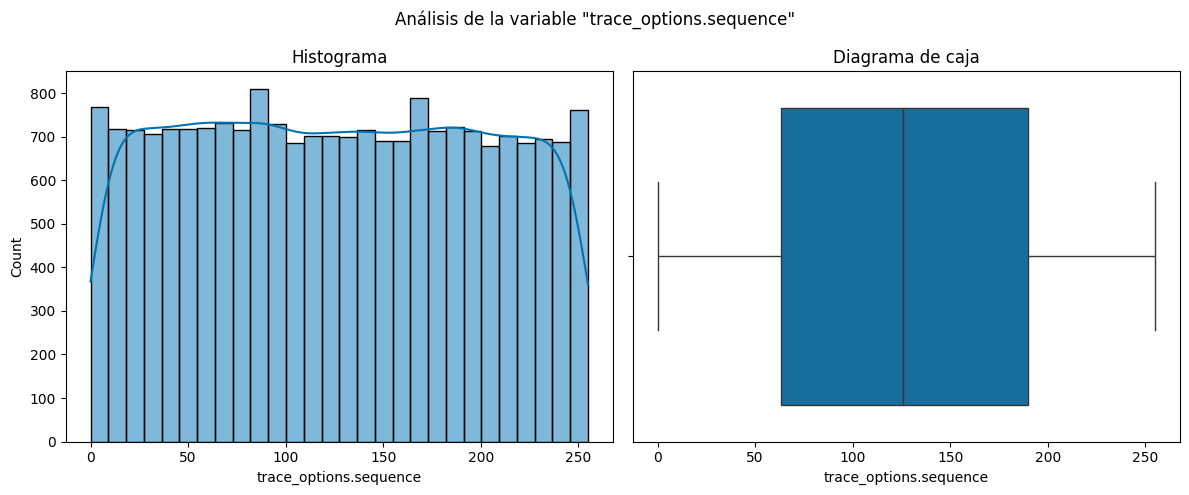

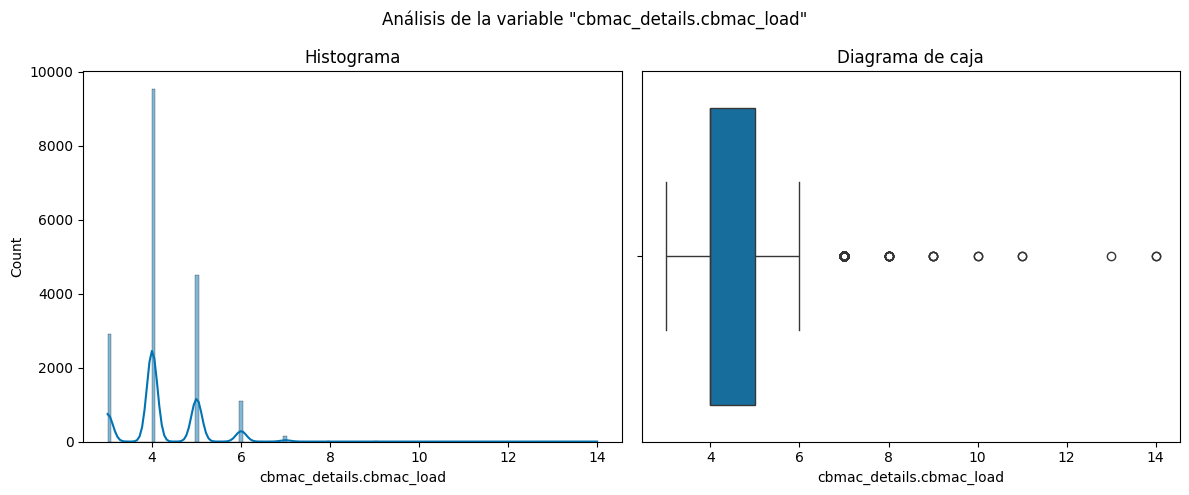

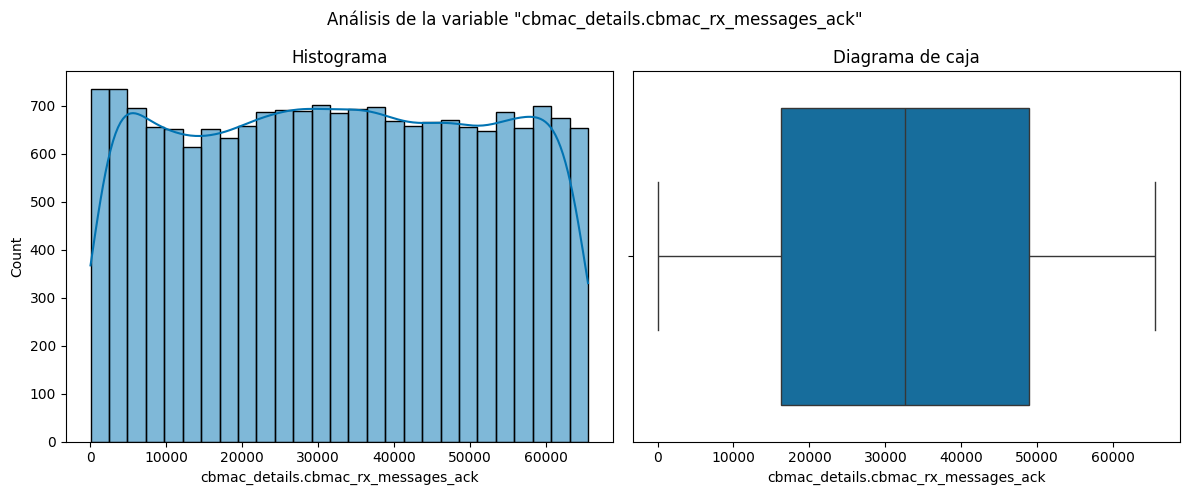

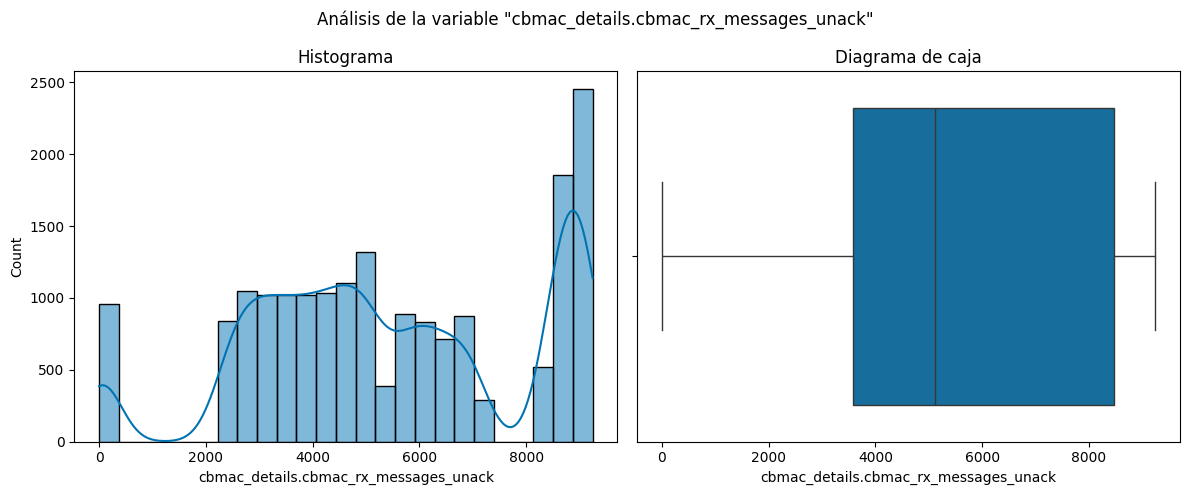

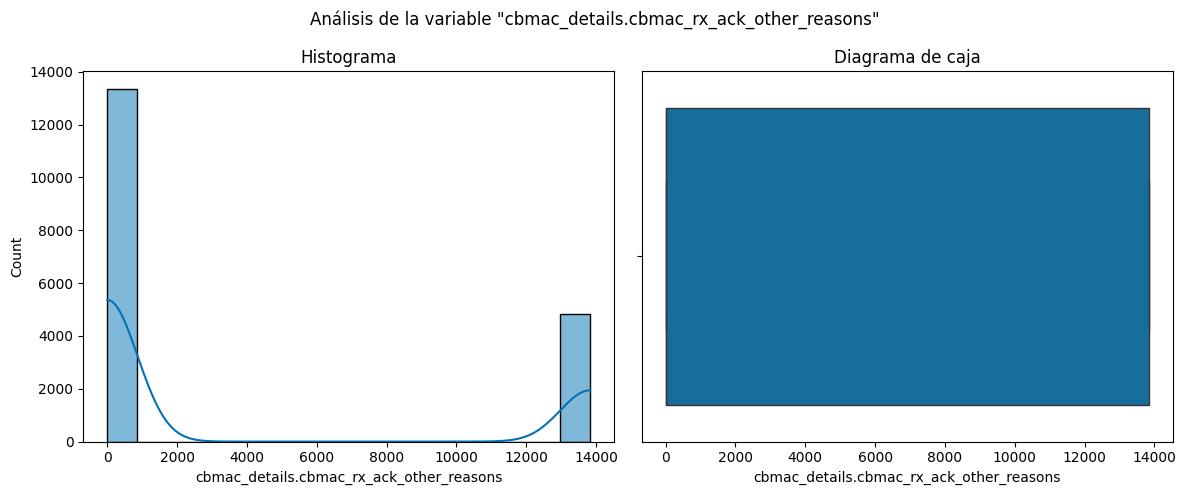

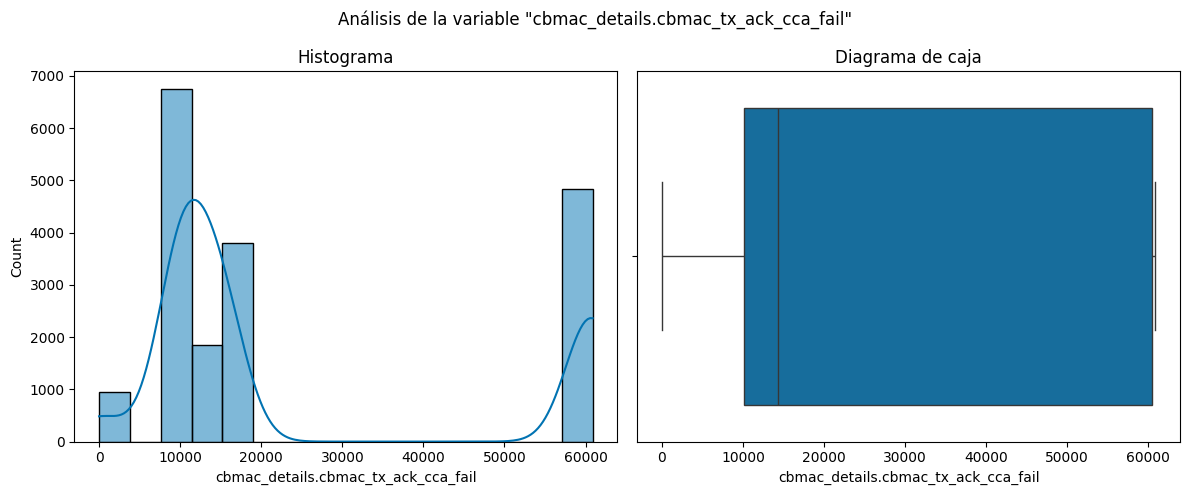

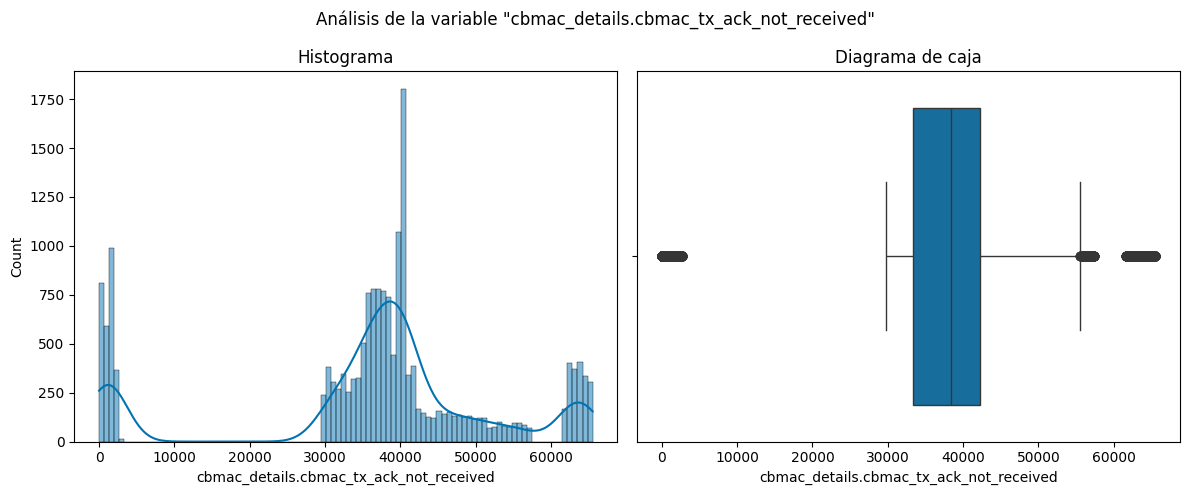

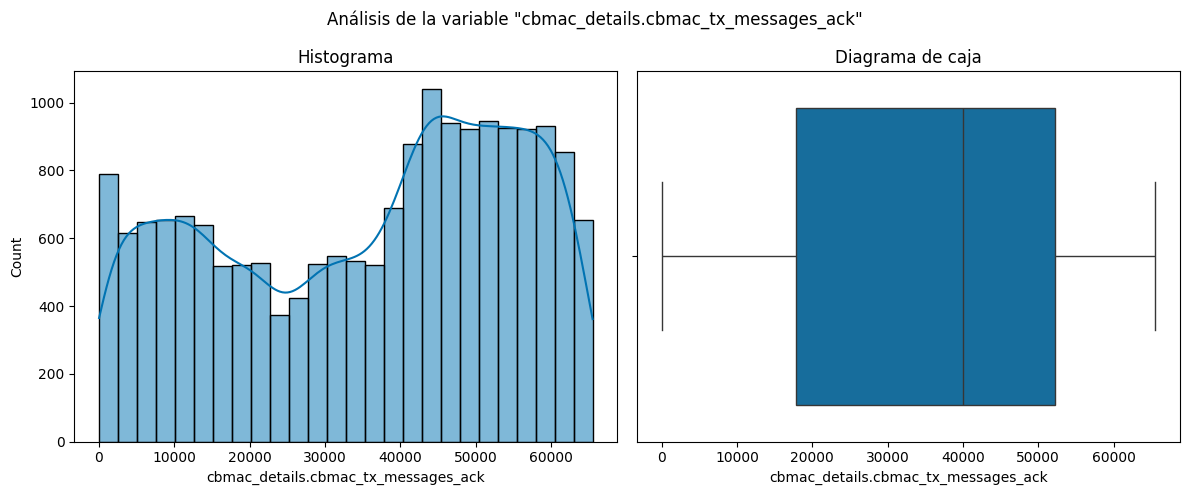

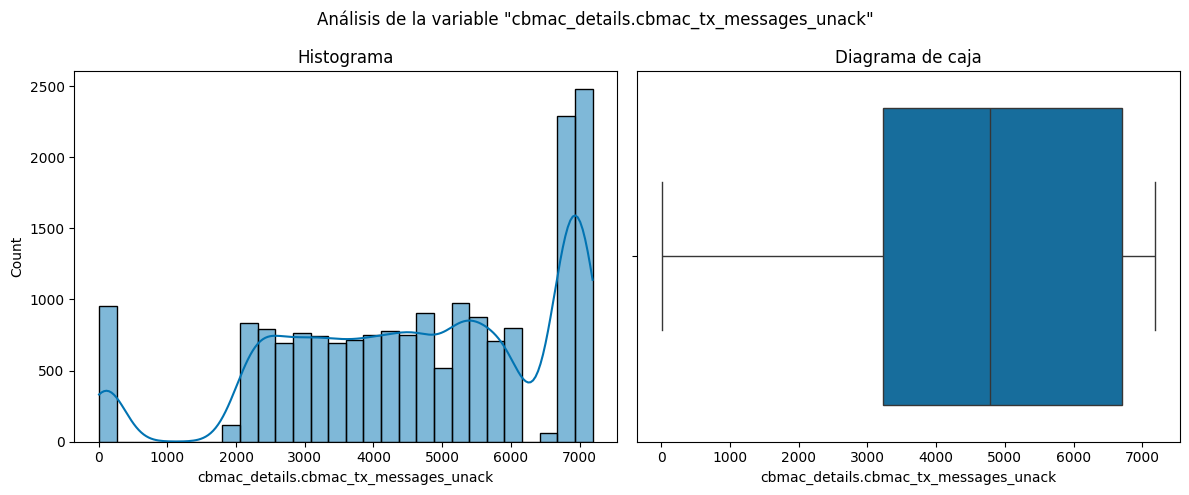

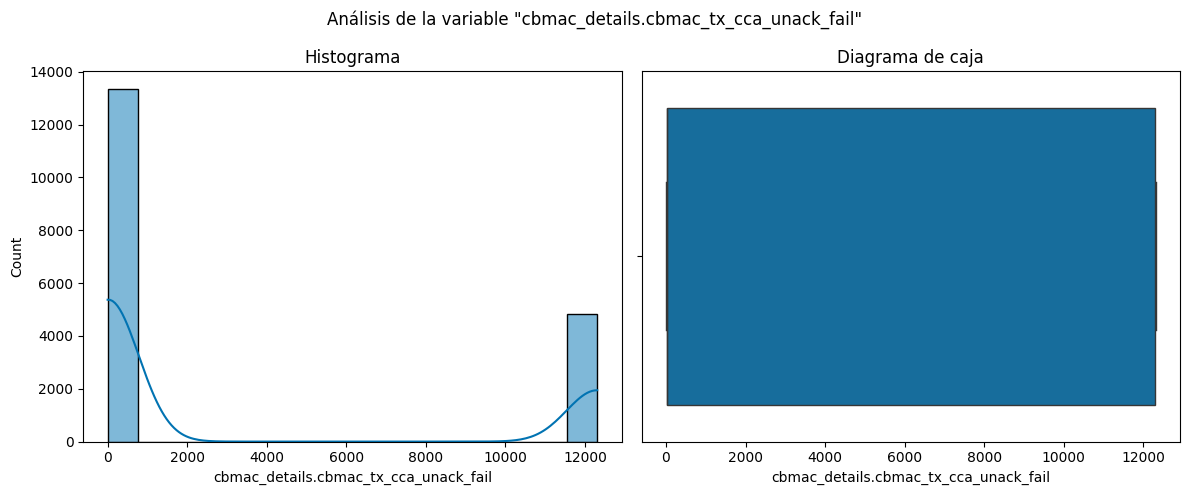

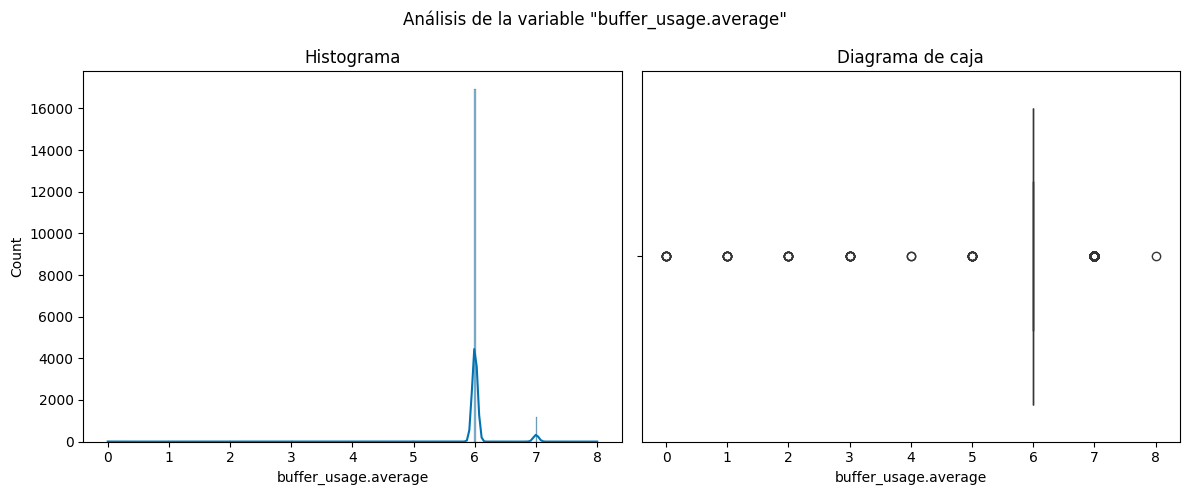

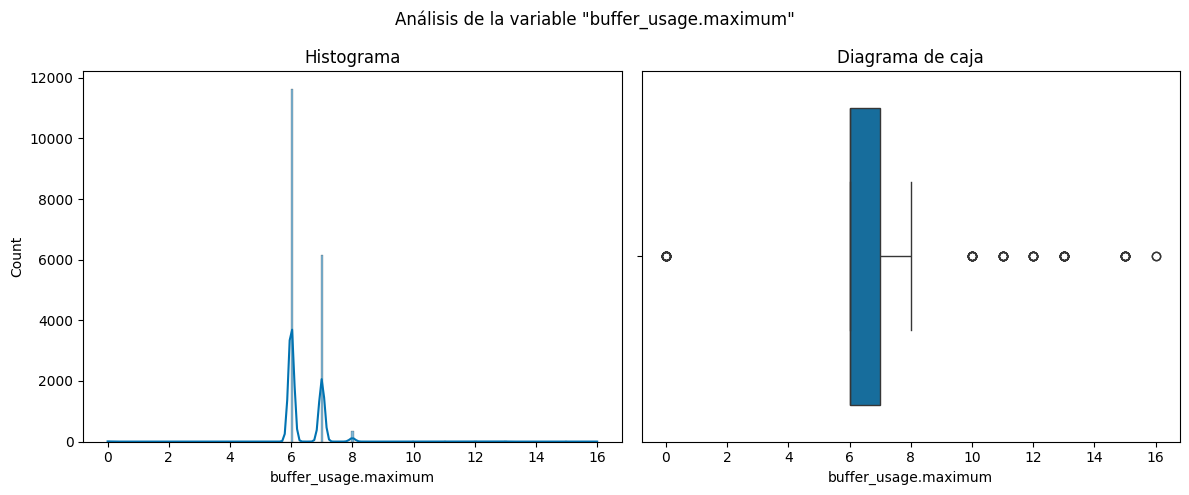

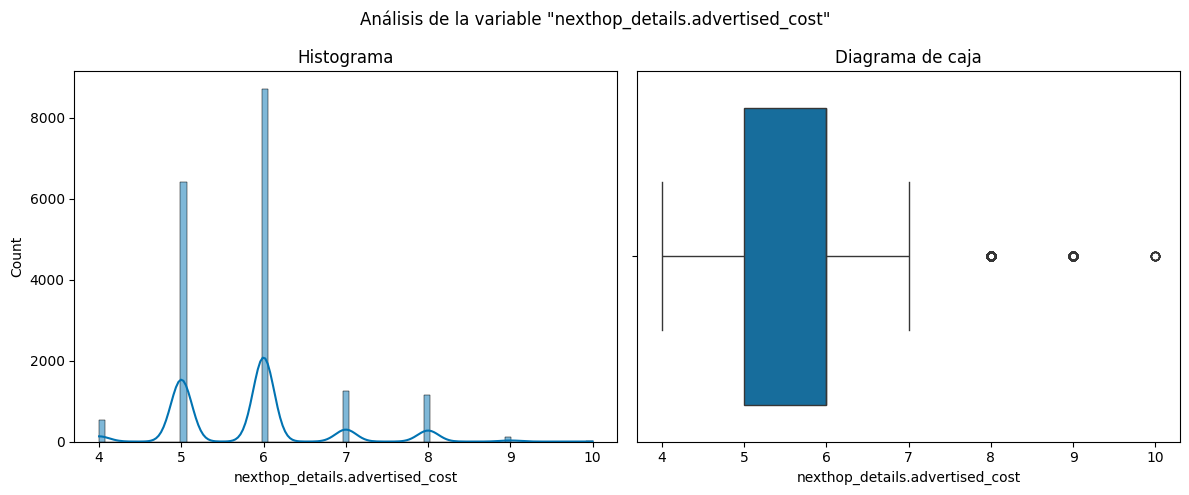

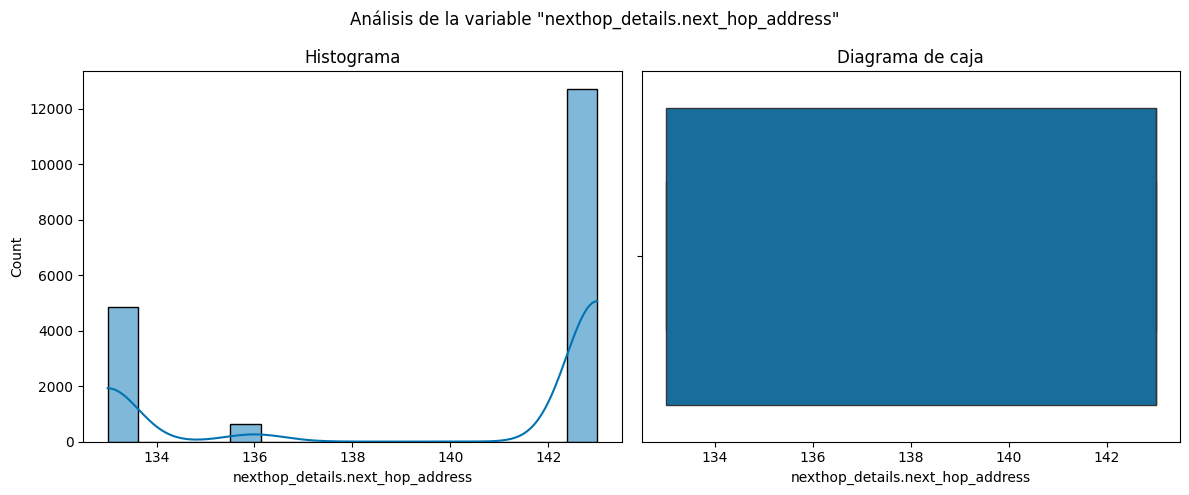

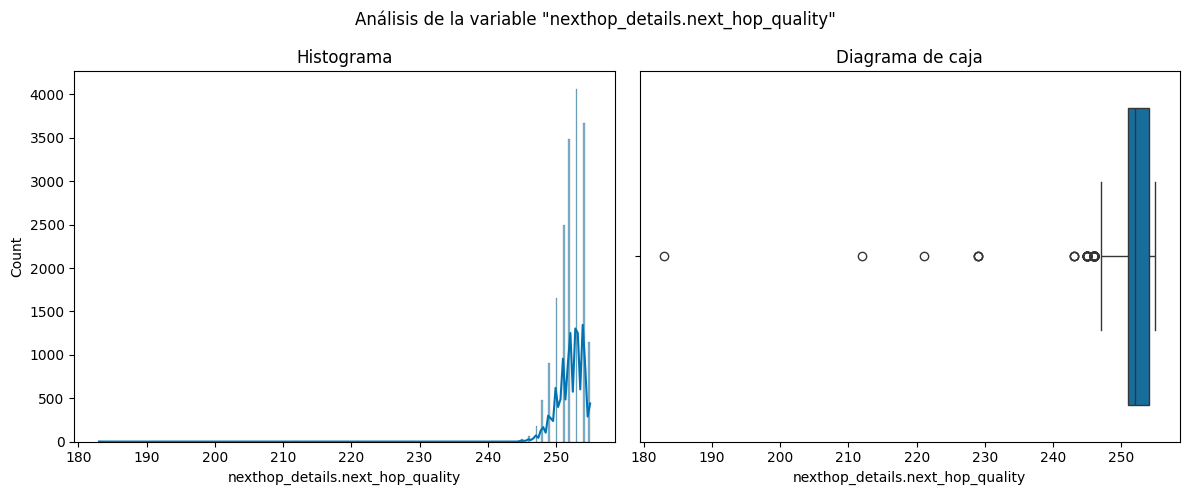

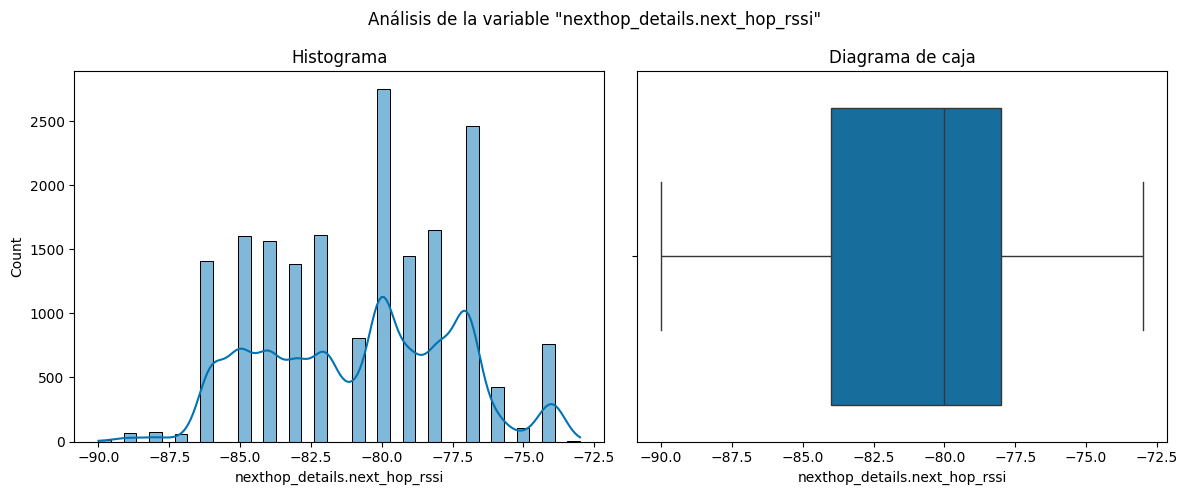

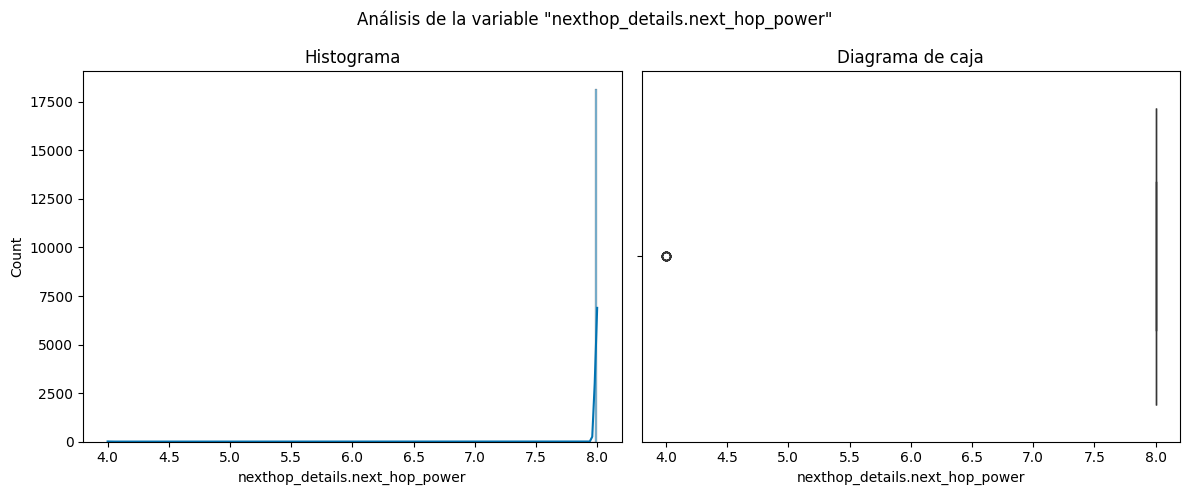

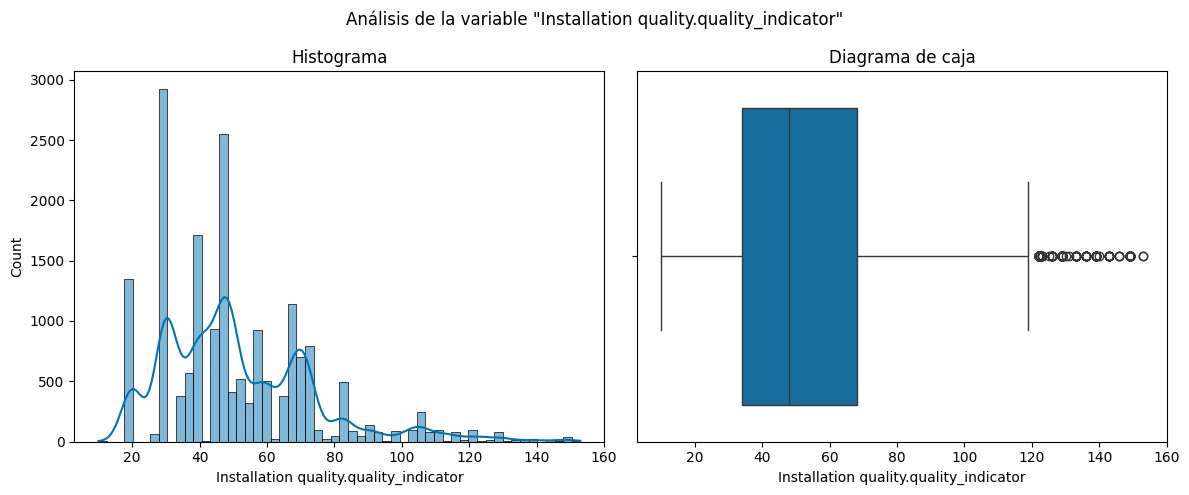

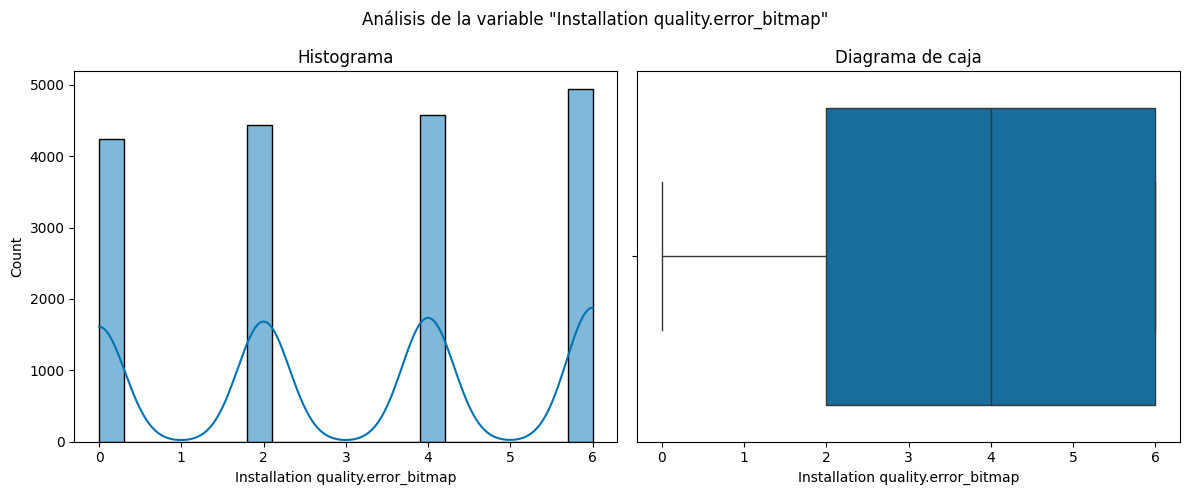

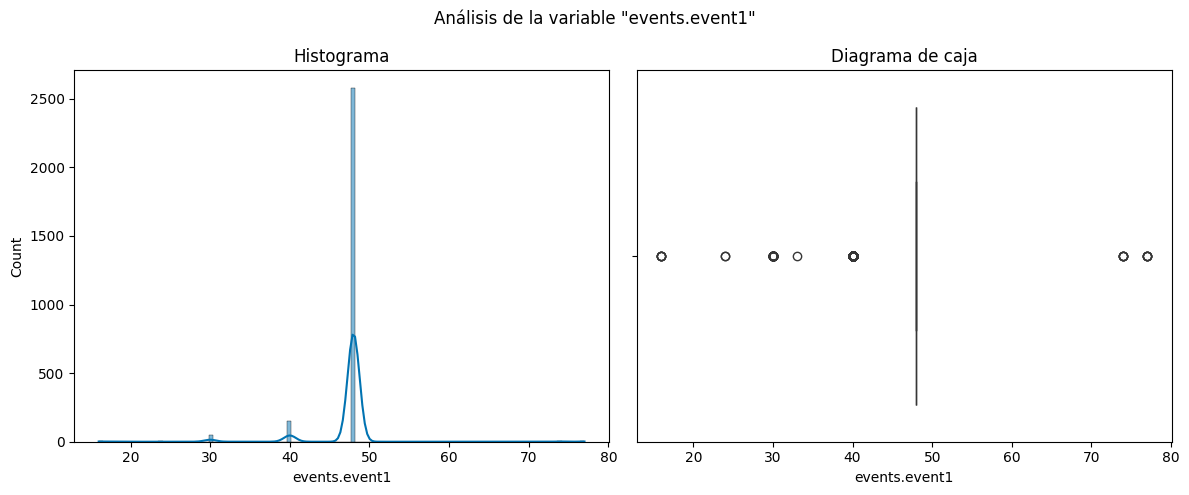

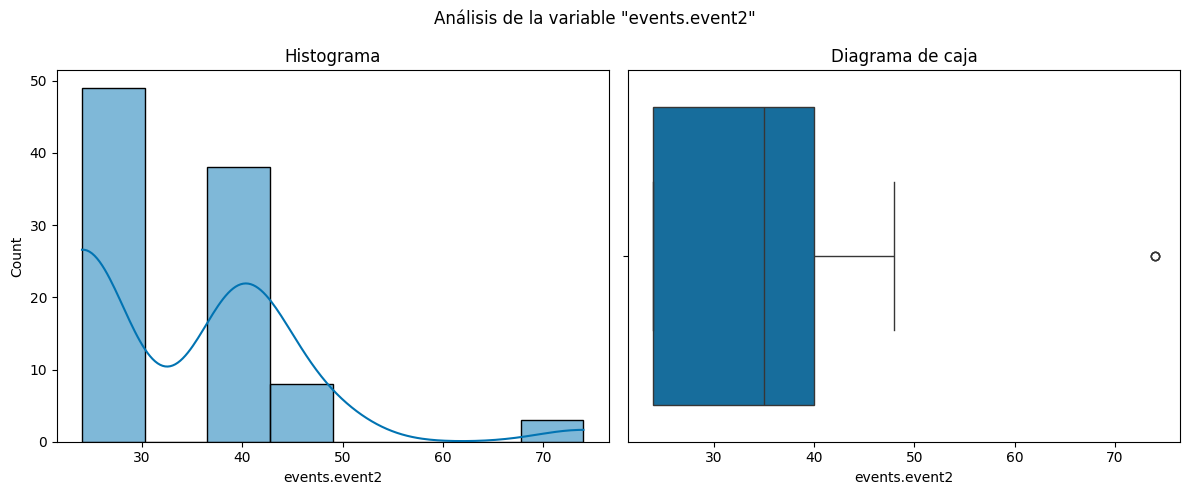

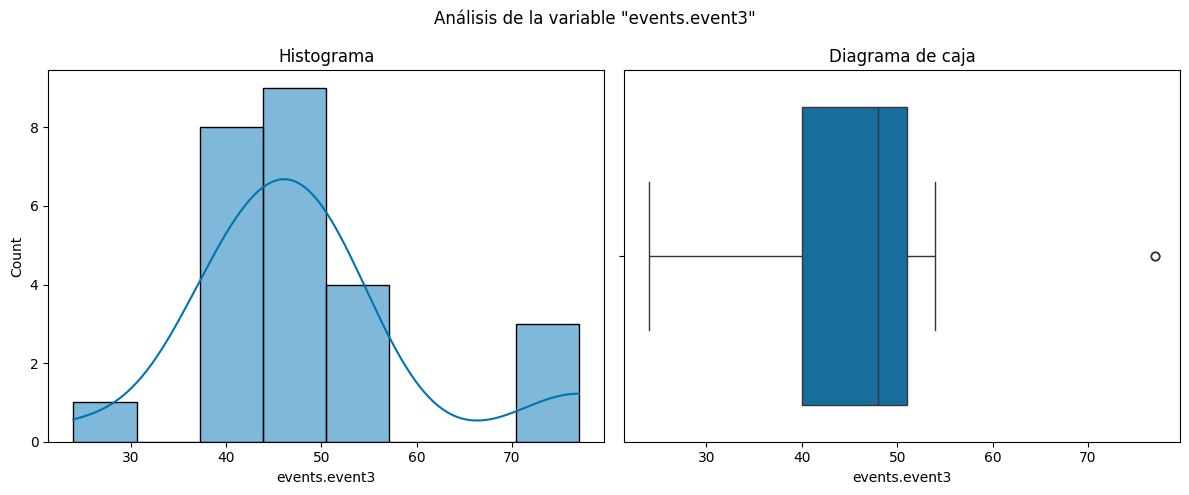

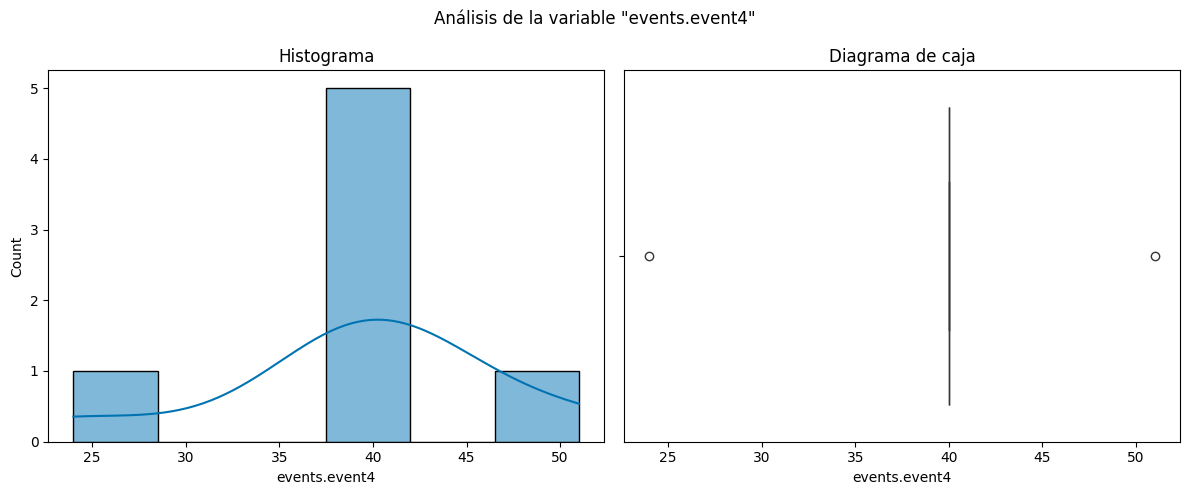

Columnas omitidas y razones:
- src: columna constante
- src_ep: columna constante
- inputState: columna constante
- two_in_one_battery_level: columna constante
- configuration: columna constante
- last_hw_test_result: columna constante
- last_sw_test_result: columna constante
- pictogram: columna constante
- brightness: columna constante
- configured: columna constante
- sensors: columna constante
- device_type: columna constante
- code: columna constante
- error_code: columna constante
- model: columna constante
- battery_type: columna constante
- app_firmware_major: columna constante
- app_firmware_minor: columna constante
- app_firmware_maintenaince: columna constante
- app_firmware_devel: columna constante
- app_stack_major: columna constante
- app_stack_minor: columna constante
- app_stack_maintenaince: columna constante
- app_stack_devel: columna constante
- app_TFT_major: columna constante
- app_TFT_minor: columna constante
- app_TFT_maintenaince: columna constante
- functionali

In [ ]:
X_src140 = X_train[X_train["src"] == 140]
skipped = {}
for column in numerical_features:
    try:
        # Extraer la columna
        x = X_src140[column]

        # Comprobar que queda más de 1 valor
        if len(x) < 2:
            skipped[column] = "menos de 2 valores"
            continue

        # Evitar columnas constantes (boxplot rompe si no varían)
        if x.nunique() < 2:
            skipped[column] = "columna constante"
            continue

        # Graficar
        plt.figure(figsize=(12,5))

        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(x, kde=True)
        plt.title("Histograma")

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=x)
        plt.title("Diagrama de caja")

        plt.suptitle(f'Análisis de la variable \"{column}\"')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error en la columna '{column}': {e}")

print("Columnas omitidas y razones:")
for col, reason in skipped.items():
    print(f"- {col}: {reason}")

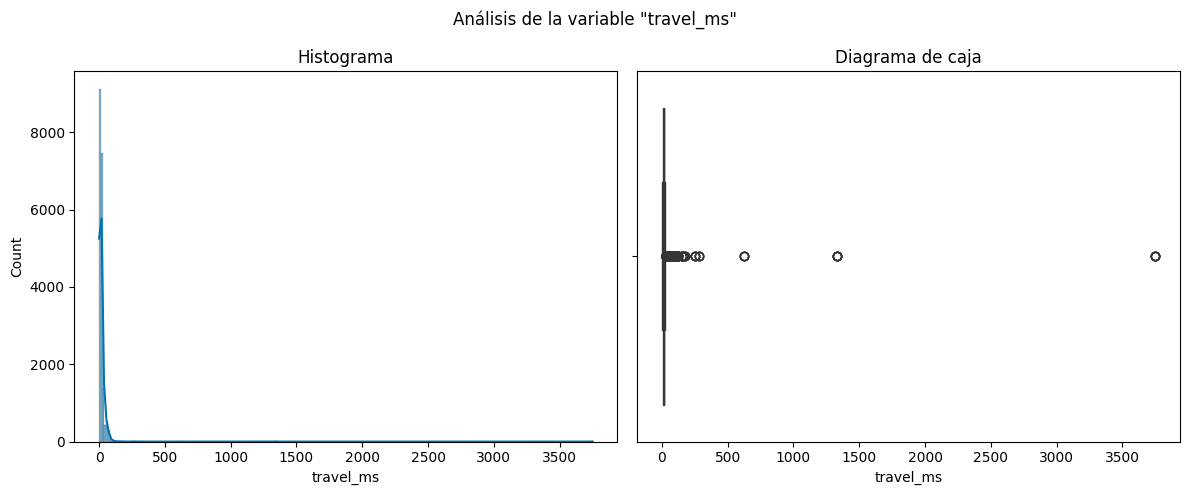

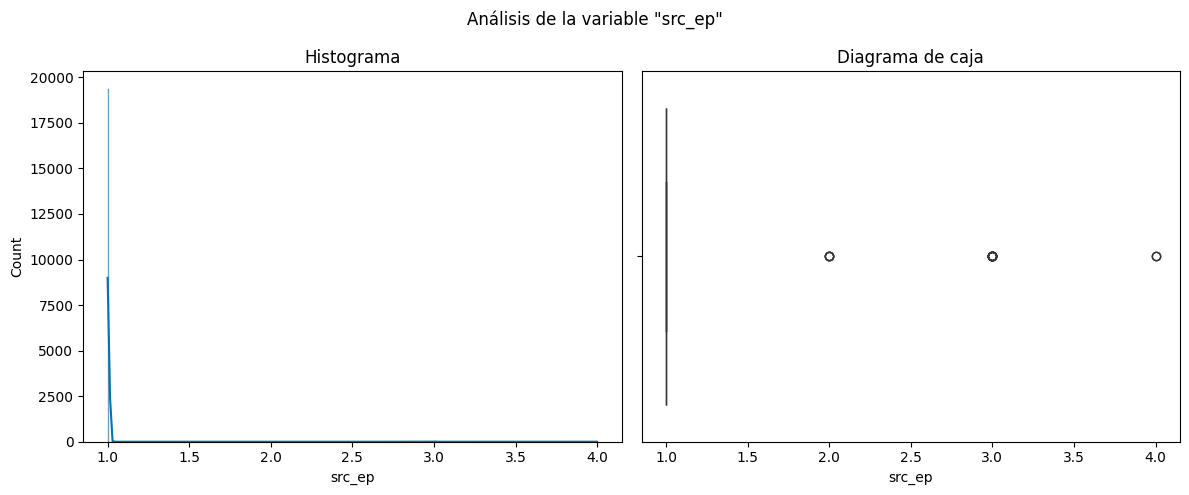

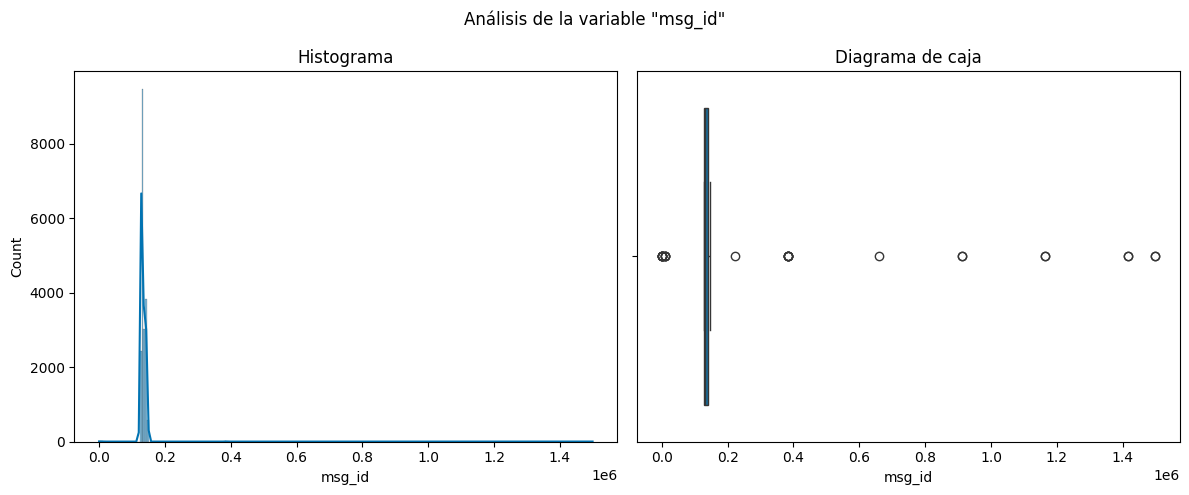

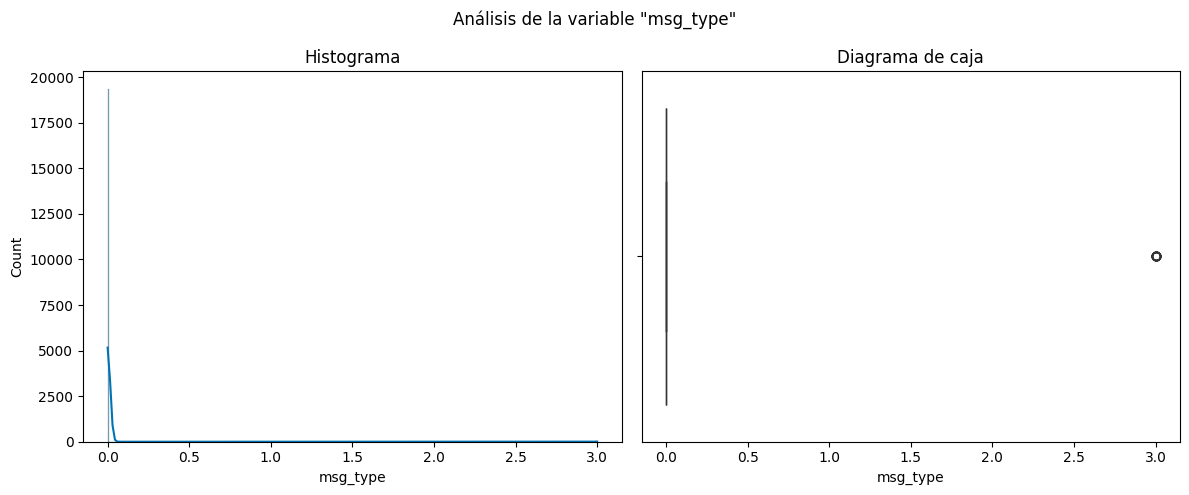

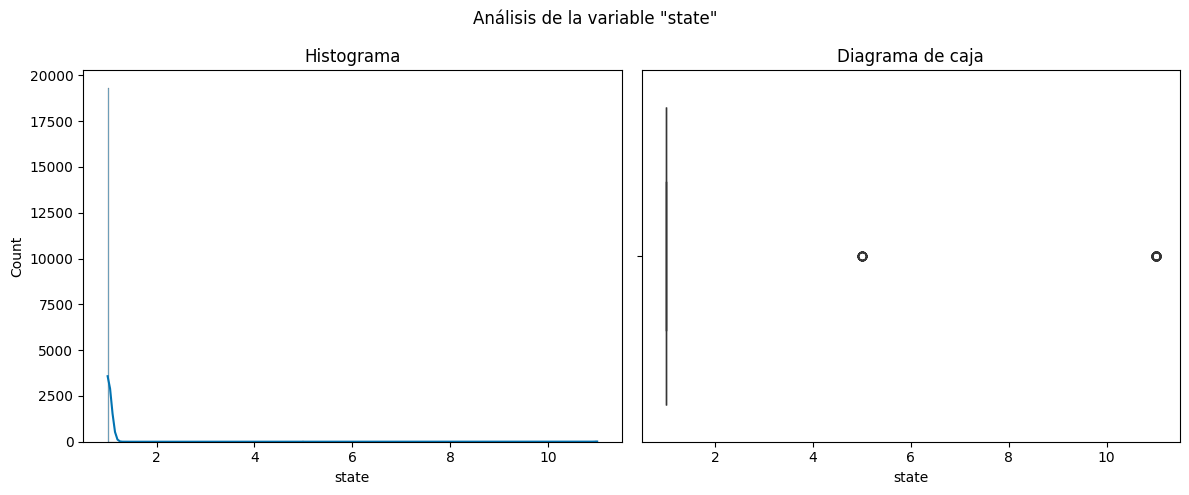

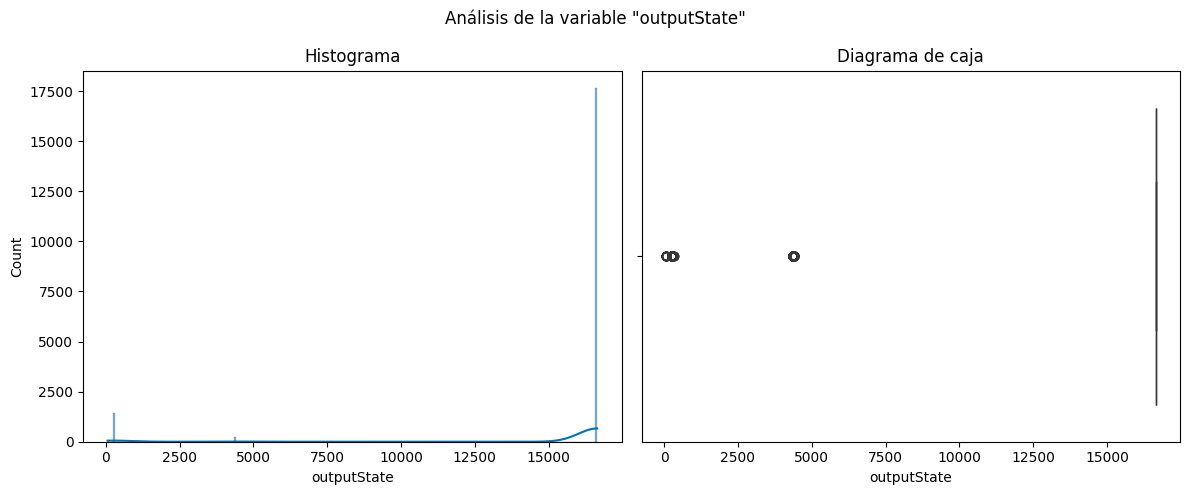

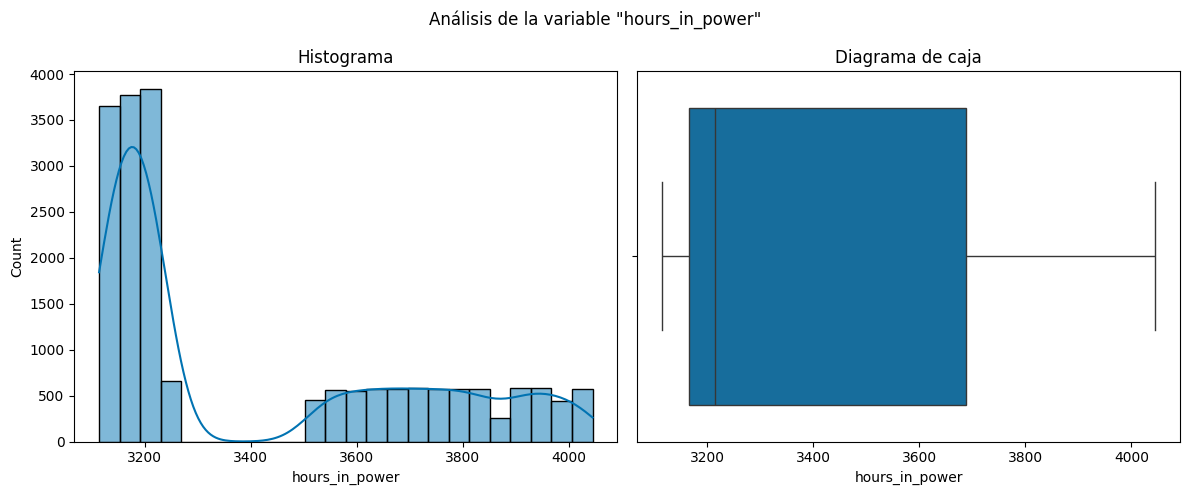

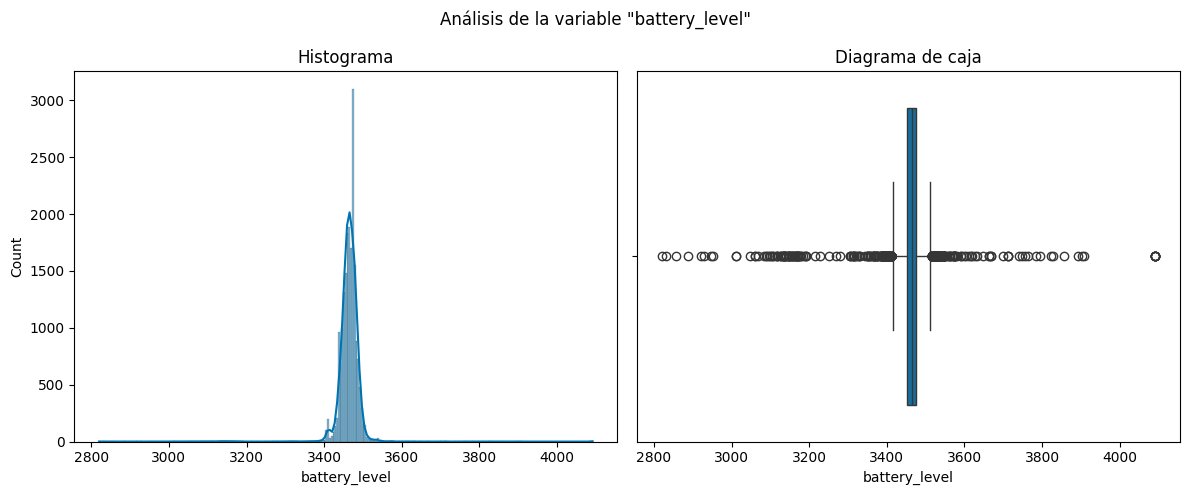

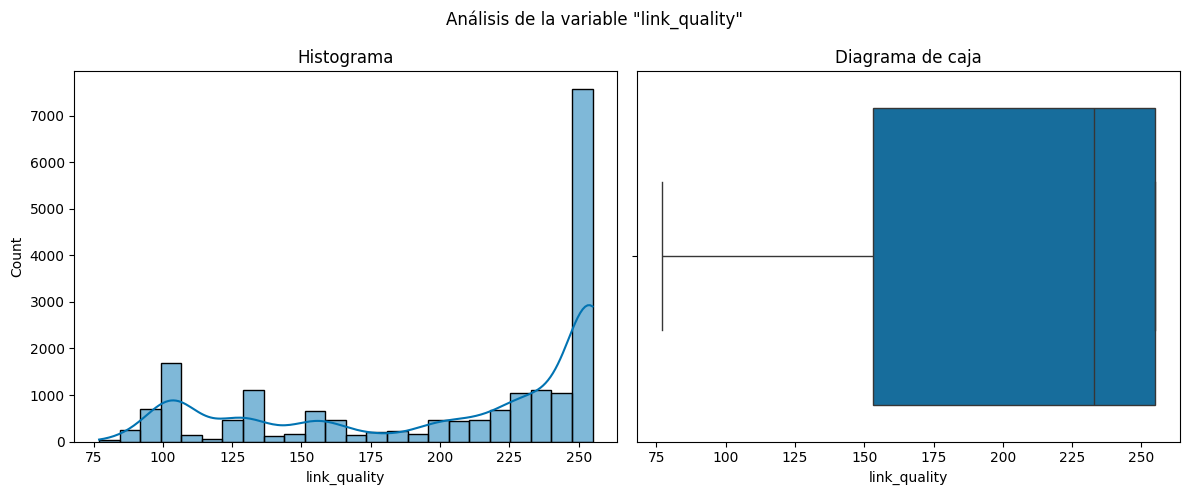

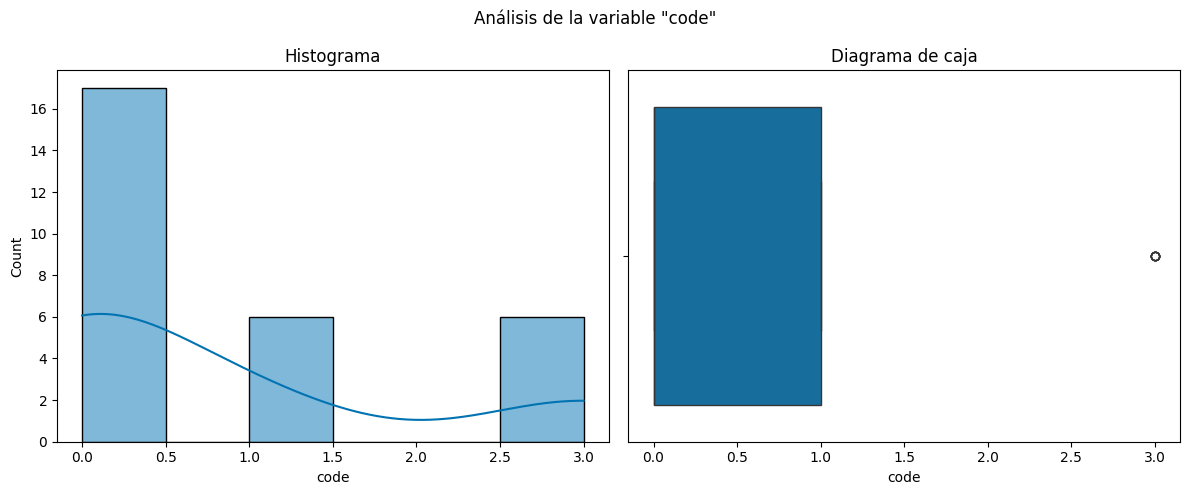

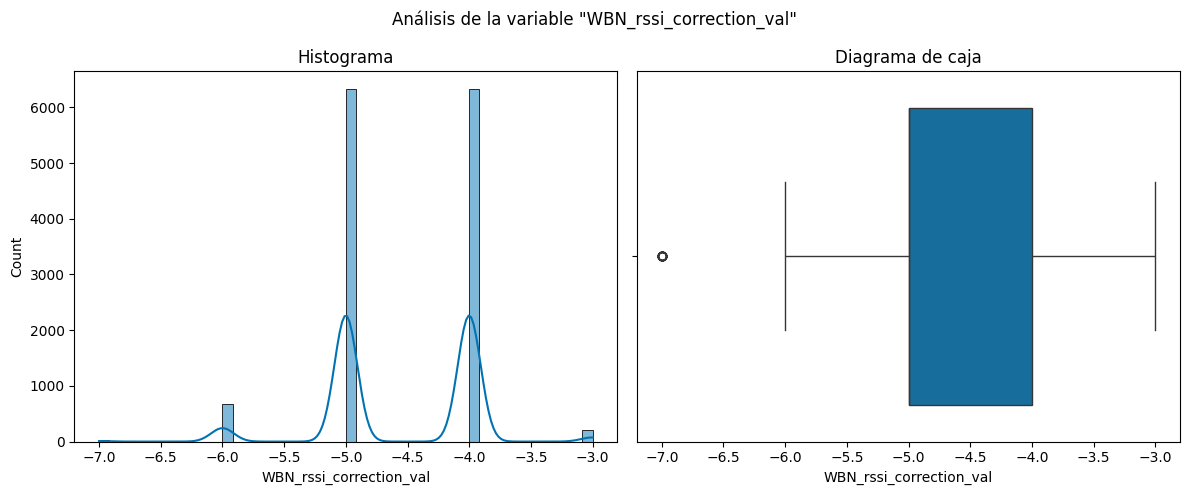

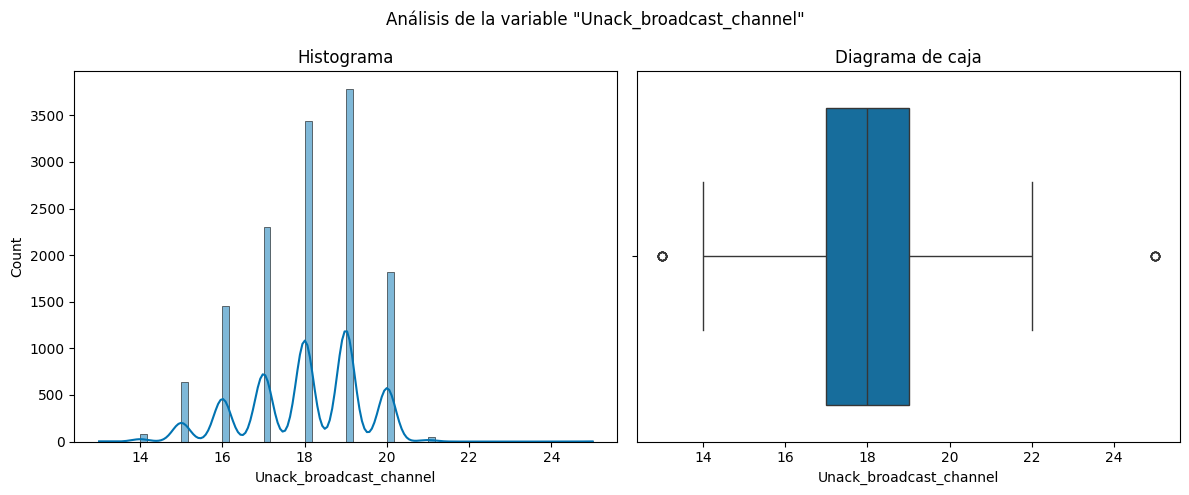

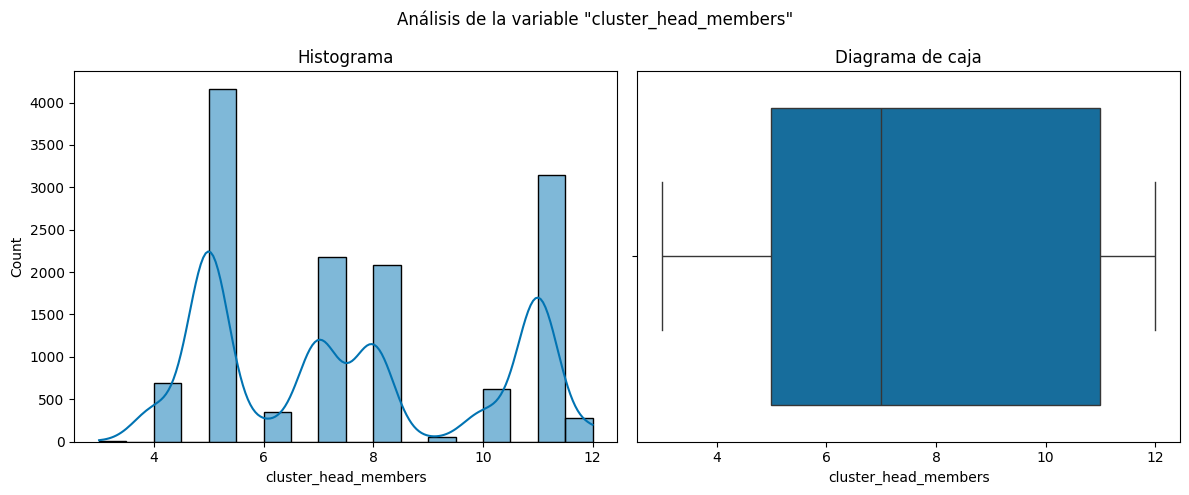

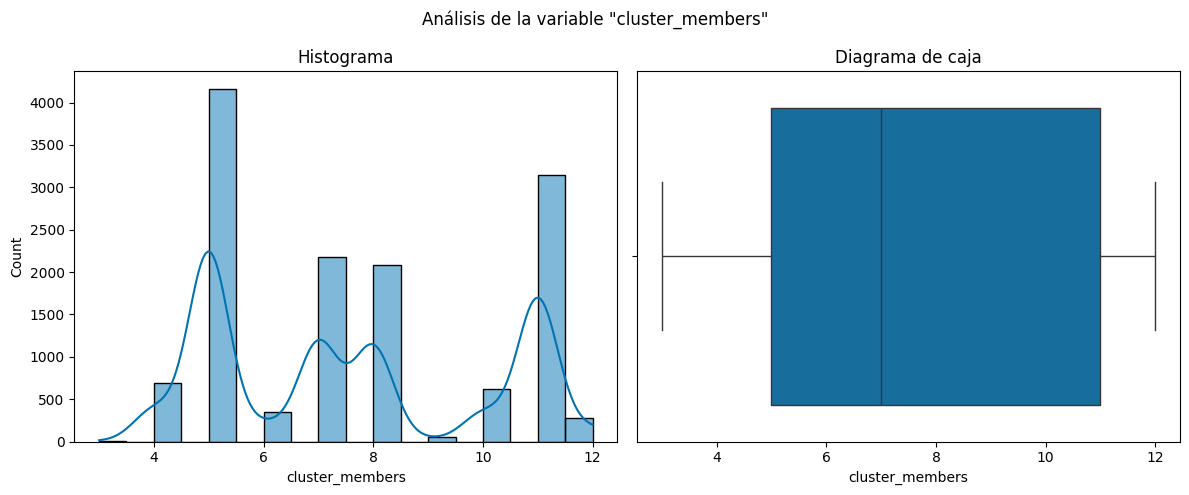

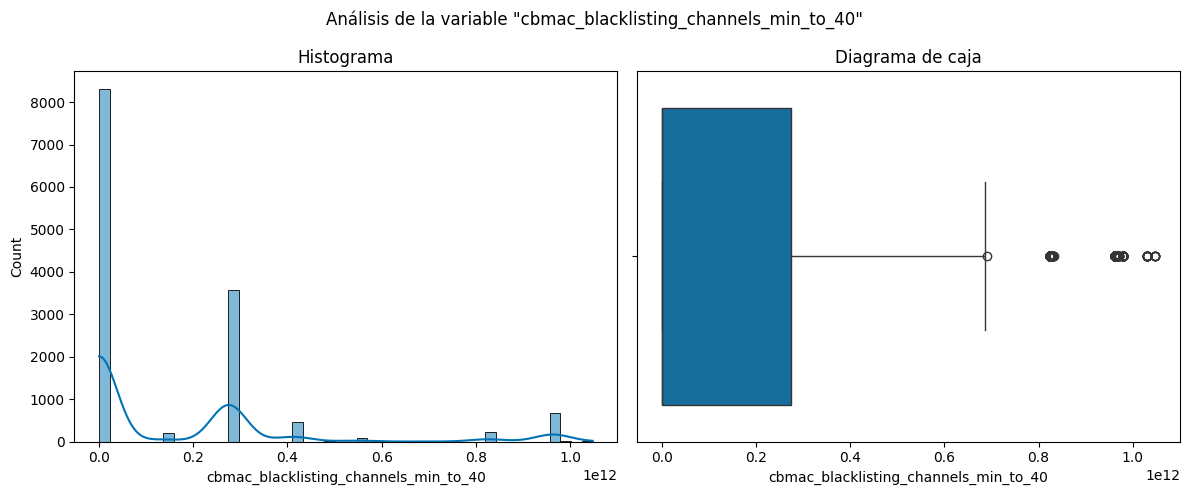

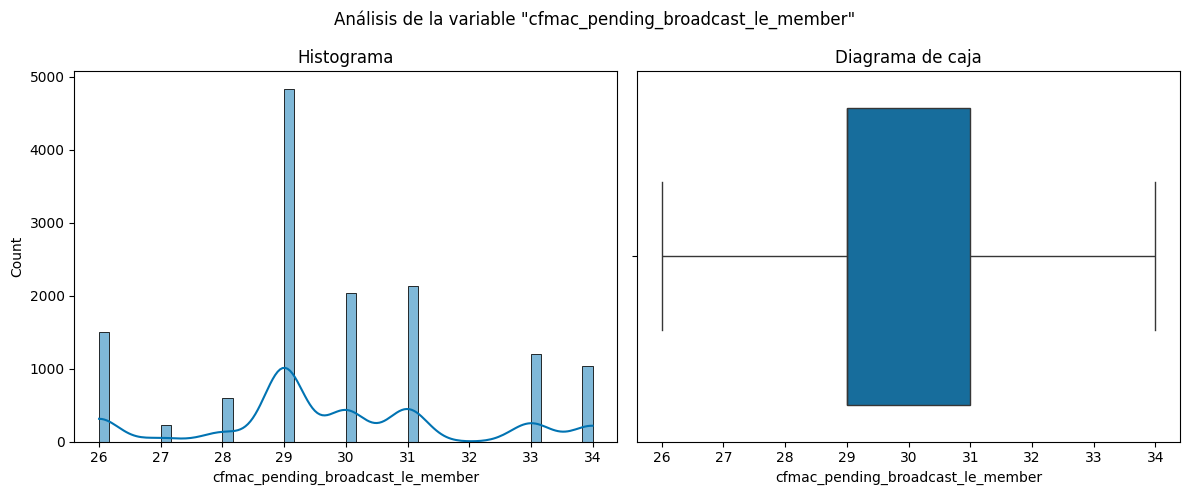

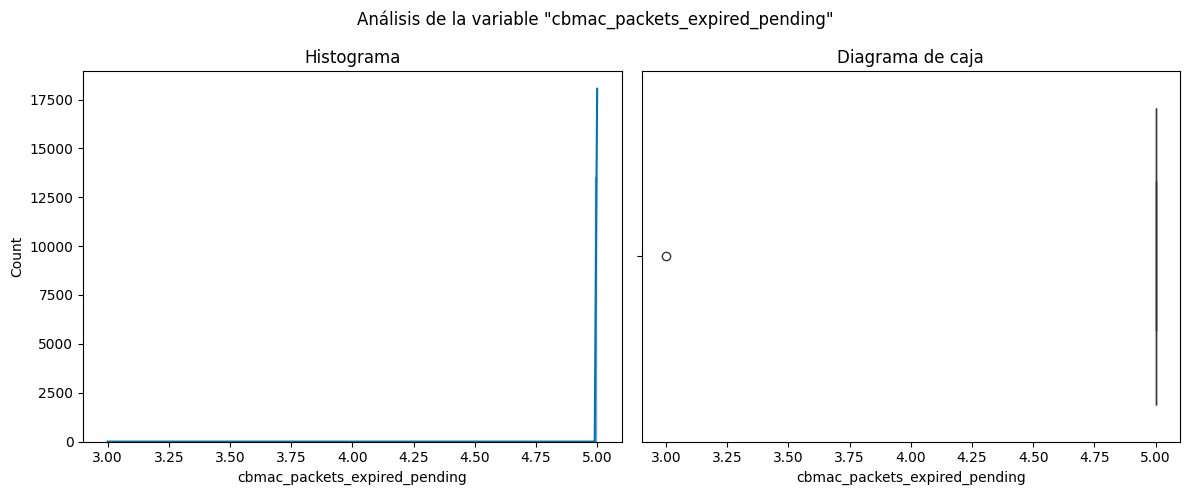

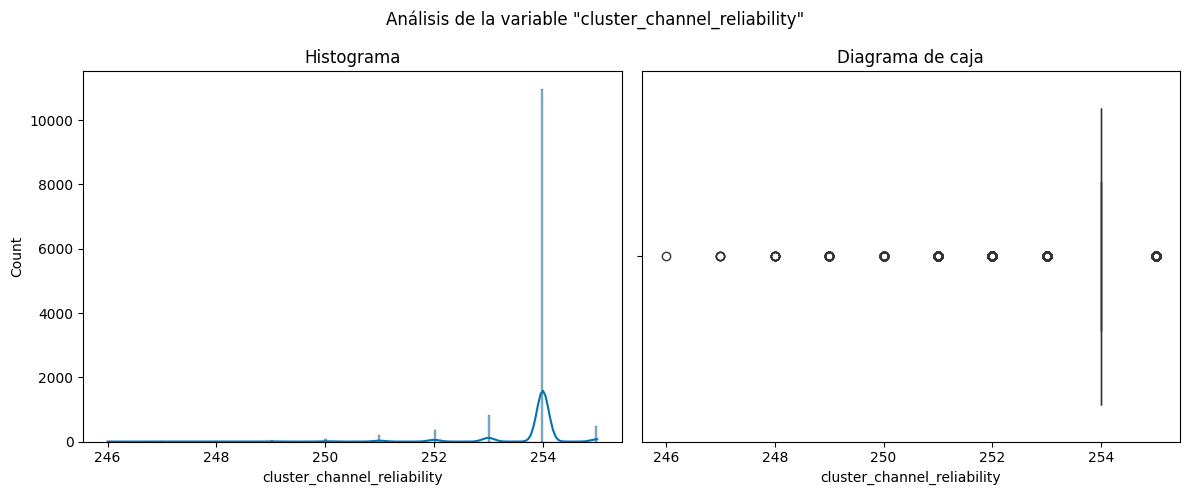

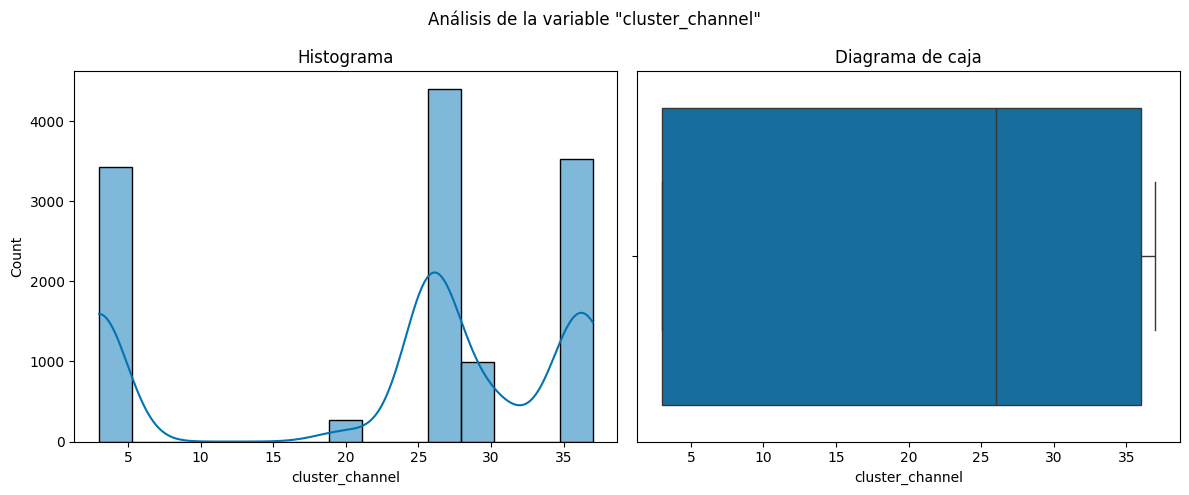

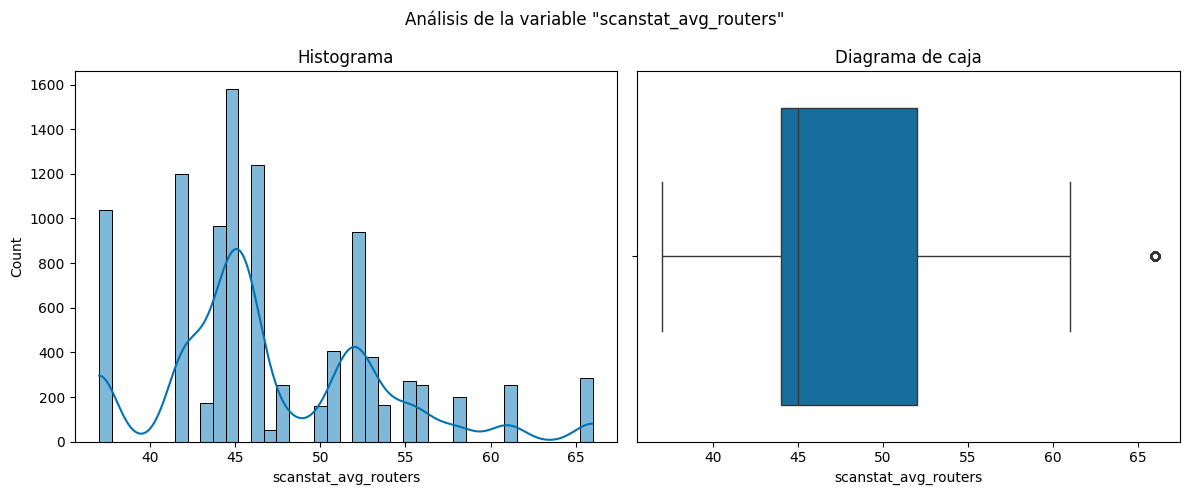

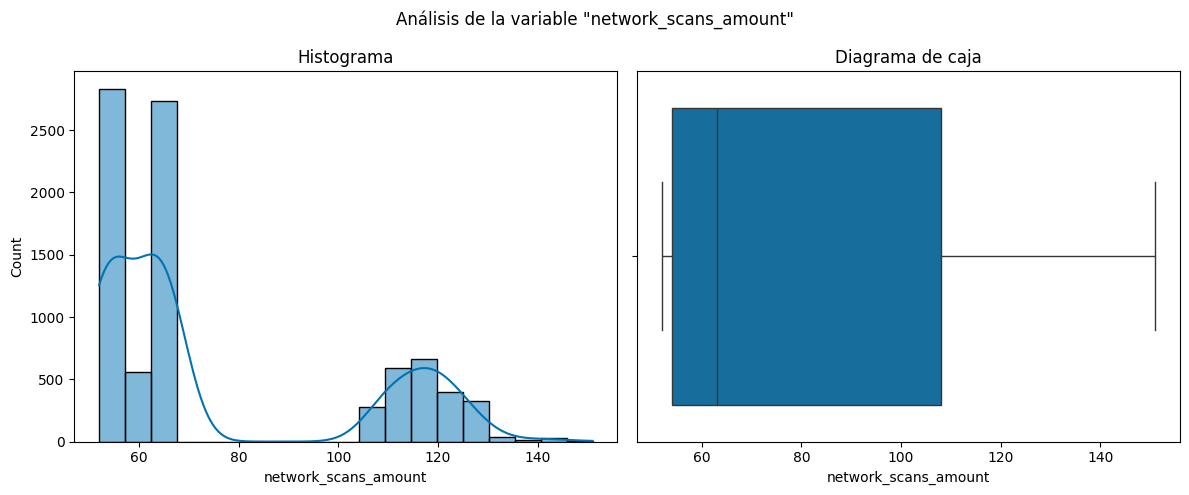

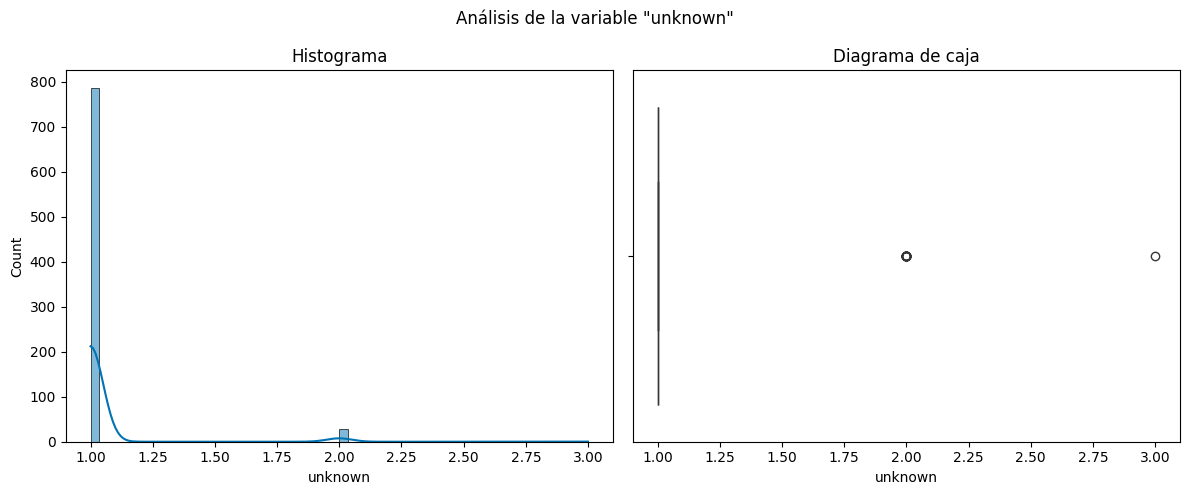

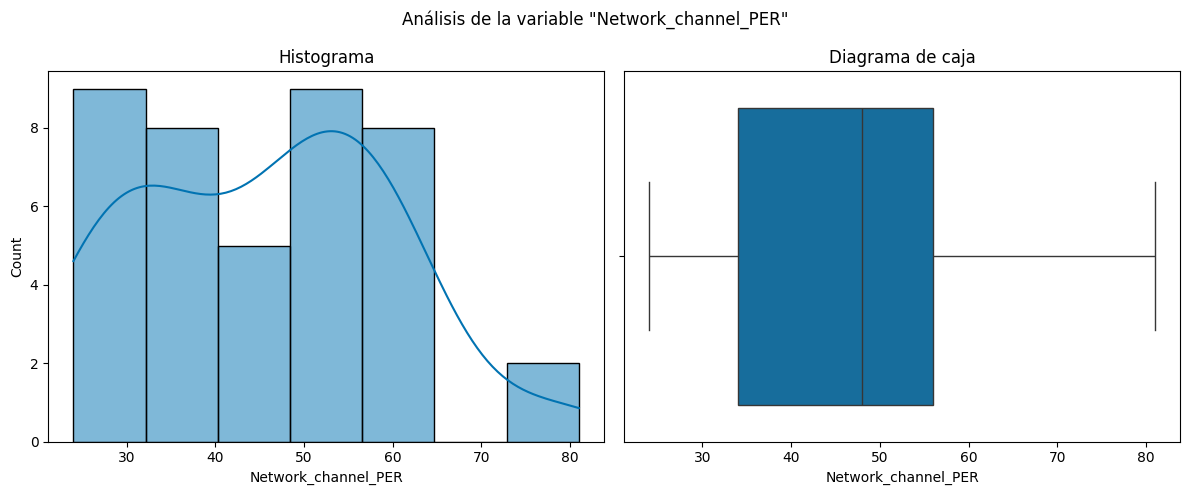

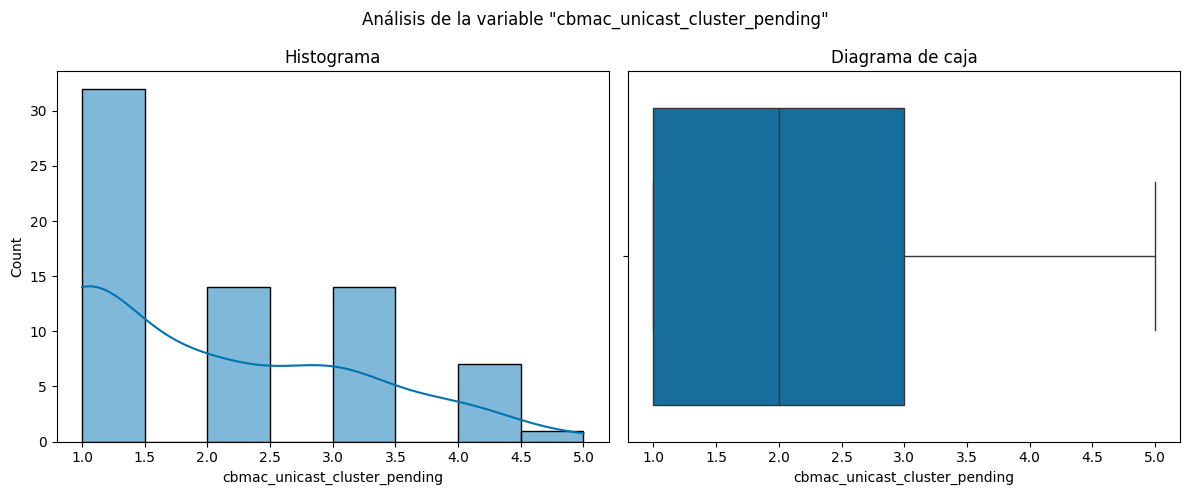

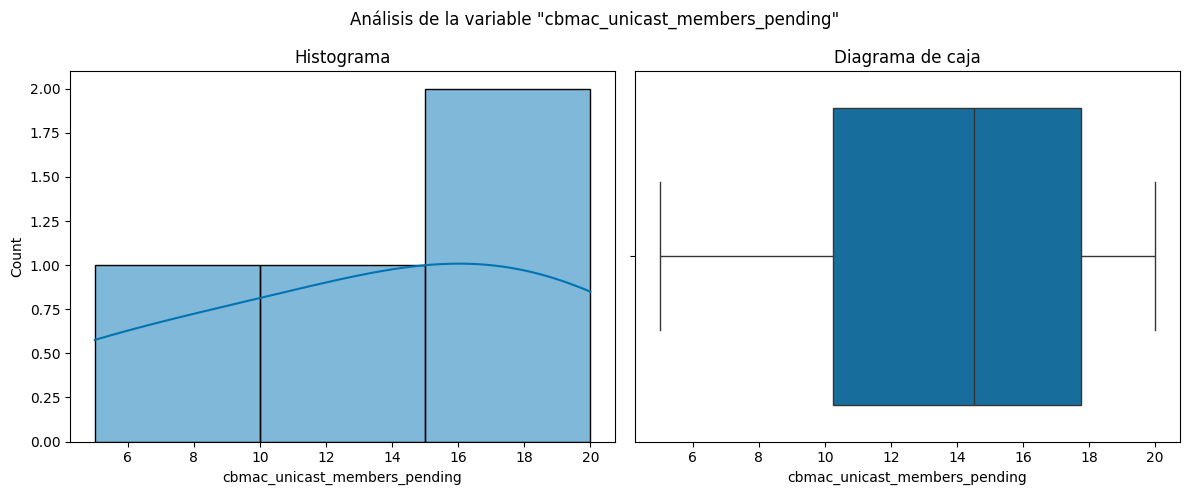

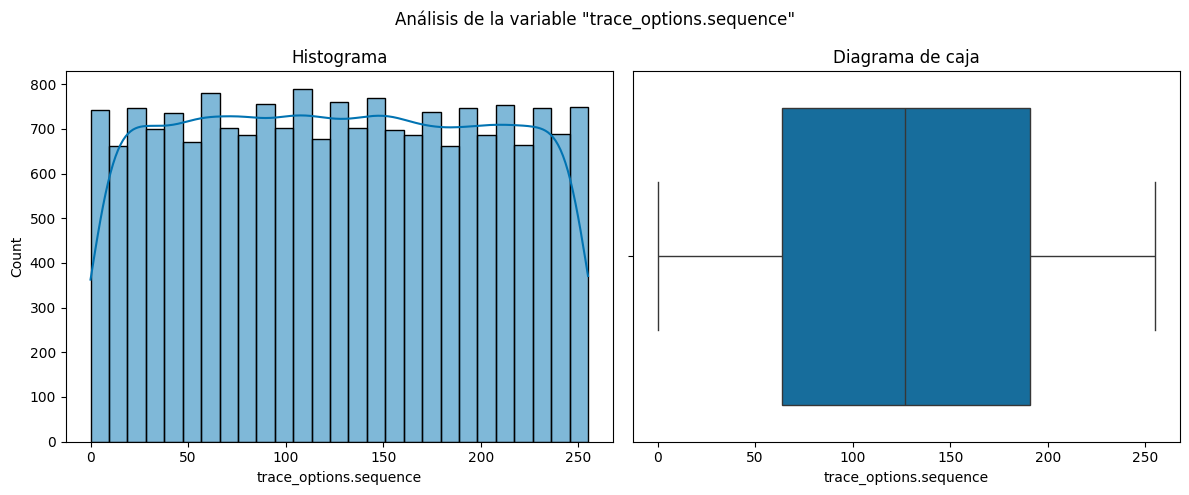

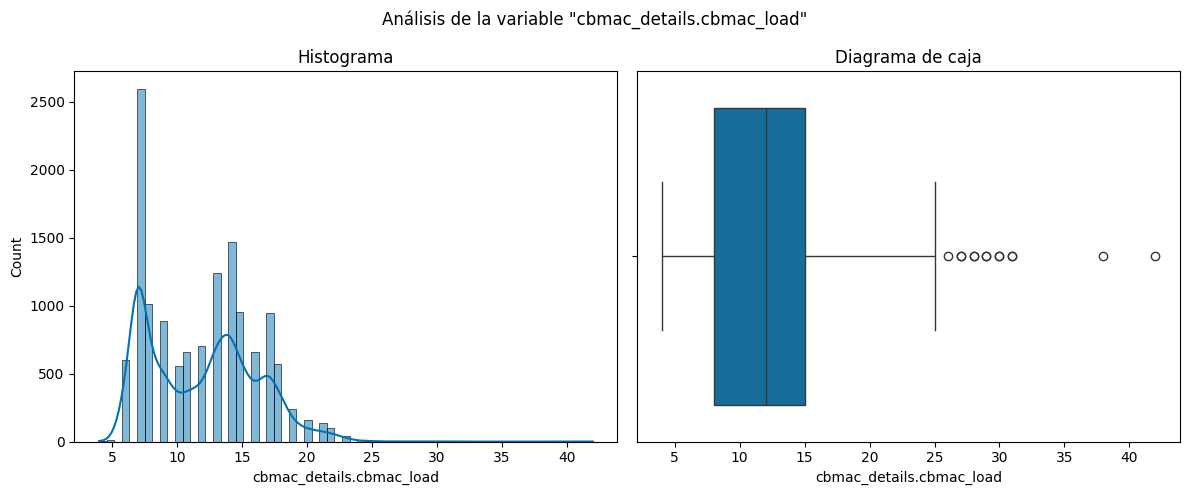

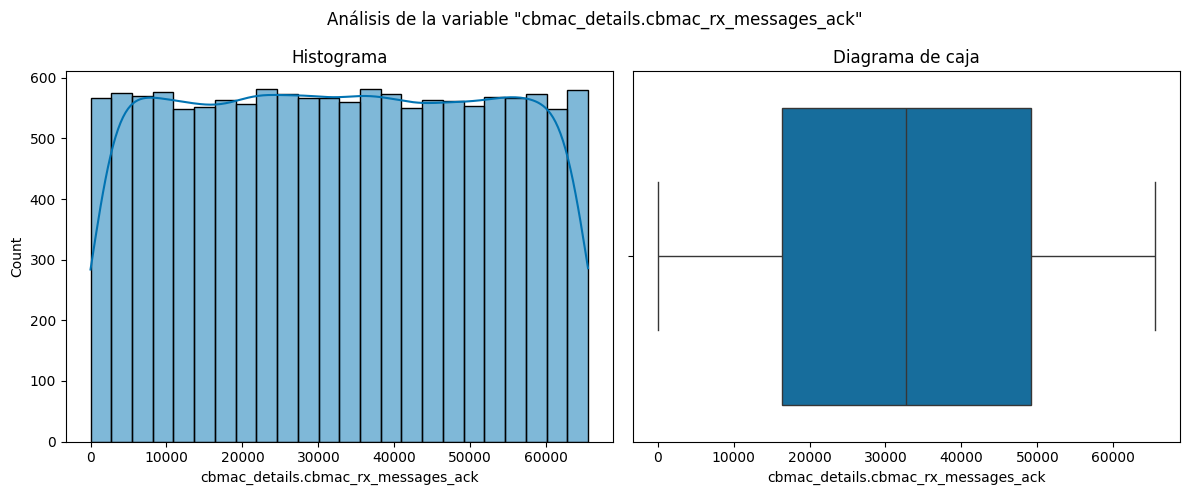

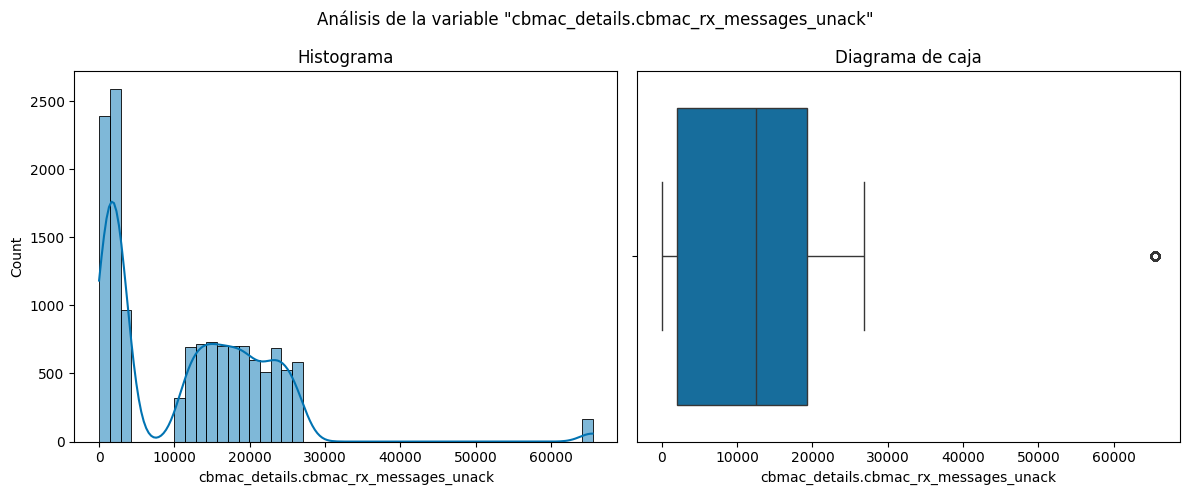

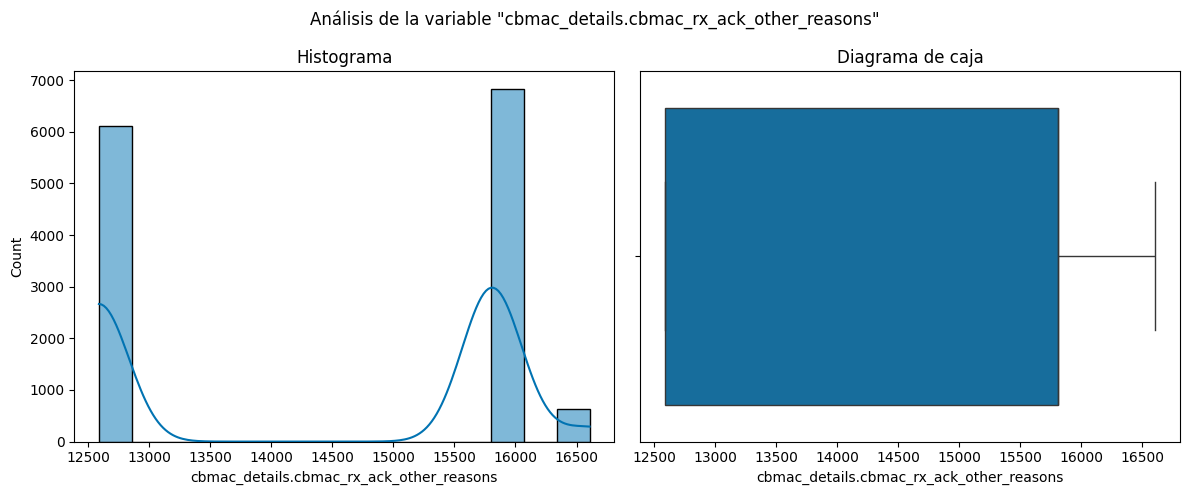

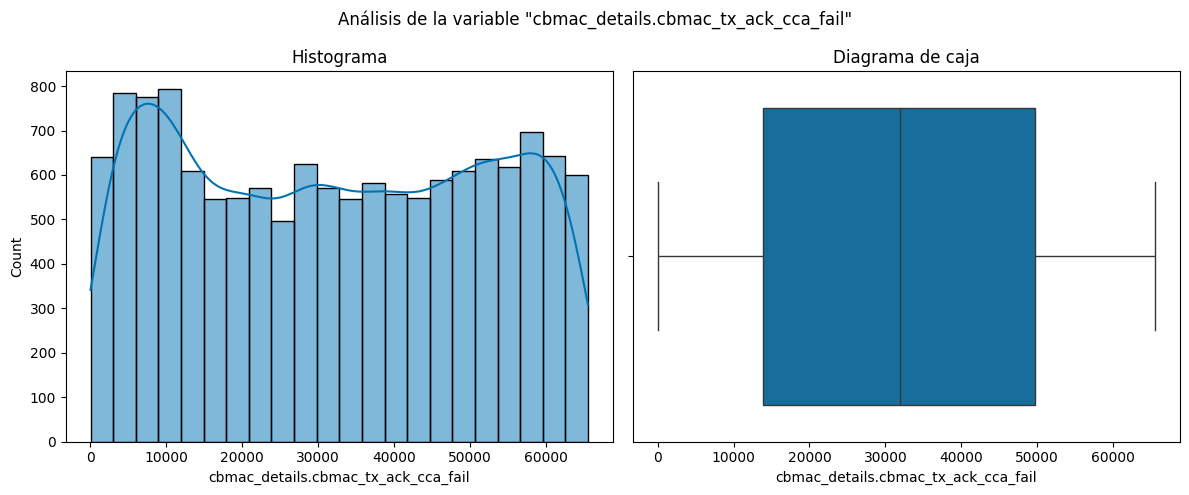

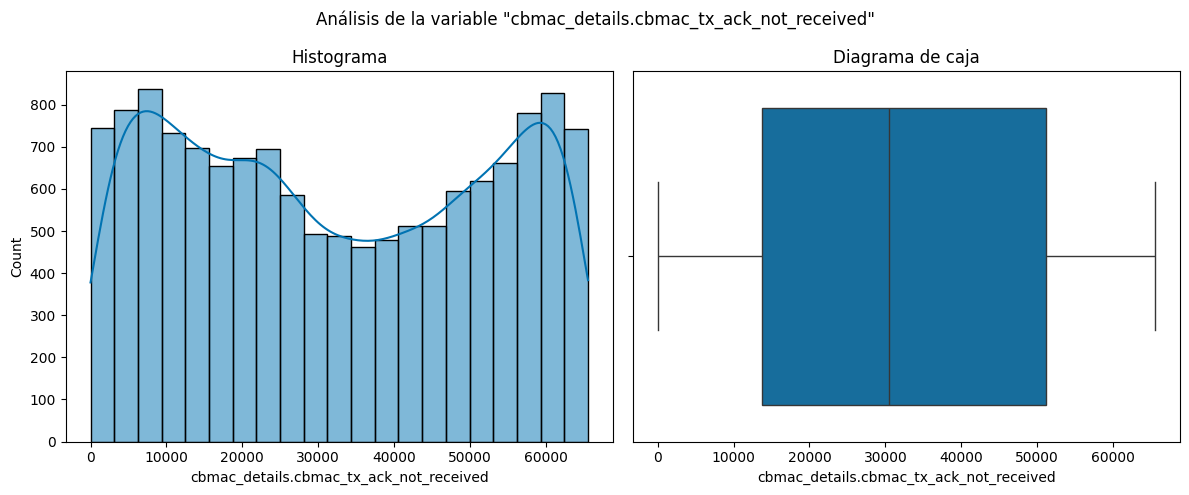

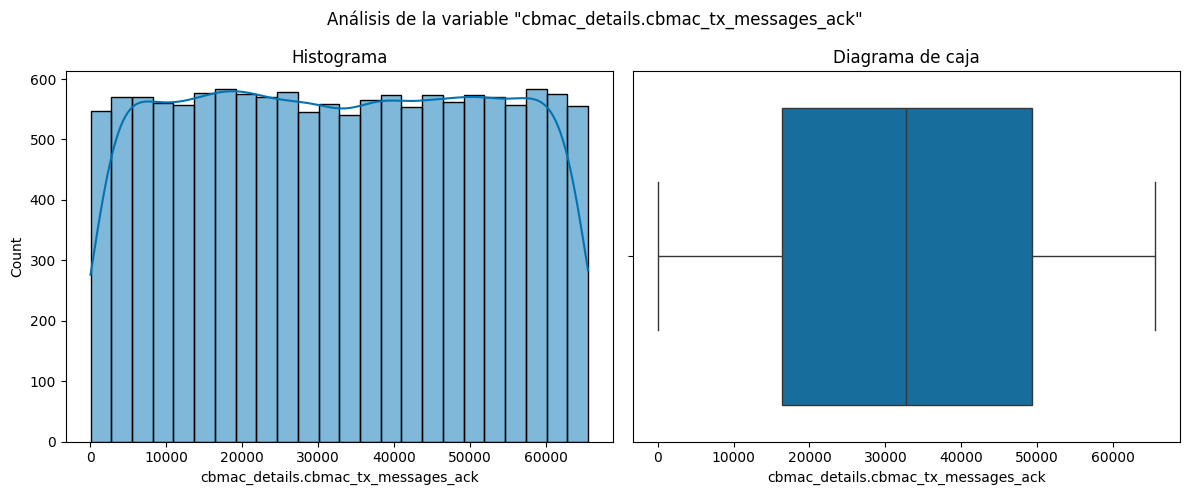

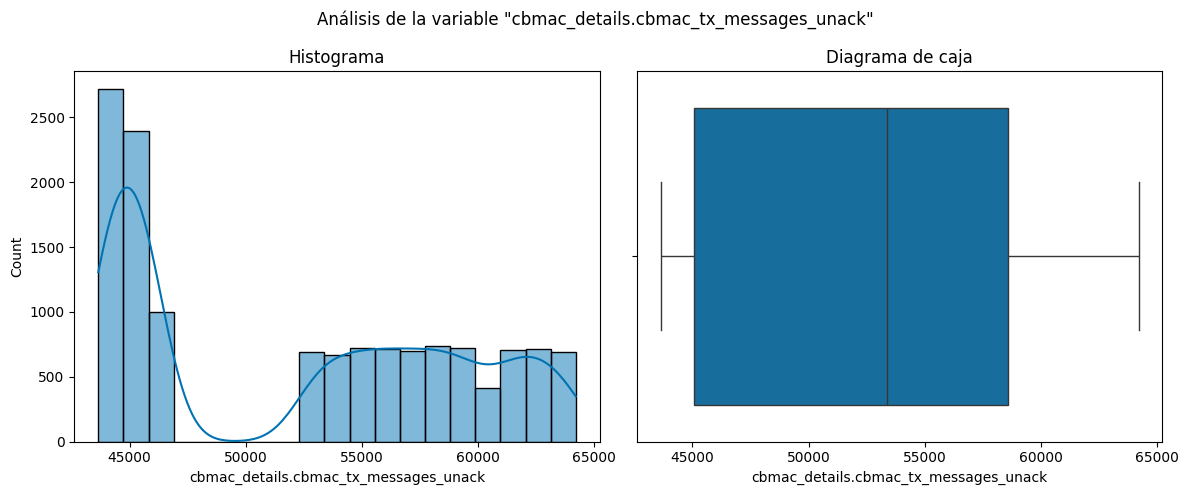

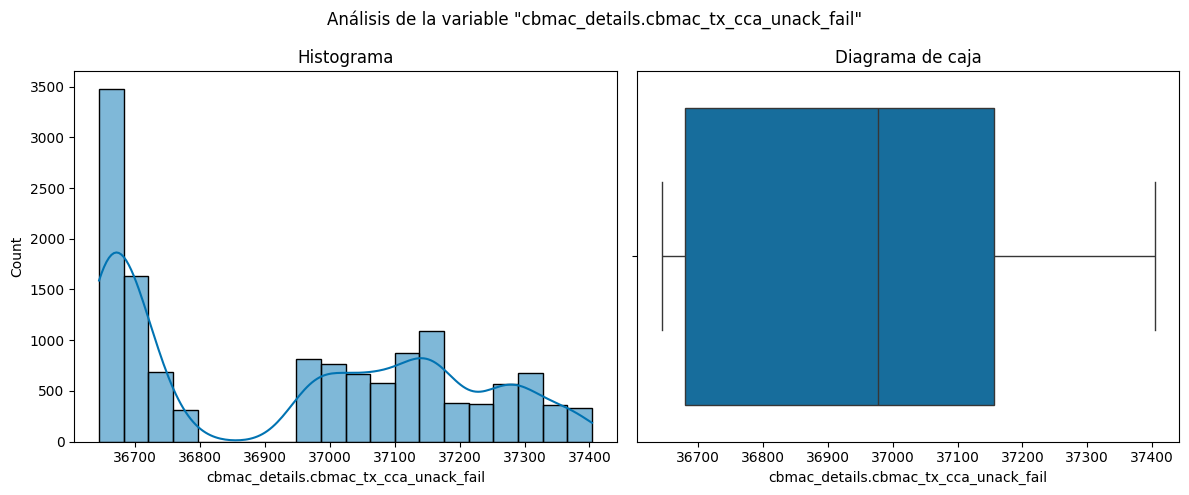

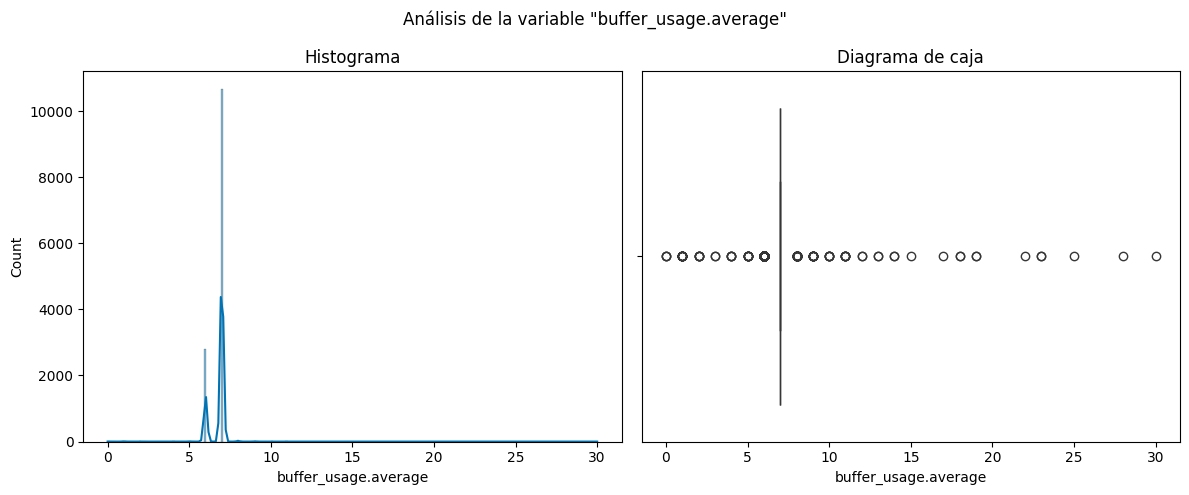

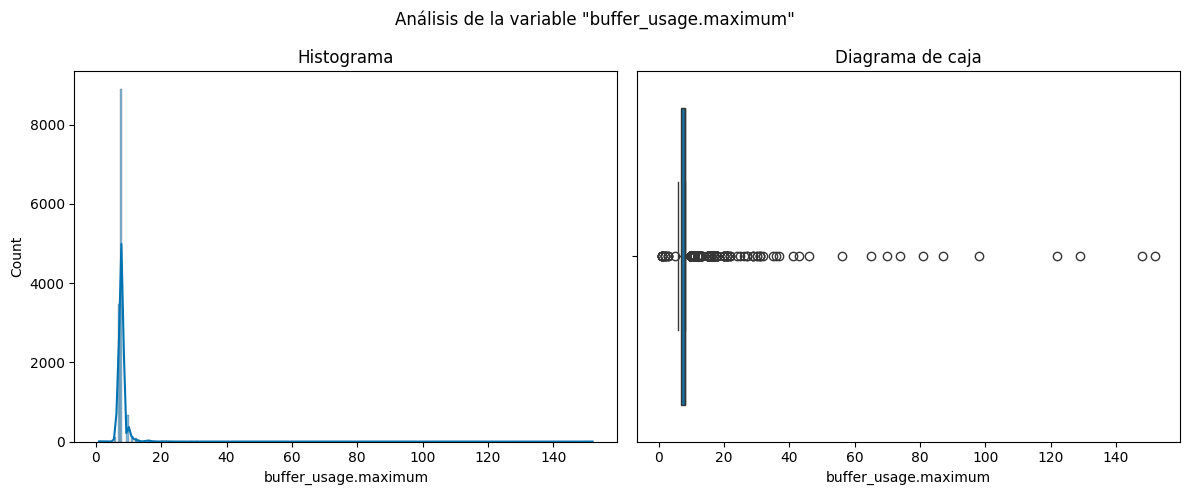

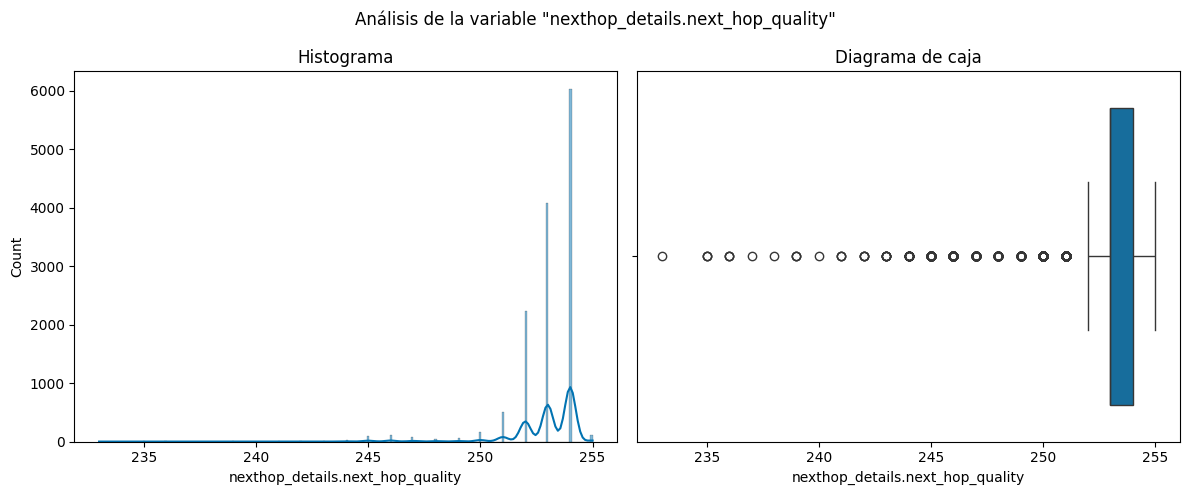

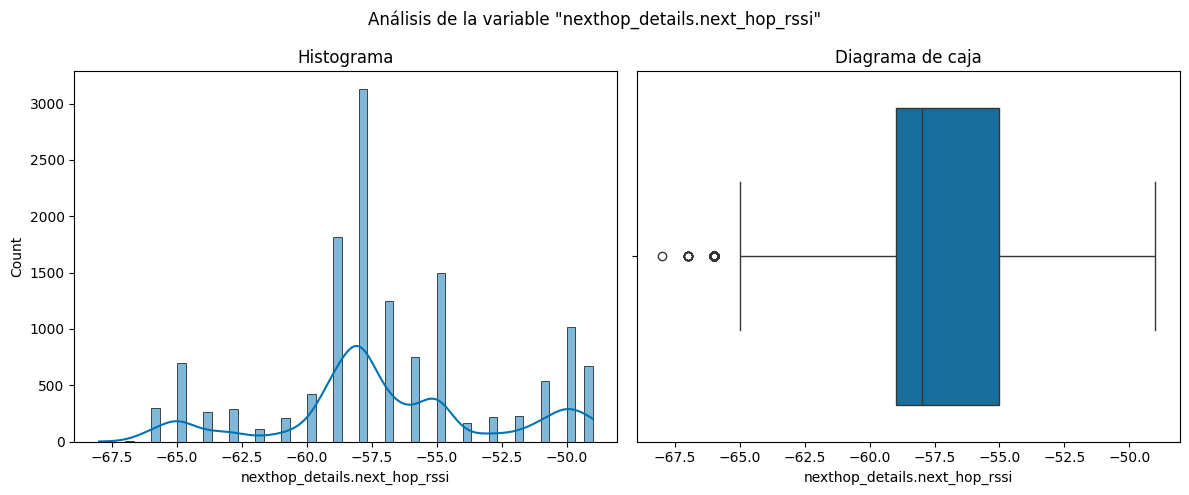

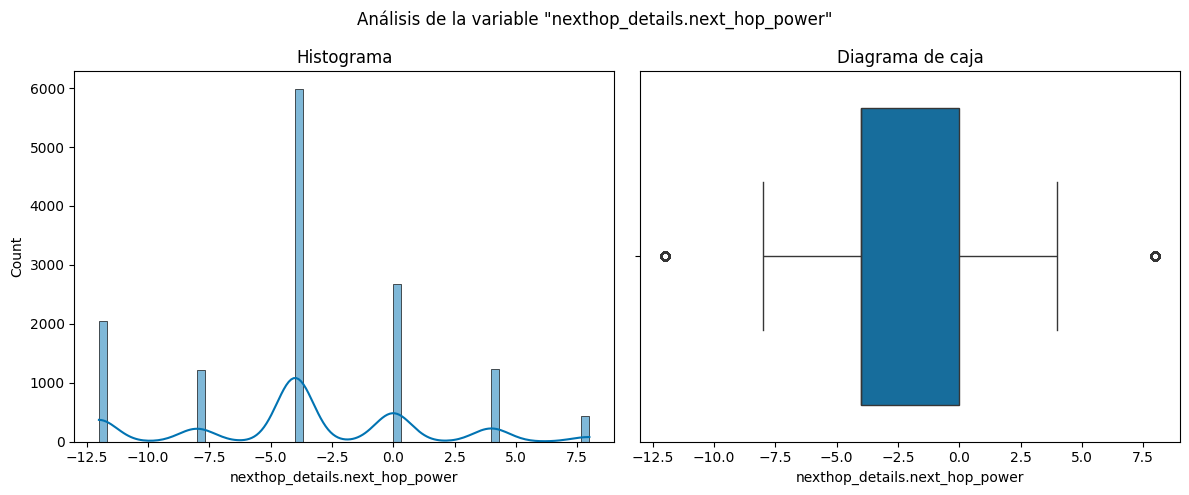

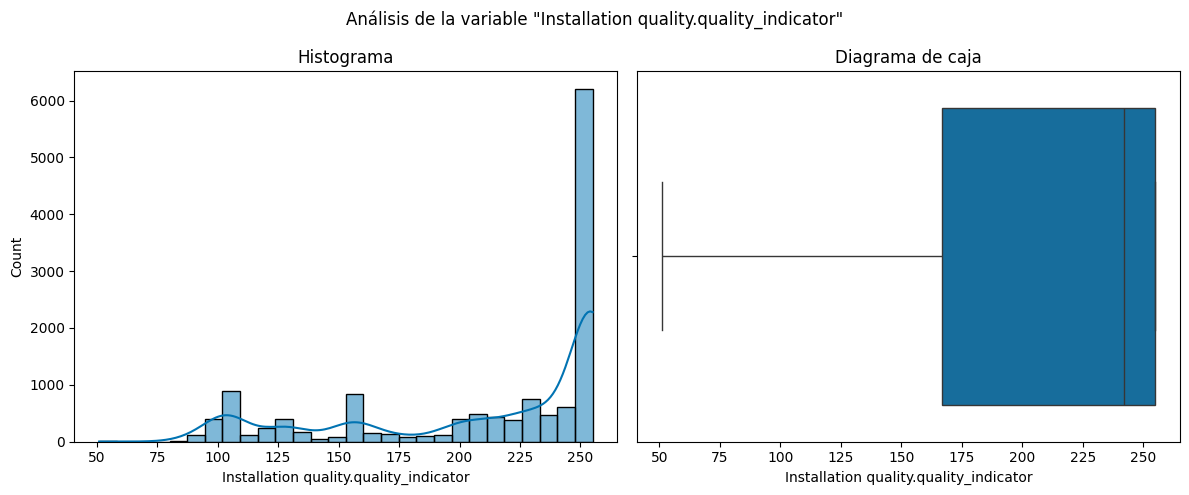

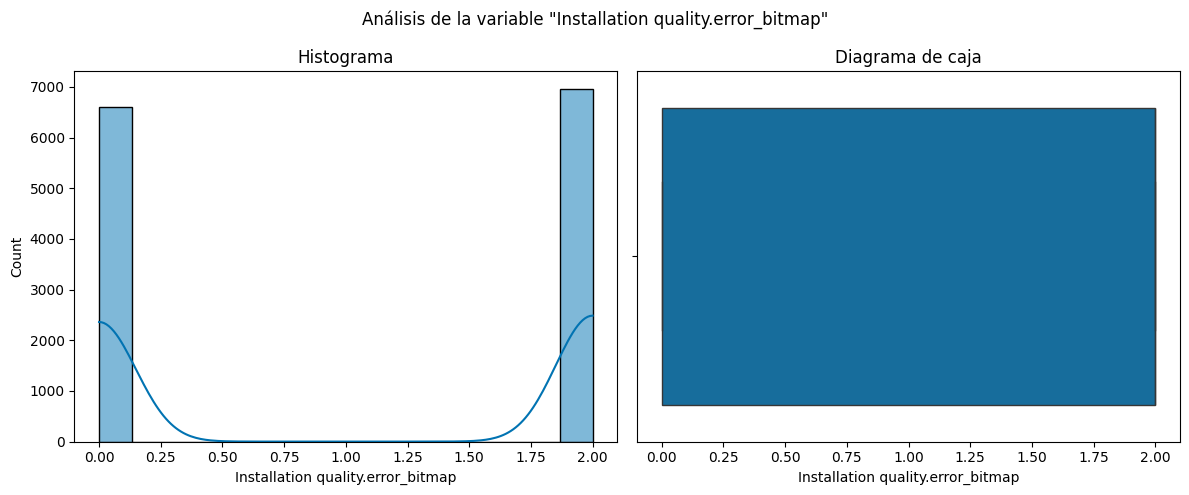

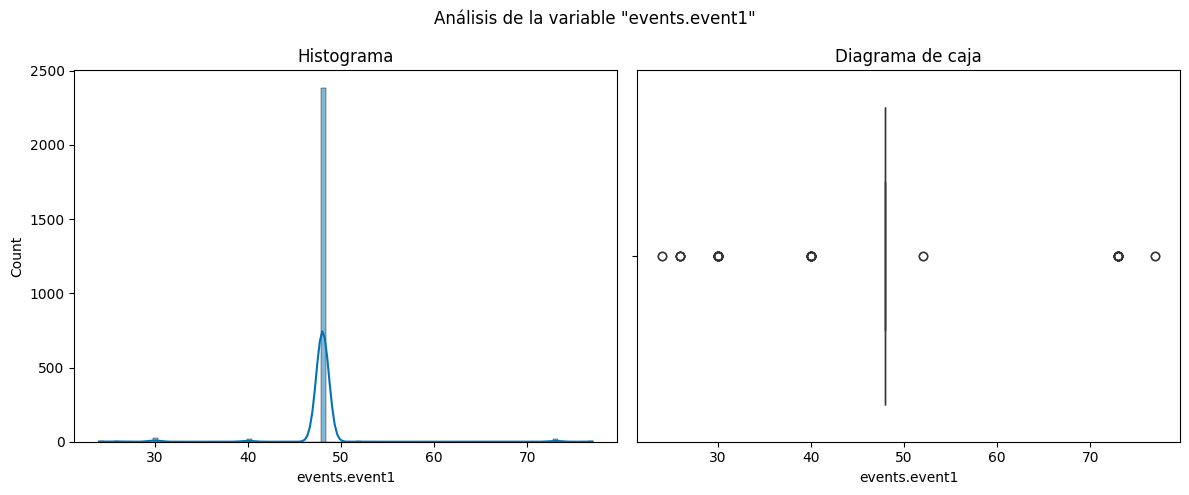

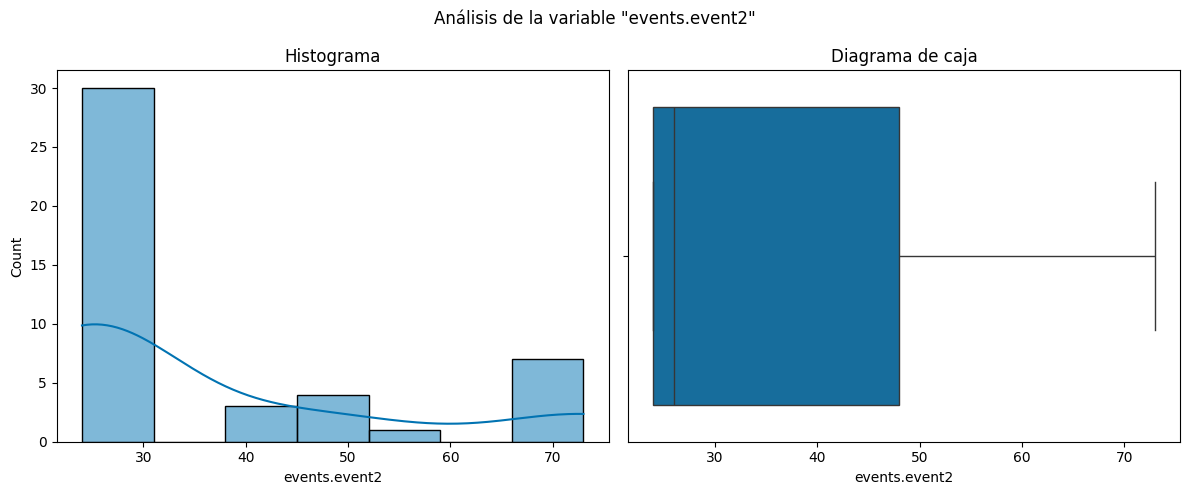

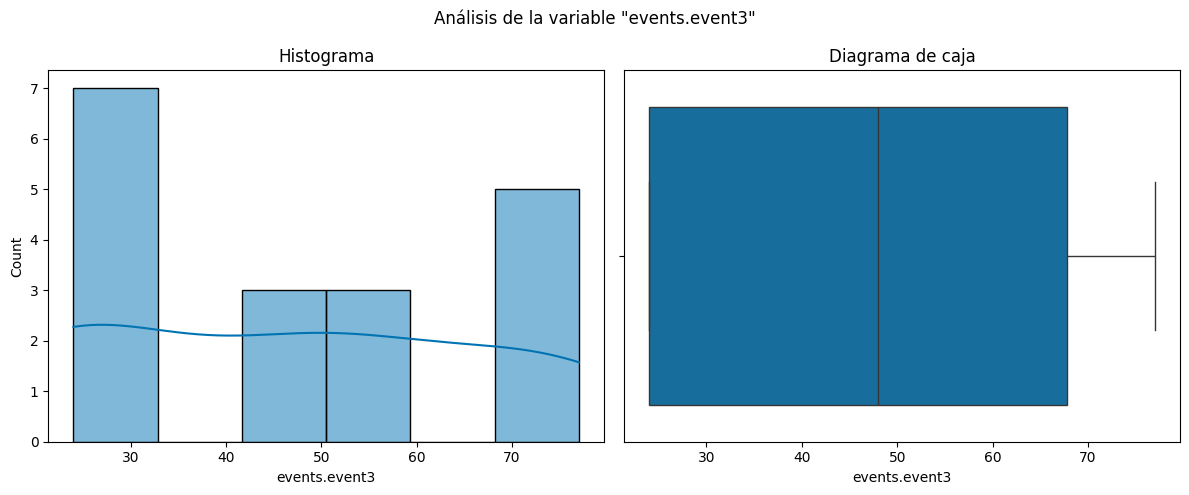

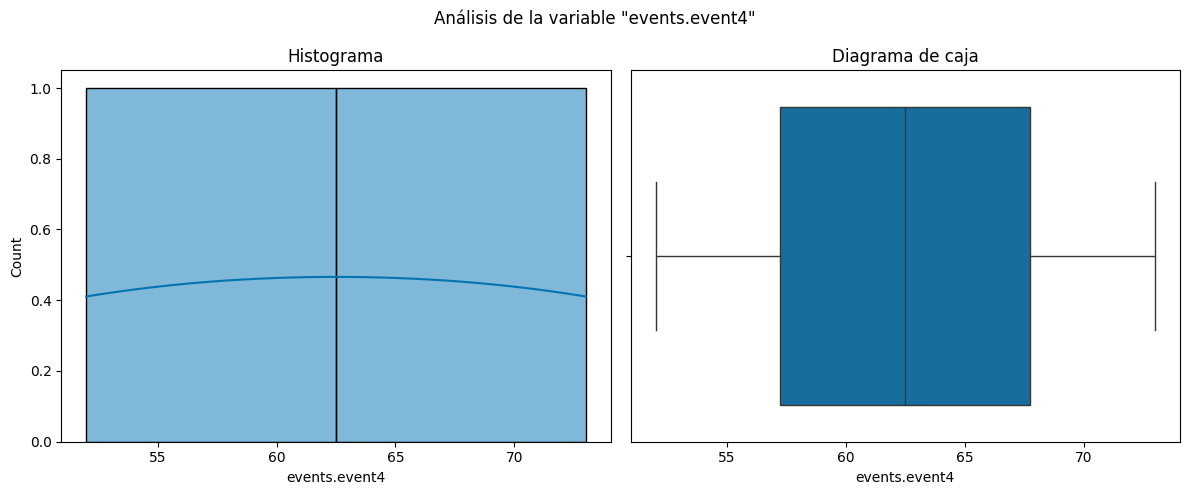

Columnas omitidas y razones:
- src: columna constante
- hops: columna constante
- inputState: columna constante
- error: columna constante
- hours_in_emergency: columna constante
- times_in_emergency: columna constante
- times_in_power: columna constante
- two_in_one_battery_level: columna constante
- configuration: columna constante
- last_hw_test_result: columna constante
- last_sw_test_result: columna constante
- pictogram: columna constante
- brightness: columna constante
- configured: columna constante
- sensors: columna constante
- device_type: columna constante
- error_code: columna constante
- model: columna constante
- battery_type: columna constante
- app_firmware_major: columna constante
- app_firmware_minor: columna constante
- app_firmware_maintenaince: columna constante
- app_firmware_devel: columna constante
- app_stack_major: columna constante
- app_stack_minor: columna constante
- app_stack_maintenaince: columna constante
- app_stack_devel: columna constante
- app_TFT_

In [ ]:
X_src15 = X_train[X_train["src"] == 15]
skipped = {}
for column in numerical_features:
    try:
        # Extraer la columna
        x = X_src15[column]

        # Comprobar que queda más de 1 valor
        if len(x) < 2:
            skipped[column] = "menos de 2 valores"
            continue

        # Evitar columnas constantes (boxplot rompe si no varían)
        if x.nunique() < 2:
            skipped[column] = "columna constante"
            continue

        # Graficar
        plt.figure(figsize=(12,5))

        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(x, kde=True)
        plt.title("Histograma")

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=x)
        plt.title("Diagrama de caja")

        plt.suptitle(f'Análisis de la variable \"{column}\"')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error en la columna '{column}': {e}")

print("Columnas omitidas y razones:")
for col, reason in skipped.items():
    print(f"- {col}: {reason}")

### 3.3. Análisis y manejo de valores faltantes

Ahora podemos usar `missingno` para visualizar la magnitud y la estructura de estas ausencias. En particular, usaremos **`msno.matrix()`**, que muestra una matriz de todo el conjunto de datos. Las barras negras representan datos presentes, y las **líneas blancas representan datos faltantes**. Nos permite ver patrones: ¿tienden a faltar valores en las mismas filas?

<Figure size 1500x500 with 0 Axes>

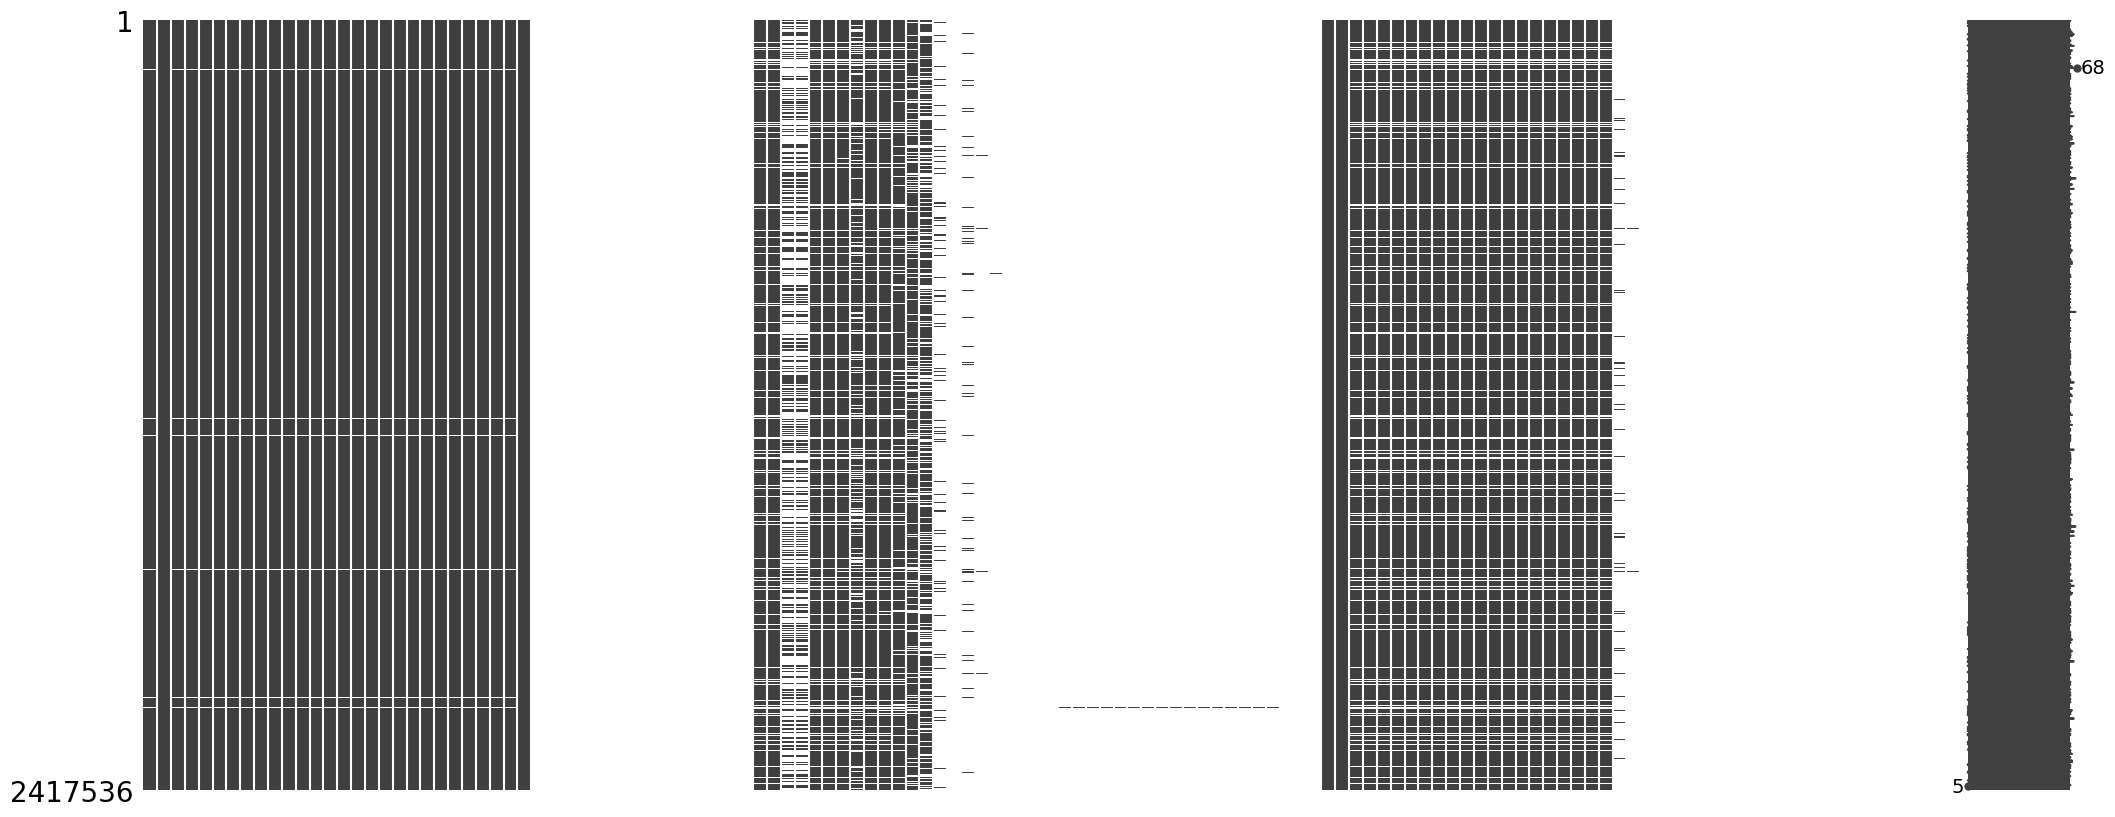

In [ ]:
plt.figure(figsize=(15,5))  # aumentar tamaño horizontal
msno.matrix(X_train)
plt.xticks(rotation=45)      # rotar nombres de columnas
plt.show()

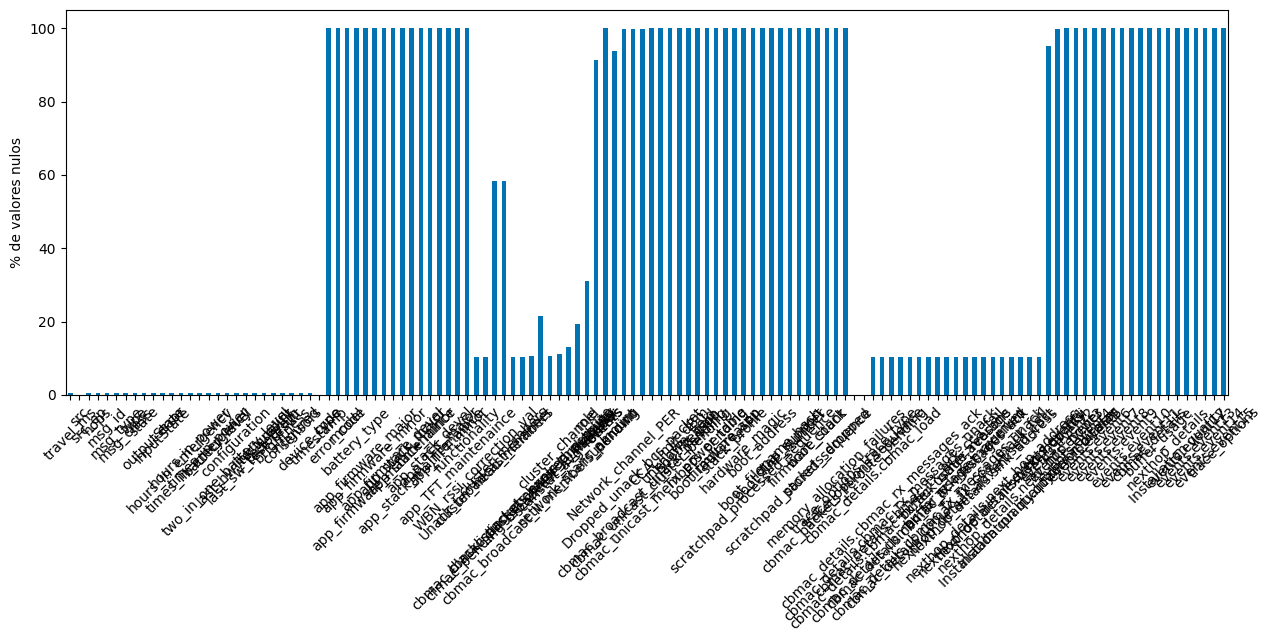

In [9]:
null_pct = X_train.isnull().mean() * 100
null_pct.plot(kind="bar", figsize=(15,5))
plt.ylabel("% de valores nulos")
plt.xticks(rotation=45)
plt.show()

In [9]:
null_pct = X_train.isnull().mean() * 100  # porcentaje de nulos
null_summary = null_pct.sort_values(ascending=False).reset_index()
null_summary.columns = ["Variable", "% Nulos"]

print("Resumen de valores nulos por columna:")
print(null_summary.to_string(index=False))

Resumen de valores nulos por columna:
                                Variable    % Nulos
                                  events 100.000000
                            buffer_usage 100.000000
                           cbmac_details 100.000000
                         nexthop_details 100.000000
                    Installation quality 100.000000
                           trace_options 100.000000
              memory_allocation_failures  99.999876
           cbmac_packets_reroute_pending  99.999752
                         packets_dropped  99.999710
                          events.event15  99.999007
                          events.event14  99.998925
                          events.event13  99.998800
                                 Rx_gain  99.998676
                          hardware_magic  99.998676
           scratchpad_processed_sequence  99.998676
                             Boot_reason  99.998676
                          Tx_power_table  99.998676
                          

#### 3.2.2. Categóricas

Para las variables categóricas, no nos interesa la media o la mediana, sino:

* **Cardinalidad:** Cuántos valores únicos (`unique`) tiene cada una. Una cardinalidad alta (muchas categorías) puede ser problemática.
* **Frecuencia:** Cuál es el valor más frecuente (`top`) y cuántas veces aparece (`freq`).
* **Valores faltantes ocultos:** Si el valor más frecuente (`top`) o la lista de valores únicos revela la presencia de `"unknown"` u otros marcadores.

In [10]:
X_train['msg_class'] = X_train['msg_class'].astype('category')
X_train['msg_type'] = X_train['msg_type'].astype('category')
X_train['trace_options.trace_type'] = X_train['trace_options.trace_type'].astype('category')
X_train['configured'] = X_train['configured'].astype('category')
X_train['device_type'] = X_train['device_type'].astype('category')
X_train['error'] = X_train['error'].astype('category')
X_train['configuration'] = X_train['configuration'].astype('category')
X_train['inputState'] = X_train['inputState'].astype('category')
X_train['last_hw_test_result'] = X_train['last_hw_test_result'].astype('category')
X_train['last_sw_test_result'] = X_train['last_sw_test_result'].astype('category')
X_train['sensors'] = X_train['sensors'].astype('category')
X_train['pictogram'] = X_train['pictogram'].astype('category')
X_train['cbmac_packets_expired_pending'] = X_train['cbmac_packets_expired_pending'].astype('category')
X_train['Dropped_unack_bcs_packet'] = X_train['Dropped_unack_bcs_packet'].astype('category')
X_train['cbmac_broadcast_unack_pending'] = X_train['cbmac_broadcast_unack_pending'].astype('category')

include = ["object", "category"]  # Data types to include
categorical_features = X_train.select_dtypes(include=include).columns.tolist()
X_train[categorical_features].describe().T

,count,unique,top,freq
msg_type,2405208,2,0,2404577
msg_class,2405208,5,StatusData,2404577
type,2405208,5,StatusData,2404577
inputState,2404577,2,0,2265631
error,2404577,13,128,2089791
configuration,2404577,1,9,2404577
last_hw_test_result,2404577,1,0,2404577
last_sw_test_result,2404577,1,0,2404577
pictogram,2404577,5,0,2182442
configured,2404577,1,0,2404577


### 3.4. Detección de duplicados e inconsistencias

En esta etapa se identifican registros duplicados y se verifican inconsistencias básicas, como formatos incorrectos o valores fuera de los rangos esperados, con el fin de garantizar la calidad y coherencia del conjunto de datos. Dado que ya se realizó una revisión de los rangos durante la exploración inicial de las variables, no es necesario repetir este análisis en esta fase.

In [11]:
hashable_cols = [col for col in data.columns if data[col].apply(lambda x: isinstance(x, (int, float, str, type(None)))).all()]
duplicates = data[hashable_cols].duplicated()
num_duplicates = duplicates.sum()
print(f"Número de columnas hasheables {len(hashable_cols)}\nNúmero de filas duplicadas: {num_duplicates}")

Número de columnas hasheables 124
Número de filas duplicadas: 0


Tal como se observa, no existen registros duplicados en el conjunto de datos.

No obstante, también es posible identificar duplicados parciales, es decir, registros que comparten el mismo identificador pero presentan diferencias en otros campos.

In [12]:
# Detect duplicate indices
keep = False  # Mark all duplicates as "True"
mask = data.index.duplicated(keep=keep)
duplicated_indices = data.index[mask]

# Filter records with duplicate indices
duplicated_records = data.loc[duplicated_indices]

# Verify if, for each duplicated index, the records are different
# Group by index and check if there are multiple unique rows
level = 0  # Group by index level
function = lambda group: group.drop_duplicates().shape[0] > 1
grouped = duplicated_records.groupby(level=level).filter(function)

# Display the found records
print("Duplicados parciales (mismo índice, datos diferentes):")
grouped

Duplicados parciales (mismo índice, datos diferentes):


,travel_ms,src,src_ep,hops,msg_id,msg_type,msg_class,type,state,outputState,...,events.event11,cbmac_details,buffer_usage,nexthop_details,Installation quality,events.event12,events.event13,events.event14,events.event15,trace_options


Eliminamos los atributos que tienen como nulos más del 32% de los valores


In [13]:
null_over_32pct = null_pct[null_pct > 32].index.tolist()
print(f"Atributos totales: {len(X_train.columns)}\nAtributos con nulos < 32%:", len(X_train.columns) - len(null_over_32pct))
dropped_cols = set(null_over_32pct.copy())
dropped_cols


Atributos totales: 126
Atributos con nulos < 32%: 60


{'Boot_reason',
 'CCA_limit_dBm',
 'Dropped_unack_bcs_packet',
 'Installation quality',
 'Network_channel_PER',
 'Rx_gain',
 'Tx_power_table',
 'app_TFT_maintenaince',
 'app_TFT_major',
 'app_TFT_minor',
 'app_firmware_devel',
 'app_firmware_maintenaince',
 'app_firmware_major',
 'app_firmware_minor',
 'app_stack_devel',
 'app_stack_maintenaince',
 'app_stack_major',
 'app_stack_minor',
 'battery_type',
 'boot_address',
 'boot_count',
 'boot_fault_reason',
 'boot_filename_hash',
 'boot_line_number',
 'buffer_usage',
 'cbmac_broadcast_unack_pending',
 'cbmac_details',
 'cbmac_packets_reroute_pending',
 'cbmac_unicast_cluster_pending',
 'cbmac_unicast_members_pending',
 'cluster_head_members',
 'cluster_members',
 'code',
 'error_code',
 'events',
 'events.event1',
 'events.event10',
 'events.event11',
 'events.event12',
 'events.event13',
 'events.event14',
 'events.event15',
 'events.event2',
 'events.event3',
 'events.event4',
 'events.event5',
 'events.event6',
 'events.event7',
 'ev

Eliminamos los atributos que son constantes

In [14]:
const_cols = []
threshold = 1e-3

for col in X_train.columns:
    if col in ['src', 'timestamp']:   # columnas a ignorar
        continue
    
    try:
        # solo entra si los valores son hashables
        if X_train[col].std(skipna=True) < threshold or X_train[col].nunique() == 1:
            const_cols.append(col)
            
    except TypeError as e:
        # si hay listas u objetos no-hashables la saltamos
        print(f"Saltada columna: {col}\t{e}")
        continue

dropped_cols.update(const_cols)
print(f"Número de atributos constantes: {len(const_cols)}")
print("Número de atributos a eliminar: ",len(dropped_cols))
dropped_cols

Saltada columna: msg_type	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: msg_class	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: type	could not convert string to float: 'StatusData'
Saltada columna: inputState	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: error	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: configuration	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: last_hw_test_result	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: last_sw_test_result	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: pictogram	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: configured	'Categorical' with dtype category does not support reduction 'std'
Saltada columna: sensors	'Categorical' with dtype category does

{'Boot_reason',
 'CCA_limit_dBm',
 'Dropped_unack_bcs_packet',
 'Installation quality',
 'Network_channel_PER',
 'Rx_gain',
 'Tx_power_table',
 'app_TFT_maintenaince',
 'app_TFT_major',
 'app_TFT_minor',
 'app_firmware_devel',
 'app_firmware_maintenaince',
 'app_firmware_major',
 'app_firmware_minor',
 'app_stack_devel',
 'app_stack_maintenaince',
 'app_stack_major',
 'app_stack_minor',
 'battery_type',
 'boot_address',
 'boot_count',
 'boot_fault_reason',
 'boot_filename_hash',
 'boot_line_number',
 'buffer_usage',
 'cbmac_broadcast_unack_pending',
 'cbmac_details',
 'cbmac_packets_reroute_pending',
 'cbmac_unicast_cluster_pending',
 'cbmac_unicast_members_pending',
 'cluster_head_members',
 'cluster_members',
 'code',
 'error_code',
 'events',
 'events.event1',
 'events.event10',
 'events.event11',
 'events.event12',
 'events.event13',
 'events.event14',
 'events.event15',
 'events.event2',
 'events.event3',
 'events.event4',
 'events.event5',
 'events.event6',
 'events.event7',
 'ev

Al no haberse podido tratar msg_class, type, unkownk_field, Tx_power_table, firmware_app y firmware_stack se eliminarán por los siguientes motivos:

- msg_class: es practicamente coninua con 2405118 ocurrencias y apareciendo el mismo valor 2404487 veces -> 99,97% de entradas con el mismo valor
- type: es practicamente continua con 2405118 ocurrencias y apareciendo el mismo valor 2404487 veces -> 99,97% de entradas con el mismo valor
- unknownk_field: se desconoce que indica por lo que se eliminará para eliminar ruido
- Tx_power_table: todos sus valores son practicamente nulos con unicamente 30 apariciones no nulo -> 99,999% de valores nulos
- firmware_app: todos sus valores son practicamente nulos con unicamente 30 apariciones no nulo -> 99,999% de valores nulos
- firmware_stack: todos sus valores son practicamente nulos con unicamente 30 apariciones no nulo -> 99,999% de valores nulos



In [15]:
cols = ["msg_class", "type", "unknown_field", "Tx_power_table", "firmware_app", "firmware_stack"]
dropped_cols.update(cols)

Eliminamos los atributos que son casi consistentes

In [16]:
alm_const_cols = []
freq_max_list = []
for col in X_train.columns:
    if col in ['src', 'timestamp']:   # columnas a ignorar
        continue
    
    try:
        top_freq = X_train[col].value_counts(normalize=True, dropna=False).max()
        if top_freq >= 0.95:
            print(f"Columna casi constante detectada: {col} (frecuencia máxima: {top_freq:.2%})")
            alm_const_cols.append(col)
            freq_max_list.append(top_freq)
    except TypeError as e:
        print(f"Error en la columna '{col}': {e}")
        continue

dropped_cols.update(alm_const_cols)
print(f"Número de atributos casi constantes: {len(alm_const_cols)}")
dropped_cols

Columna casi constante detectada: src_ep (frecuencia máxima: 99.49%)
Columna casi constante detectada: msg_type (frecuencia máxima: 99.46%)
Columna casi constante detectada: msg_class (frecuencia máxima: 99.46%)
Columna casi constante detectada: type (frecuencia máxima: 99.46%)
Columna casi constante detectada: state (frecuencia máxima: 99.34%)
Columna casi constante detectada: two_in_one_battery_level (frecuencia máxima: 99.46%)
Columna casi constante detectada: configuration (frecuencia máxima: 99.46%)
Columna casi constante detectada: last_hw_test_result (frecuencia máxima: 99.46%)
Columna casi constante detectada: last_sw_test_result (frecuencia máxima: 99.46%)
Columna casi constante detectada: configured (frecuencia máxima: 99.46%)
Columna casi constante detectada: sensors (frecuencia máxima: 99.46%)
Columna casi constante detectada: device_type (frecuencia máxima: 99.46%)
Columna casi constante detectada: code (frecuencia máxima: 99.97%)
Columna casi constante detectada: error_co

{'Boot_reason',
 'CCA_limit_dBm',
 'Dropped_unack_bcs_packet',
 'Installation quality',
 'Network_channel_PER',
 'Rx_gain',
 'Tx_power_table',
 'app_TFT_maintenaince',
 'app_TFT_major',
 'app_TFT_minor',
 'app_firmware_devel',
 'app_firmware_maintenaince',
 'app_firmware_major',
 'app_firmware_minor',
 'app_stack_devel',
 'app_stack_maintenaince',
 'app_stack_major',
 'app_stack_minor',
 'battery_type',
 'boot_address',
 'boot_count',
 'boot_fault_reason',
 'boot_filename_hash',
 'boot_line_number',
 'buffer_usage',
 'cbmac_broadcast_unack_pending',
 'cbmac_details',
 'cbmac_packets_reroute_pending',
 'cbmac_unicast_cluster_pending',
 'cbmac_unicast_members_pending',
 'cluster_head_members',
 'cluster_members',
 'code',
 'configuration',
 'configured',
 'device_type',
 'error_code',
 'events',
 'events.event1',
 'events.event10',
 'events.event11',
 'events.event12',
 'events.event13',
 'events.event14',
 'events.event15',
 'events.event2',
 'events.event3',
 'events.event4',
 'events.

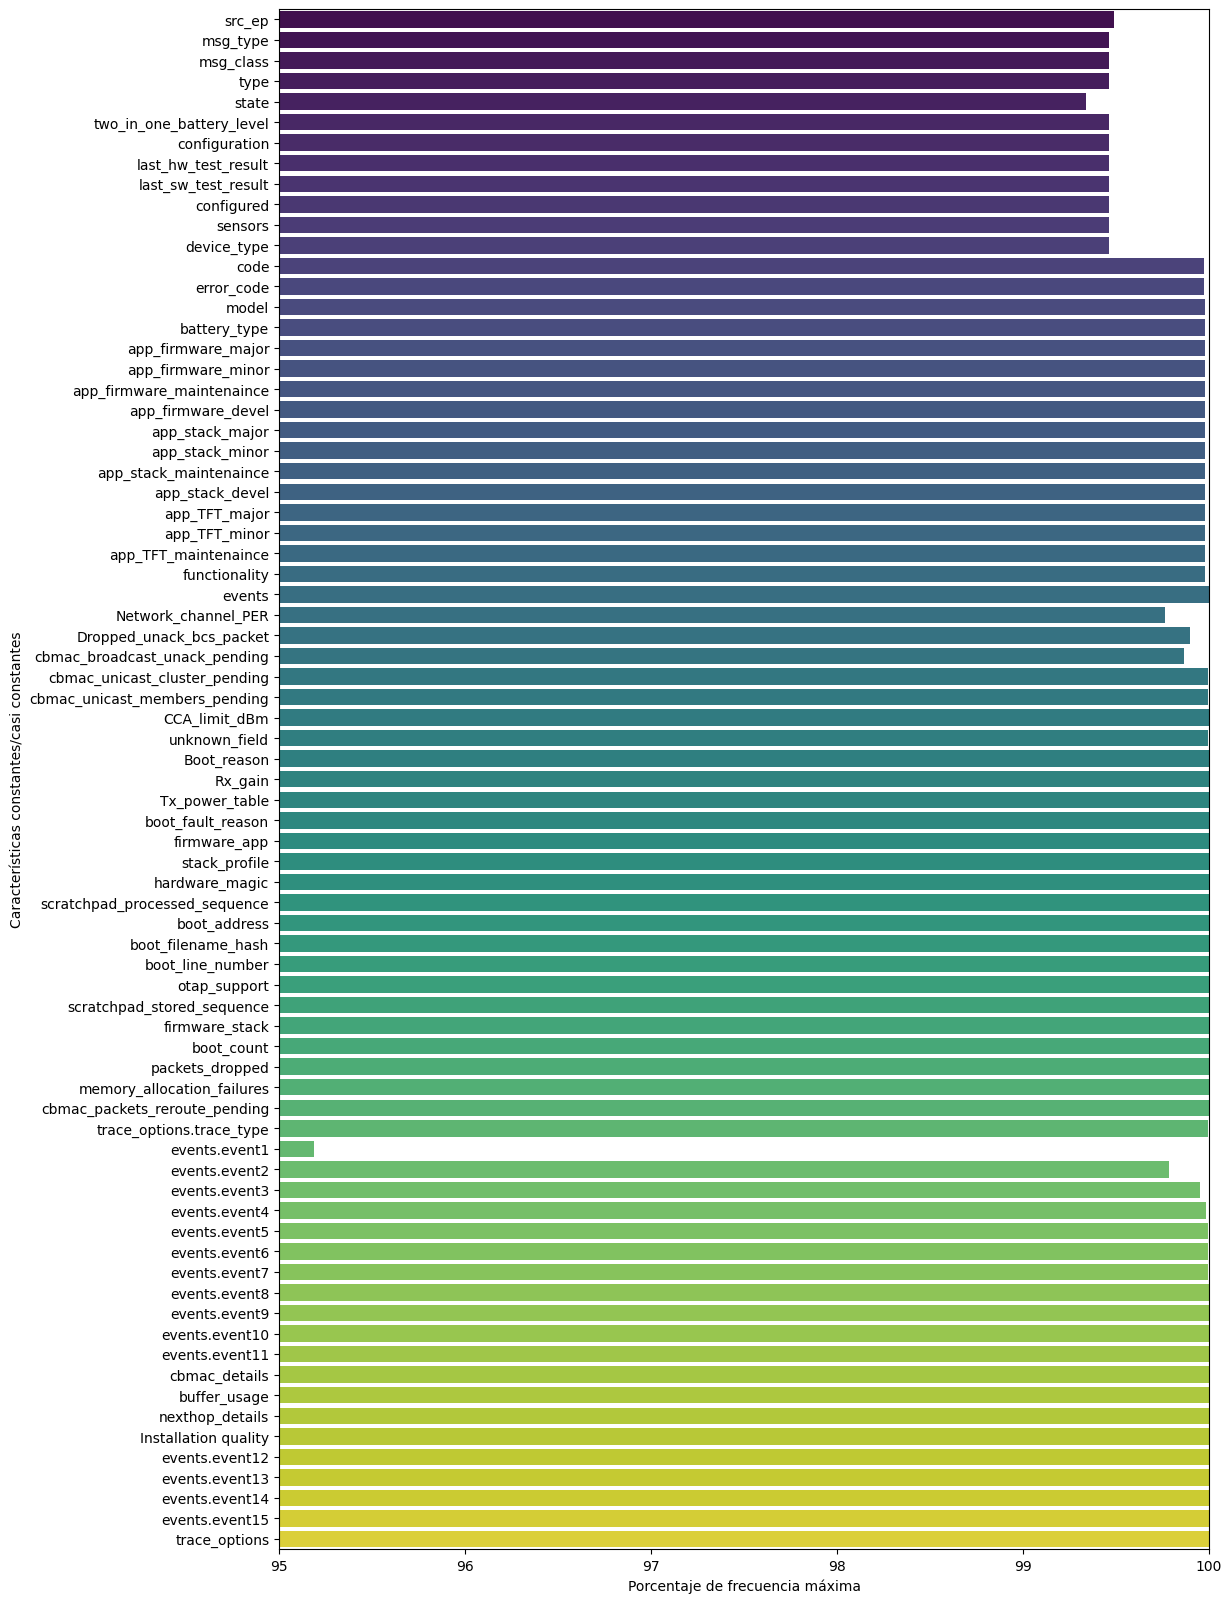

In [41]:
freq_percent = [f * 100 for f in freq_max_list]
if alm_const_cols:
    plt.figure(figsize=(12, 20))
    sns.barplot(x=freq_percent, y=alm_const_cols, palette="viridis")
    plt.xlabel("Porcentaje de frecuencia máxima")
    plt.ylabel("Características constantes/casi constantes")
    plt.xlim(95, 100)  # rango ajustado para destacar casi constantes
    plt.show()

Por último eliminamos las variables que no aportan información relevante para la detección de anomalías como msg_id

In [17]:
cols = ['timestamp', 'nexthop_details.sink_address', 'msg_id']
dropped_cols.update(cols)

In [18]:
X_train_cleaned = X_train.drop(columns=dropped_cols)

Tratamos los valores nulos que aún existen en nuestro dataset

In [19]:
for _, row in null_summary.iterrows():
    if row['Variable'] in dropped_cols:
        continue
    if row['% Nulos'] < 32:
        X_train_cleaned[row['Variable']] = X_train_cleaned[row['Variable']].fillna(X_train_cleaned[row['Variable']].mode()[0])

Tratamos los valores extremos

In [20]:
factor = 1.5 #cambiar a 1.5 o 3
num_atr = X_train_cleaned.select_dtypes(include=['number']).columns.tolist()

mask_global = pd.Series(True, index=X_train_cleaned.index)

for col in num_atr:
    q1 = X_train_cleaned[col].quantile(0.25)
    q3 = X_train_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    
    mask_col = (X_train_cleaned[col] >= q1 - factor*iqr) & (X_train_cleaned[col] <= q3 + factor*iqr)
    mask_global &= mask_col  # acumula
    
X_train_cleaned = X_train_cleaned[mask_global]

Normalizamos los datos excepto por las características que son identificadores. También se normalizarán los datos de el dataset de testing para que sean comparables ambos dataset y se eliminarán las entradas nulas debido a que esto afecta mucho a la precisión en HDC

In [21]:
cols_to_keep = ['src', 'nexthop_details.next_hop_address', 'cfmac_pending_broadcast_le_member', 'Unack_broadcast_channel']
cols_to_scale = [col for col in X_train_cleaned.columns if col not in cols_to_keep]


scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_train_cleaned[cols_to_scale]), columns=cols_to_scale)

X_train_cleaned = pd.concat([X_scaled, X_train_cleaned[cols_to_keep]], axis=1)

Después de la normalización, volvemos a analizar las variables constantes debido a que puede que haya alguna que debido a una baja varianza se haya convertido en constante

In [22]:
alm_const_cols = []
for col in X_train_cleaned.columns:
    if col in ['src', 'timestamp']:   # columnas a ignorar
        continue
    
    try:
        top_freq = X_train_cleaned[col].value_counts(normalize=True, dropna=False).max()
        if top_freq >= 0.95:
            print(f"Columna casi constante detectada: {col} (frecuencia máxima: {top_freq:.2%})")
            alm_const_cols.append(col)
    except TypeError as e:
        print(f"Error en la columna '{col}': {e}")
        continue

print(f"Número de atributos casi constantes: {len(alm_const_cols)}")

X_train_cleaned = X_train_cleaned.drop(columns=alm_const_cols)

Columna casi constante detectada: outputState (frecuencia máxima: 100.00%)
Columna casi constante detectada: inputState (frecuencia máxima: 100.00%)
Columna casi constante detectada: error (frecuencia máxima: 100.00%)
Columna casi constante detectada: pictogram (frecuencia máxima: 95.56%)
Columna casi constante detectada: brightness (frecuencia máxima: 100.00%)
Columna casi constante detectada: cbmac_packets_expired_pending (frecuencia máxima: 100.00%)
Columna casi constante detectada: cbmac_broadcast_ll_members_pending (frecuencia máxima: 100.00%)
Columna casi constante detectada: cluster_channel_reliability (frecuencia máxima: 100.00%)
Columna casi constante detectada: role (frecuencia máxima: 100.00%)
Columna casi constante detectada: buffer_usage.maximum (frecuencia máxima: 100.00%)
Columna casi constante detectada: Installation quality.error_bitmap (frecuencia máxima: 100.00%)
Número de atributos casi constantes: 11


In [24]:
data_75 = X_train_cleaned[X_train_cleaned['src'] == 75]
data_75 = data_75.drop(columns=['src'])
data_75.to_json('lum_75_train.json', orient='records', lines=True)
del data_75

data_90 = X_train_cleaned[X_train_cleaned['src'] == 90]
data_90.to_json('lum_90_train.json', orient='records', lines=True)
del data_90

data_120 = X_train_cleaned[X_train_cleaned['src'] == 120]
data_120.to_json('lum_120_train.json', orient='records', lines=True)
del data_120

In [23]:
# Describimos el dataset modificado
print("Total number of atributes before cleaning", len(X_train.columns) - 2)  # restamos 2 por src y timestamp
print("Total number of atributes", len(X_train_cleaned.columns) - 1)  # restamos 1 por src
attr = [c for c in X_train_cleaned.columns if c not in ['src']]
print("Final Attributes: ", attr)
print("Total number of records", len(X_train_cleaned))
pd.set_option('display.max_rows', None)      # muestra todas las filas
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.width', 2000)         # ancho total para evitar saltos
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)
X_train_cleaned.describe().T

Total number of atributes before cleaning 124
Total number of atributes 32
Final Attributes:  ['travel_ms', 'hops', 'hours_in_emergency', 'hours_in_power', 'times_in_emergency', 'times_in_power', 'battery_level', 'link_quality', 'WBN_rssi_correction_val', 'cbmac_blacklisting_channels_min_to_40', 'cluster_channel', 'scanstat_avg_routers', 'network_scans_amount', 'trace_options.sequence', 'cbmac_details.cbmac_load', 'cbmac_details.cbmac_rx_messages_ack', 'cbmac_details.cbmac_rx_messages_unack', 'cbmac_details.cbmac_rx_ack_other_reasons', 'cbmac_details.cbmac_tx_ack_cca_fail', 'cbmac_details.cbmac_tx_ack_not_received', 'cbmac_details.cbmac_tx_messages_ack', 'cbmac_details.cbmac_tx_messages_unack', 'cbmac_details.cbmac_tx_cca_unack_fail', 'buffer_usage.average', 'nexthop_details.advertised_cost', 'nexthop_details.next_hop_quality', 'nexthop_details.next_hop_rssi', 'nexthop_details.next_hop_power', 'Installation quality.quality_indicator', 'nexthop_details.next_hop_address', 'cfmac_pending_

,count,mean,std,min,25%,50%,75%,max
travel_ms,380688.000,-0.000,1.000,-1.562,-0.644,-0.155,0.335,2.722
hops,380688.000,-0.000,1.000,-2.013,-0.547,-0.059,0.430,3.850
hours_in_emergency,380688.000,-0.000,1.000,-0.677,-0.677,-0.677,0.971,3.443
hours_in_power,380688.000,-0.000,1.000,-4.456,-0.528,-0.304,0.863,1.896
times_in_emergency,380688.000,0.000,1.000,-0.856,-0.856,-0.232,0.393,2.891
times_in_power,380688.000,0.000,1.000,-2.099,-0.599,-0.599,0.151,2.402
battery_level,380688.000,0.000,1.000,-2.007,-0.686,0.069,0.635,2.899
link_quality,380688.000,0.000,1.000,-4.020,-0.578,0.544,0.750,0.750
WBN_rssi_correction_val,380688.000,0.000,1.000,-1.740,-0.398,-0.398,0.944,2.286
cbmac_blacklisting_channels_min_to_40,380688.000,-0.000,1.000,-0.334,-0.334,-0.334,-0.315,5.777


Dataset para una única luminaria

In [25]:
print(f"Total number of records in dataset: {len(X_train_cleaned)}")
counts = X_train_cleaned['src'].value_counts()
for src, count in counts.items():
    print(f"Total number of records for lum {src} --> {count}")

Total number of records in dataset: 253143
Total number of records for lum 75 --> 7291
Total number of records for lum 150 --> 6485
Total number of records for lum 49 --> 5837
Total number of records for lum 52 --> 5799
Total number of records for lum 80 --> 5710
Total number of records for lum 110 --> 5640
Total number of records for lum 191 --> 5264
Total number of records for lum 193 --> 5252
Total number of records for lum 152 --> 5208
Total number of records for lum 148 --> 5199
Total number of records for lum 39 --> 5106
Total number of records for lum 40 --> 5094
Total number of records for lum 184 --> 4982
Total number of records for lum 89 --> 4792
Total number of records for lum 141 --> 4706
Total number of records for lum 8 --> 4475
Total number of records for lum 187 --> 4464
Total number of records for lum 24 --> 4464
Total number of records for lum 154 --> 4424
Total number of records for lum 157 --> 4320
Total number of records for lum 121 --> 4294
Total number of record

## 5. Dataset de testing y datos sintéticos

Para la generación del dataset sintético deberemos de aplicar el ruido antes de la normalización no a posteriori.

Lo primero que hacemos es definimos la función que nos permitirá calcular un nuevo valor con el ruido añadido.

In [25]:
def calculate_new_value(value, alpha): # ruido heterocedástico ε∼N(0​,(α∣Xreal​∣)^2)
    sigma = alpha * abs(value) 
    epsilon = np.random.normal(0, sigma)
    return value + epsilon

Antes de empezar, eliminamos las filas con nulos debido a que HDC es muy sensible a valores nulos y encontrarse alguno va a suponer que se clasifique como anomalía

In [40]:
X_test_cleaned = X_test.drop(columns=dropped_cols)
X_test_cleaned = X_test_cleaned.dropna()

In [48]:
X_test_synthetic_005 = X_test_cleaned.copy()
X_test_synthetic_02 = X_test_cleaned.copy()
X_test_synthetic_05 = X_test_cleaned.copy()
X_test_scaled = X_test_cleaned.copy()

A continuación iteramos el dataset de entrenamiento para modificar los valores y creamos un dataset para cada tipo de ruido

In [49]:
parameters = X_train_cleaned.columns

for param in parameters:
    if param in X_test_cleaned.columns and param not in cols_to_keep:
        alpha = 0.05  # Ruido ligero	0.01 – 0.05 // Ruido moderado	0.05 – 0.2. // Ruido fuerte	0.2 – 0.5 
        X_test_synthetic_005[param] = X_test_cleaned[param].apply(lambda x: calculate_new_value(x, alpha) if pd.notnull(x) else x)

In [50]:
for param in parameters:
    if param in X_test_cleaned.columns and param not in cols_to_keep:
        alpha = 0.2  # Ruido ligero	0.01 – 0.05 // Ruido moderado	0.05 – 0.2. // Ruido fuerte	0.2 – 0.5 
        X_test_synthetic_02[param] = X_test_cleaned[param].apply(lambda x: calculate_new_value(x, alpha) if pd.notnull(x) else x)

In [51]:
for param in parameters:
    if param in X_test_cleaned.columns and param not in cols_to_keep:
        alpha = 0.5  # Ruido ligero	0.01 – 0.05 // Ruido moderado	0.05 – 0.2. // Ruido fuerte	0.2 – 0.5 
        X_test_synthetic_05[param] = X_test_cleaned[param].apply(lambda x: calculate_new_value(x, alpha) if pd.notnull(x) else x)

Tras esto normalizamos los dataset y los guardamos en un fichero

In [52]:
X_test_aux = scaler.transform(X_test_synthetic_005[cols_to_scale])
X_test_synthetic_005 = pd.concat([
    pd.DataFrame(X_test_aux, columns=cols_to_scale, index=X_test_synthetic_005.index),
    X_test_synthetic_005[cols_to_keep]
], axis=1)

In [53]:
X_test_aux = scaler.transform(X_test_synthetic_02[cols_to_scale])
X_test_synthetic_02 = pd.concat([
    pd.DataFrame(X_test_aux, columns=cols_to_scale, index=X_test_synthetic_02.index),
    X_test_synthetic_02[cols_to_keep]
], axis=1)

In [54]:
X_test_aux = scaler.transform(X_test_synthetic_05[cols_to_scale])
X_test_synthetic_05 = pd.concat([
    pd.DataFrame(X_test_aux, columns=cols_to_scale, index=X_test_synthetic_05.index),
    X_test_synthetic_05[cols_to_keep]
], axis=1)

In [55]:
X_test_aux = scaler.transform(X_test[cols_to_scale])

X_test_scaled = pd.concat([
    pd.DataFrame(X_test_aux, columns=cols_to_scale, index=X_test_scaled.index),
    X_test_scaled[cols_to_keep]
], axis=1)

In [35]:
print(f"Number of records in test set: {len(X_test_synthetic_005)}")
X_test_synthetic_005.describe().T

Number of records in test set: 288598


,count,mean,std,min,25%,50%,75%,max
travel_ms,288598.0,0.604671,27.466611,-1.559283,-0.665704,-0.146827,0.899282,6699.456593
hops,288598.0,0.121498,1.291396,-2.096893,-0.97362,-0.147862,0.926303,5.509231
outputState,288598.0,-2251.550877,5554.914614,-16641.0,0.0,0.0,0.0,16.0
inputState,288598.0,0.087135,0.282033,0.0,0.0,0.0,0.0,1.0
error,288598.0,-16.821329,43.828749,-128.0,0.0,0.0,0.0,65.0
hours_in_emergency,288598.0,0.093887,1.202203,-0.689354,-0.689354,-0.689354,1.062331,4.496239
hours_in_power,288598.0,-1.228923,3.138042,-19.719335,-2.055506,-0.309944,0.906468,6.616076
times_in_emergency,288598.0,0.540367,2.005466,-0.856893,-0.856893,-0.219797,1.049814,30.208272
times_in_power,288598.0,0.502665,2.356347,-2.103458,-0.668037,-0.505431,1.192965,34.279663
battery_level,288598.0,-2.673869,22.115434,-162.171789,-5.851289,-0.178407,5.423397,51.513382


In [82]:
X_test_synthetic_02.describe().T

,count,mean,std,min,25%,50%,75%,max
travel_ms,601308.000,0.729,40.383,-1.562,-0.778,-0.226,0.815,10892.884
hops,601308.000,-0.027,1.328,-2.394,-1.007,-0.336,0.684,8.621
outputState,601152.000,-2190.670,5446.640,-16641.000,0.000,0.000,0.000,16.000
inputState,601137.000,0.058,0.233,0.000,0.000,0.000,0.000,1.000
error,601137.000,-13.165,39.324,-128.000,0.000,0.000,0.000,65.000
hours_in_emergency,601137.000,0.571,7.911,-0.677,-0.677,-0.677,1.158,273.114
hours_in_power,601137.000,-1.143,4.819,-19.721,-4.382,-0.984,2.169,59.428
times_in_emergency,601137.000,1.417,12.864,-0.856,-0.856,-0.031,1.357,426.438
times_in_power,601137.000,1.212,8.165,-2.099,-0.832,-0.217,1.532,259.642
battery_level,601137.000,-3.834,40.507,-162.402,-23.813,-0.989,21.317,164.412


In [56]:
X_test_synthetic_05.head()

,travel_ms,hops,outputState,inputState,error,hours_in_emergency,hours_in_power,times_in_emergency,times_in_power,battery_level,...,nexthop_details.advertised_cost,nexthop_details.next_hop_quality,nexthop_details.next_hop_rssi,nexthop_details.next_hop_power,Installation quality.quality_indicator,Installation quality.error_bitmap,src,nexthop_details.next_hop_address,cfmac_pending_broadcast_le_member,Unack_broadcast_channel
1564713,0.482145,3.051423,0.0,0.0,0.0,1.383432,1.576200,2.114518,2.297515,-5.747953,...,3.147212,6.149033,-2.717545,0.601061,-4.771387,6.0,48,43,7,4
1876687,-0.256359,0.220025,0.0,0.0,0.0,-0.676932,-3.055655,-0.856225,-0.554548,-1.148574,...,0.232060,-9.258230,1.255765,-2.432226,-0.854656,0.0,38,111,17,11
1311908,-0.680924,-0.438248,-16384.0,0.0,0.0,1.305328,1.750326,0.423591,0.326456,15.344690,...,-0.287780,-0.427670,0.062557,0.523098,0.932155,0.0,193,154,21,10
428923,0.000782,-0.557089,0.0,0.0,0.0,-0.676932,-2.516640,-0.856225,-0.654757,-12.695456,...,-0.252780,-1.858206,1.673215,-2.432226,0.592416,0.0,10,85,19,11
875080,-0.697260,-1.569179,0.0,0.0,0.0,-0.676932,1.115835,-0.856225,-0.597134,20.616578,...,-1.309072,-2.411097,0.948263,-3.979555,0.544873,0.0,16,15,23,11


In [ ]:
X_test_scaled.to_json('lum_test_scaled.json', orient='records', lines=True)

In [56]:
X_test_scaled[X_test_scaled['src'] == 75].drop(columns=['src']).to_json('lum_75_test.json', orient='records', lines=True)
#X_test_scaled[X_test_scaled['src'] == 90].to_json('lum_90_test.json', orient='records', lines=True)
#X_test_scaled[X_test_scaled['src'] == 120].to_json('lum_120_test.json', orient='records', lines=True)

In [57]:
X_test_synthetic_005[X_test_synthetic_005['src'] == 75].drop(columns=['src']).to_json('lum_75_test_synthetic_005.json', orient='records', lines=True)
#X_test_synthetic_005[X_test_synthetic_005['src'] == 90].to_json('lum_90_test_synthetic_005.json', orient='records', lines=True)
#X_test_synthetic_005[X_test_synthetic_005['src'] == 120].to_json('lum_120_test_synthetic_005.json', orient='records', lines=True)

In [58]:
X_test_synthetic_02[X_test_synthetic_02['src'] == 75].drop(columns=['src']).to_json('lum_75_test_synthetic_02.json', orient='records', lines=True)
#X_test_synthetic_02[X_test_synthetic_02['src'] == 90].to_json('lum_90_test_synthetic_02.json', orient='records', lines=True)
#X_test_synthetic_02[X_test_synthetic_02['src'] == 120].to_json('lum_120_test_synthetic_02.json', orient='records', lines=True)

In [59]:
X_test_synthetic_05[X_test_synthetic_05['src'] == 75].drop(columns=['src']).to_json('lum_75_test_synthetic_05.json', orient='records', lines=True)
#X_test_synthetic_05[X_test_synthetic_05['src'] == 90].to_json('lum_90_test_synthetic_05.json', orient='records', lines=True)
#X_test_synthetic_05[X_test_synthetic_05['src'] == 120].to_json('lum_120_test_synthetic_05.json', orient='records', lines=True)